In [6]:
import igraph as ig
import leidenalg
import math
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import random
import scipy.sparse as sp
import shap
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.set_num_threads(8)
n_jobs=4

from collections import defaultdict
from itertools import combinations
from scipy.sparse import csr_matrix
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler





In [7]:
import sys

print("Python:", sys.version)

import igraph, leidenalg, math, matplotlib, networkx, numpy, os, pandas, random
import scipy, shap, seaborn, torch, sklearn

print("igraph:", igraph.__version__)
print("leidenalg:", leidenalg.__version__)
print("matplotlib:", matplotlib.__version__)
print("networkx:", networkx.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("scipy:", scipy.__version__)
print("shap:", shap.__version__)
print("seaborn:", seaborn.__version__)
print("torch:", torch.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.11.2 (main, Apr 28 2025, 14:11:48) [GCC 12.2.0]
igraph: 1.0.0
leidenalg: 0.11.0
matplotlib: 3.10.8
networkx: 3.6.1
numpy: 2.3.5
pandas: 3.0.1
scipy: 1.17.1
shap: 0.51.0
seaborn: 0.13.2
torch: 2.9.1+cu130
scikit-learn: 1.8.0


# ==========================
# GRAPH CONSTRUCTION
# ==========================

In [2]:
df = pd.read_csv("/home/20240117/tese/data/final_dataset_horizon_marketing.csv")

In [3]:
df.columns

Index(['projectID', 'projectAcronym', 'distinct_project_areas',
       'project_countries', 'masterCall', 'topic', 'area', 'objective',
       'keywords', 'organisationID', 'name', 'SME', 'activityType', 'role',
       'country', 'org_cross_border', 'start_year', 'end_year', 'year',
       'org_eu_funding_duration_years', 'ecContribution',
       'org_total_ec_contribution', 'org_avg_ec_contribution', 'totalCost_x',
       'totalCost_y', 'ecMaxContribution', 'org_project_count',
       'org_main_area', 'org_projects_in_main_area',
       'org_percentage_projects_in_main_area', 'org_area_entropy',
       'org_lead_rate_percentage', 'org_worked_cross_border',
       'org_cross_border_rate_percentage', 'org_funding_growth_percentage'],
      dtype='str')

In [4]:
edges_df = df[["projectID", "organisationID"]].dropna().drop_duplicates()

G = nx.Graph()

G.add_nodes_from(edges_df["organisationID"].unique())

for pid, grp in edges_df.groupby("projectID"):
    orgs = grp["organisationID"].unique()
    if len(orgs) < 2:
        continue  # projetos com 1 org não criam arestas
    
    for u, v in combinations(sorted(orgs), 2):
        if G.has_edge(u, v):
            G[u][v]["weight"] += 1
        else:
            G.add_edge(u, v, weight=1)

#no idolated nodes graph
isolates = list(nx.isolates(G))


G_no_isolates = G.copy()
G_no_isolates.remove_nodes_from(isolates)

#min degree >= 2 (core graph)
min_degree = 2
core_nodes = [n for n, d in G_no_isolates.degree() if d >= min_degree]
G_core = G_no_isolates.subgraph(core_nodes).copy()

# mein weight >=2 (strong graph)
min_weight = 2
G_strong = nx.Graph()
G_strong.add_nodes_from(G_no_isolates.nodes(data=True))

for u, v, data in G_no_isolates.edges(data=True):
    if data.get("weight", 1) >= min_weight:
        G_strong.add_edge(u, v, **data)

G_strong.remove_nodes_from(list(nx.isolates(G_strong)))

print("graph to be used:")
print("no isolates graph")
print("Nodes:", G_no_isolates.number_of_nodes())
print("Edges:", G_no_isolates.number_of_edges())
print("Isolated:", len(isolates))



graph to be used:
no isolates graph
|V| (organizations)          : 29465
|E| (edges)                  : 864002
Network density              : 0.001990
Average degree               : 58.65
Median degree                : 23.00
Max degree                   : 5860
Isolated nodes removed       : 685


# ==========================
# GRAPH ANALYSIS
# ==========================

In [5]:
G_use = G_no_isolates
degrees = np.array([d for _, d in G_use.degree()])
w_degrees = np.array([d for _, d in G_use.degree(weight="weight")])

print("Degree (min/mediana/max):", degrees.min(), np.median(degrees), degrees.max())
print("Weighted Degreed (min/mediana/max):", w_degrees.min(), np.median(w_degrees), w_degrees.max())

weights = np.array([data["weight"] for _, _, data in G.edges(data=True)])
print("weight edge (min/mediana/max):", weights.min(), np.median(weights), weights.max())

components = list(nx.connected_components(G_use))
sizes = sorted([len(c) for c in components], reverse=True)
print("Nrº components:", len(sizes))
print("bigger component:", sizes[0] if sizes else 0)

Degree (min/mediana/max): 1 23.0 5860
Weighted Degreed (min/mediana/max): 1 24.0 11204
weight edge (min/mediana/max): 1 1.0 102
Nrº components: 37
bigger component: 29373


In [6]:
# Grau (nº de parceiros distintos)
degree = dict(G_use.degree())

# Grau ponderado (intensidade das colaborações)
weighted_degree = dict(G_use.degree(weight="weight"))

# PageRank (prestígio na rede, usa pesos)
pagerank = nx.pagerank(G_use, weight="weight")

In [7]:
centrality_df = pd.DataFrame({
    "organisationID": list(G_use.nodes()),
    "degree": [degree.get(n, 0) for n in G_use.nodes()],
    "weighted_degree": [weighted_degree.get(n, 0) for n in G_use.nodes()],
    "pagerank": [pagerank.get(n, 0.0) for n in G_use.nodes()],
})

centrality_df.head()

,organisationID,degree,weighted_degree,pagerank
0,999869114,872,1109,0.000438
1,998922879,84,90,0.000041
2,999907720,548,694,0.000287
3,999596544,233,282,0.000103
4,999979306,486,636,0.000230


In [8]:
df = df.merge(centrality_df, on="organisationID", how="left")

for c in ["degree", "weighted_degree", "pagerank"]:
    df[c] = df[c].fillna(0)

In [9]:
df[["degree", "weighted_degree", "pagerank"]].describe()

,degree,weighted_degree,pagerank
count,116467.000000,116467.000000,116467.000000
mean,690.966016,1146.293199,0.000452
std,1024.211859,2019.977901,0.000790
min,0.000000,0.000000,0.000000
25%,47.000000,50.000000,0.000027
50%,226.000000,274.000000,0.000112
75%,925.000000,1357.000000,0.000504
max,5860.000000,11204.000000,0.004553


In [10]:
# ---------------------------------------------------------
# Correlações para variáveis de marketing
# ---------------------------------------------------------

In [11]:
df_org = (
    df
    .groupby("organisationID")
    .agg({
        "SME": "first",
        "activityType": "first",
        "org_cross_border": "first",
        "org_eu_funding_duration_years": "first",
        "ecContribution": "first",
        "org_total_ec_contribution": "first",
        "org_avg_ec_contribution": "first",
        "ecMaxContribution": "first",
        "org_project_count": "first",
        "org_projects_in_main_area": "first",
        "org_percentage_projects_in_main_area": "first",
        "org_area_entropy": "first",
        "org_lead_rate_percentage": "first",
        "org_worked_cross_border": "first",
        "org_cross_border_rate_percentage": "first",
        "org_funding_growth_percentage": "first",
        "degree": "first",
        "weighted_degree": "first",
        "pagerank": "first"
    })
    .reset_index()
)

print("Organizações no dataset:", len(df_org))

df_org.head()

Organizações no dataset: 30150


,organisationID,SME,activityType,org_cross_border,org_eu_funding_duration_years,ecContribution,org_total_ec_contribution,org_avg_ec_contribution,ecMaxContribution,org_project_count,org_projects_in_main_area,org_percentage_projects_in_main_area,org_area_entropy,org_lead_rate_percentage,org_worked_cross_border,org_cross_border_rate_percentage,org_funding_growth_percentage,degree,weighted_degree,pagerank
0,870504676,False,PUB,1,4,NaN,0,NaN,1012020,1,1,100.0,0.0,0.0,1,100.0,NaN,19.0,19.0,0.000014
1,870746982,False,HES,1,2,NaN,0,NaN,191760,1,1,100.0,0.0,0.0,1,100.0,NaN,2.0,2.0,0.000006
2,870782193,False,PRC,0,2,NaN,0,NaN,251579,1,1,100.0,0.0,0.0,0,0.0,NaN,1.0,1.0,0.000005
3,870784812,False,PRC,1,3,NaN,0,NaN,25380003,1,1,100.0,0.0,0.0,1,100.0,NaN,28.0,28.0,0.000015
4,871133624,False,HES,1,3,NaN,0,NaN,1187370,1,1,100.0,0.0,0.0,1,100.0,NaN,8.0,8.0,0.000009


Número de organizações: 30150


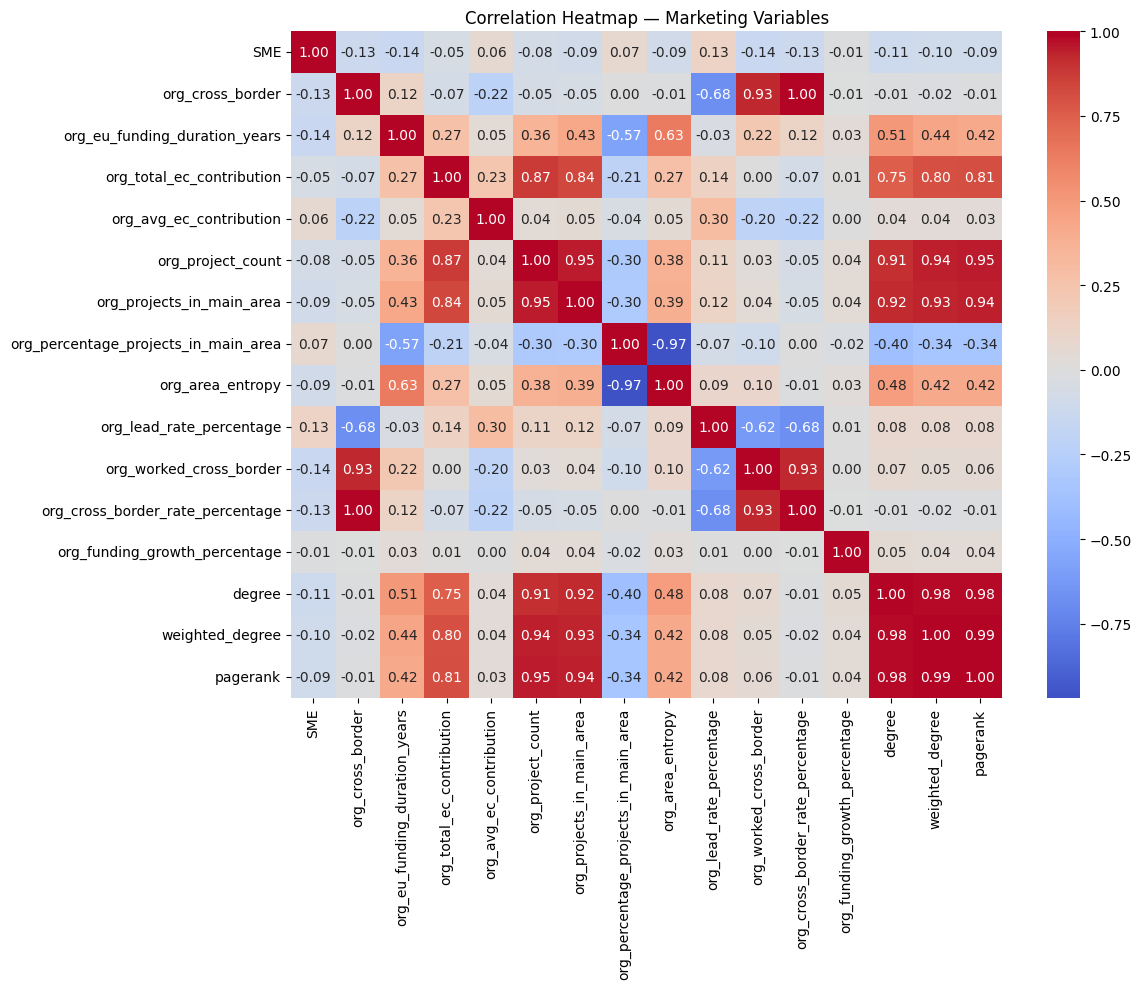

In [12]:
corr_vars = [

"SME",
"org_cross_border",
"org_eu_funding_duration_years",
"org_total_ec_contribution",
"org_avg_ec_contribution",
"org_project_count",
"org_projects_in_main_area",
"org_percentage_projects_in_main_area",
"org_area_entropy",
"org_lead_rate_percentage",
"org_worked_cross_border",
"org_cross_border_rate_percentage",
"org_funding_growth_percentage",
"degree",
"weighted_degree",
"pagerank"

]

# garantir que existem
corr_vars = [c for c in corr_vars if c in df.columns]

# copiar apenas o necessário
df_corr = df[["organisationID"] + corr_vars].copy()

# converter SME para binário
if "SME" in df_corr.columns:
    df_corr["SME"] = (
        df_corr["SME"]
        .astype(str)
        .str.lower()
        .map({"yes":1,"true":1,"1":1,"no":0,"false":0,"0":0})
    )

# converter tudo para numérico
for c in corr_vars:
    df_corr[c] = pd.to_numeric(df_corr[c], errors="coerce")

# preencher missing
df_corr[corr_vars] = df_corr[corr_vars].fillna(0)

# ---------------------------------------------------------
# AGREGAR POR ORGANIZAÇÃO
# ---------------------------------------------------------

df_org_corr = (
    df_corr
    .groupby("organisationID", as_index=False)
    .mean()
)

print("Número de organizações:", len(df_org_corr))

# ---------------------------------------------------------
# MATRIZ DE CORRELAÇÃO
# ---------------------------------------------------------

corr_matrix = df_org_corr[corr_vars].corr()


plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Heatmap — Marketing Variables")

plt.tight_layout()
plt.show()

In [13]:
threshold = 0.8

high_corr_pairs = []

cols = corr_matrix.columns

for i in range(len(cols)):
    for j in range(i+1,len(cols)):

        v1 = cols[i]
        v2 = cols[j]

        corr_val = corr_matrix.loc[v1,v2]

        if abs(corr_val) >= threshold:

            high_corr_pairs.append({
                "var1":v1,
                "var2":v2,
                "correlation":corr_val
            })

high_corr_df = (
    pd.DataFrame(high_corr_pairs)
    .sort_values("correlation",ascending=False)
)

high_corr_df

,var1,var2,correlation
1,org_cross_border,org_cross_border_rate_percentage,1.000000
17,weighted_degree,pagerank,0.994154
15,degree,weighted_degree,0.981257
16,degree,pagerank,0.978995
6,org_project_count,org_projects_in_main_area,0.952525
9,org_project_count,pagerank,0.952160
8,org_project_count,weighted_degree,0.941844
12,org_projects_in_main_area,pagerank,0.941205
11,org_projects_in_main_area,weighted_degree,0.934759
14,org_worked_cross_border,org_cross_border_rate_percentage,0.930362


NaN antes do fill:
org_funding_growth_percentage       22587
SME                                   259
degree                                  0
org_project_count                       0
org_eu_funding_duration_years           0
org_total_ec_contribution               0
org_area_entropy                        0
org_lead_rate_percentage                0
org_cross_border_rate_percentage        0
dtype: int64

Ainda há inf? False
Ainda há NaN? False

Classification report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78      3103
           1       0.79      0.72      0.75      2927

    accuracy                           0.77      6030
   macro avg       0.77      0.77      0.77      6030
weighted avg       0.77      0.77      0.77      6030


Random Forest feature importance:


,feature,importance
3,org_total_ec_contribution,0.405612
2,org_project_count,0.229242
1,org_eu_funding_duration_years,0.146890
4,org_area_entropy,0.105988
7,org_funding_growth_percentage,0.065578
6,org_cross_border_rate_percentage,0.021295
5,org_lead_rate_percentage,0.019616
0,SME,0.005779


Shape X_test: (6030, 8)
Shape shap_plot_values: (6030, 8)


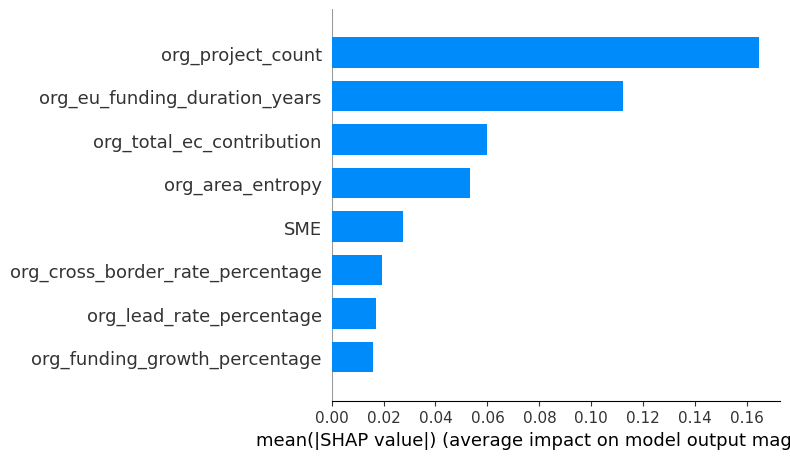

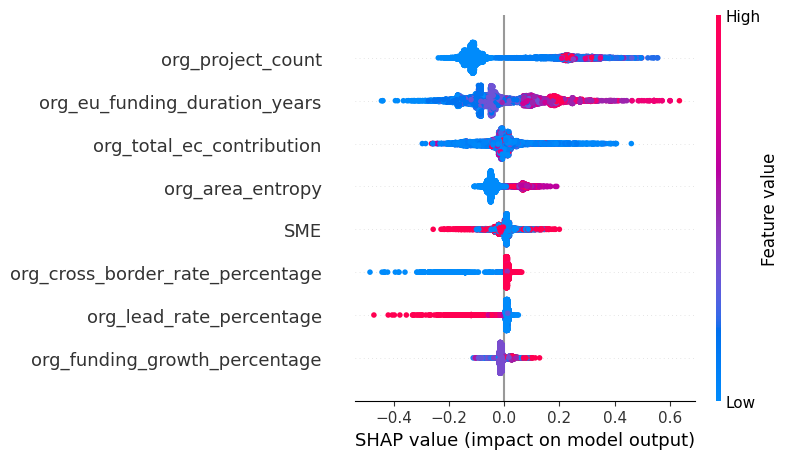

In [14]:
feature_cols = [
    "SME",
    "org_eu_funding_duration_years",
    "org_project_count",
    "org_total_ec_contribution",
    "org_area_entropy",
    "org_lead_rate_percentage",
    "org_cross_border_rate_percentage",
    "org_funding_growth_percentage"
]

# dataframe limpo
keep_cols = ["organisationID", "degree"] + feature_cols
df_shap = df[keep_cols].copy()

# SME True/False -> 1/0
df_shap["SME"] = (
    df_shap["SME"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0
    })
)

# numérico
for c in ["degree"] + feature_cols:
    df_shap[c] = pd.to_numeric(df_shap[c], errors="coerce")

# agregar por organização
df_shap = (
    df_shap
    .groupby("organisationID", as_index=False)
    .mean()
)

# limpar inf
df_shap[["degree"] + feature_cols] = df_shap[["degree"] + feature_cols].replace([np.inf, -np.inf], np.nan)

print("NaN antes do fill:")
print(df_shap[["degree"] + feature_cols].isna().sum().sort_values(ascending=False))

# preencher NaN com mediana
for c in ["degree"] + feature_cols:
    med = df_shap[c].median()
    df_shap[c] = df_shap[c].fillna(med)

# clip outliers
for c in ["degree"] + feature_cols:
    q01 = df_shap[c].quantile(0.01)
    q99 = df_shap[c].quantile(0.99)
    df_shap[c] = df_shap[c].clip(lower=q01, upper=q99)

print("\nAinda há inf?", np.isinf(df_shap[["degree"] + feature_cols].to_numpy()).any())
print("Ainda há NaN?", df_shap[["degree"] + feature_cols].isna().any().any())

# target proxy
X = df_shap[feature_cols].copy()
y = (df_shap["degree"] > df_shap["degree"].median()).astype(int)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# modelo
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# avaliação
y_pred = model.predict(X_test)
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# importance simples
rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nRandom Forest feature importance:")
display(rf_importance)

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# compatibilidade com diferentes versões do shap
if isinstance(shap_values, list):
    shap_plot_values = shap_values[1]
elif len(np.shape(shap_values)) == 3:
    shap_plot_values = shap_values[:, :, 1]
else:
    shap_plot_values = shap_values

print("Shape X_test:", X_test.shape)
print("Shape shap_plot_values:", np.shape(shap_plot_values))

# gráfico barras
shap.summary_plot(shap_plot_values, X_test, plot_type="bar")

# gráfico completo
shap.summary_plot(shap_plot_values, X_test)

# ==========================
# MODEL 1 — BASELINE
# ==========================

In [15]:
def train_test_split_edges(G, test_frac=0.1, seed=42):
    """
    Remove uma fração de arestas para teste, garantindo que o grafo de treino
    mantém os nós originais. Não garante conectividade global perfeita, mas
    funciona bem para avaliação de link recommendation.
    """
    rng = random.Random(seed)

    edges = list(G.edges())
    rng.shuffle(edges)

    n_test = int(len(edges) * test_frac)
    test_edges = []
    G_train = G.copy()

    for u, v in edges:
        if len(test_edges) >= n_test:
            break

        # evitar isolar nós
        if G_train.degree(u) <= 1 or G_train.degree(v) <= 1:
            continue

        G_train.remove_edge(u, v)
        test_edges.append((u, v))

    return G_train, test_edges


def build_test_neighbors(test_edges):
    """
    Constrói dicionário:
    org -> set(parceiros em teste)
    """
    test_nbrs = {}
    for u, v in test_edges:
        test_nbrs.setdefault(u, set()).add(v)
        test_nbrs.setdefault(v, set()).add(u)
    return test_nbrs


# ---------------------------------------------------------
# 2. Recomendador baseline global
# ---------------------------------------------------------
def recommend_partners_baseline(G, org_id, k=10, exclude_existing=False):
    """
    Recomendação baseline usando o grafo raw completo.
    exclude_existing=False:
        permite recomendar parceiros já conhecidos
    exclude_existing=True:
        recomenda apenas parceiros nunca ligados antes
    """
    if org_id not in G:
        return []

    neighbors_u = set(G.neighbors(org_id))
    scores = {}

    # scoring por vizinhos comuns
    for nbr in neighbors_u:
        w_ub = G[org_id][nbr].get("weight", 1)

        for cand in G.neighbors(nbr):
            if cand == org_id:
                continue

            if exclude_existing and cand in neighbors_u:
                continue

            w_bc = G[nbr][cand].get("weight", 1)

            # score simples baseado em força relacional indireta
            scores[cand] = scores.get(cand, 0.0) + (w_ub + w_bc)

    # se queremos incluir conhecidos, reforçar candidatos já ligados
    if not exclude_existing:
        for cand in neighbors_u:
            if cand == org_id:
                continue
            w = G[org_id][cand].get("weight", 1)
            scores[cand] = scores.get(cand, 0.0) + 5.0 * w

    # fallback: se não houver scores suficientes
    if len(scores) < k:
        weighted_degree = dict(G.degree(weight="weight"))
        for cand in G.nodes():
            if cand == org_id:
                continue
            if exclude_existing and cand in neighbors_u:
                continue
            if cand not in scores:
                scores[cand] = 0.01 * weighted_degree.get(cand, 0)

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [cand for cand, _ in ranked[:k]]


# ---------------------------------------------------------
# 3. Avaliação top-k
# ---------------------------------------------------------
def eval_topk_baseline(G_train, test_edges, k=10, exclude_existing=False, node_subset=None):
    """
    Avalia:
    - hit@k
    - precision@k
    - recall@k
    """
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        recs = recommend_partners_baseline(
            G_train,
            org_id,
            k=k,
            exclude_existing=exclude_existing
        )

        recs_set = set(recs)
        intersection = recs_set & true_partners

        hit = 1 if len(intersection) > 0 else 0
        precision = len(intersection) / k
        recall = len(intersection) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 4. Correr Modelo 1 no grafo completo
# ---------------------------------------------------------
# GRAFO COMPLETO
G_model1 = G_no_isolates.copy()

print("Modelo 1 | Nós:", G_model1.number_of_nodes())
print("Modelo 1 | Arestas:", G_model1.number_of_edges())

# split para avaliação
G_train_m1, test_edges_m1 = train_test_split_edges(G_model1, test_frac=0.10, seed=42)

test_nbrs_m1 = build_test_neighbors(test_edges_m1)
eval_nodes_m1 = list(test_nbrs_m1.keys())

random.seed(42)
eval_sample_m1 = random.sample(eval_nodes_m1, k=min(2000, len(eval_nodes_m1)))

# M1a = parceiros já conhecidos
M1a = eval_topk_baseline(
    G_train_m1,
    test_edges_m1,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_m1
)

# M1b = parceiros nunca conhecidos
M1b = eval_topk_baseline(
    G_train_m1,
    test_edges_m1,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_m1
)

print("M1a:", M1a)
print("M1b:", M1b)

Modelo 1 | Nós: 29465
Modelo 1 | Arestas: 864002
M1a: {'n_eval_nodes': 2000, 'hit@10': 0.3575, 'precision@10': 0.0451, 'recall@10': 0.13473117874704138}
M1b: {'n_eval_nodes': 2000, 'hit@10': 0.5555, 'precision@10': 0.11700000000000002, 'recall@10': 0.3024377536608937}


# ==========================
# MODEL 2 — BASELINE (communities aware structure)
# ==========================

In [16]:
# =========================================================
# MODELO 2 — COMMUNITY-AWARE BASELINE
# Recomendação no grafo raw, mas restringida à comunidade
# M2a = parceiros já conhecidos
# M2b = parceiros nunca conhecidos
# =========================================================

# ---------------------------------------------------------
# 1. Deteção de comunidades no grafo completo
# ---------------------------------------------------------
def detect_communities_leiden(G, seed=42):
    """
    Deteta comunidades usando Leiden sobre o grafo completo.
    Devolve:
    - node_to_community
    - community_to_nodes
    """
    nodes = list(G.nodes())
    node_to_idx = {n: i for i, n in enumerate(nodes)}
    idx_to_node = {i: n for n, i in node_to_idx.items()}

    edges = []
    weights = []

    for u, v, data in G.edges(data=True):
        edges.append((node_to_idx[u], node_to_idx[v]))
        weights.append(data.get("weight", 1.0))

    g_ig = ig.Graph(n=len(nodes), edges=edges, directed=False)
    g_ig.es["weight"] = weights

    part = leidenalg.find_partition(
        g_ig,
        leidenalg.RBConfigurationVertexPartition,
        weights="weight",
        seed=seed
    )

    node_to_community = {idx_to_node[i]: cid for i, cid in enumerate(part.membership)}

    community_to_nodes = {}
    for node, cid in node_to_community.items():
        community_to_nodes.setdefault(cid, set()).add(node)

    return node_to_community, community_to_nodes


# ---------------------------------------------------------
# 2. Recomendador community-aware
# ---------------------------------------------------------
def recommend_partners_community(
    G,
    org_id,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False
):
    """
    Recomendação dentro da comunidade da organização.
    
    Score:
    - vizinhos comuns e força relacional
    - fallback para weighted degree dentro da comunidade
    """
    if org_id not in G:
        return []

    if org_id not in node_to_community:
        return []

    comm_id = node_to_community[org_id]
    community_nodes = community_to_nodes.get(comm_id, set())

    if len(community_nodes) == 0:
        return []

    neighbors_u = set(G.neighbors(org_id))
    scores = {}

    # scoring por vizinhos comuns, mas só dentro da comunidade
    for nbr in neighbors_u:
        w_ub = G[org_id][nbr].get("weight", 1)

        for cand in G.neighbors(nbr):
            if cand == org_id:
                continue
            if cand not in community_nodes:
                continue
            if exclude_existing and cand in neighbors_u:
                continue

            w_bc = G[nbr][cand].get("weight", 1)
            scores[cand] = scores.get(cand, 0.0) + (w_ub + w_bc)

    # reforçar parceiros já conhecidos se estamos no cenário M2a
    if not exclude_existing:
        for cand in neighbors_u:
            if cand == org_id:
                continue
            if cand not in community_nodes:
                continue
            w = G[org_id][cand].get("weight", 1)
            scores[cand] = scores.get(cand, 0.0) + 5.0 * w

    # fallback dentro da comunidade
    if len(scores) < k:
        weighted_degree = dict(G.degree(weight="weight"))
        for cand in community_nodes:
            if cand == org_id:
                continue
            if exclude_existing and cand in neighbors_u:
                continue
            if cand not in scores:
                scores[cand] = 0.01 * weighted_degree.get(cand, 0)

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [cand for cand, _ in ranked[:k]]


# ---------------------------------------------------------
# 3. Avaliação community-aware
# ---------------------------------------------------------
def eval_topk_community(
    G_train,
    test_edges,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    """
    Avalia o modelo community-aware.
    """
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        recs = recommend_partners_community(
            G_train,
            org_id,
            node_to_community=node_to_community,
            community_to_nodes=community_to_nodes,
            k=k,
            exclude_existing=exclude_existing
        )

        if len(recs) == 0:
            hits.append(0)
            precisions.append(0.0)
            recalls.append(0.0)
            continue

        recs_set = set(recs)
        intersection = recs_set & true_partners

        hit = 1 if len(intersection) > 0 else 0
        precision = len(intersection) / k
        recall = len(intersection) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 4. Correr Modelo 2 no grafo completo
# ---------------------------------------------------------
G_model2 = G_no_isolates.copy()

print("Modelo 2 | Nós:", G_model2.number_of_nodes())
print("Modelo 2 | Arestas:", G_model2.number_of_edges())

# split para avaliação
G_train_m2, test_edges_m2 = train_test_split_edges(G_model2, test_frac=0.10, seed=42)

test_nbrs_m2 = build_test_neighbors(test_edges_m2)
eval_nodes_m2 = list(test_nbrs_m2.keys())

random.seed(42)
eval_sample_m2 = random.sample(eval_nodes_m2, k=min(2000, len(eval_nodes_m2)))

# comunidades no grafo de treino
node_to_community_m2, community_to_nodes_m2 = detect_communities_leiden(G_train_m2, seed=42)

print("Número de comunidades:", len(community_to_nodes_m2))
print("Maior comunidade:", max(len(v) for v in community_to_nodes_m2.values()))

# M2a = parceiros já conhecidos
M2a = eval_topk_community(
    G_train_m2,
    test_edges_m2,
    node_to_community=node_to_community_m2,
    community_to_nodes=community_to_nodes_m2,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_m2
)

# M2b = parceiros nunca conhecidos
M2b = eval_topk_community(
    G_train_m2,
    test_edges_m2,
    node_to_community=node_to_community_m2,
    community_to_nodes=community_to_nodes_m2,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_m2
)

print("M2a:", M2a)
print("M2b:", M2b)

Modelo 2 | Nós: 29465
Modelo 2 | Arestas: 864002
Número de comunidades: 56
Maior comunidade: 5064
M2a: {'n_eval_nodes': 2000, 'hit@10': 0.407, 'precision@10': 0.05260000000000001, 'recall@10': 0.1643845506900983}
M2b: {'n_eval_nodes': 2000, 'hit@10': 0.655, 'precision@10': 0.151, 'recall@10': 0.3669394828372748}


# ==========================
# MODEL 3 — BASELINE (area aware structure)
# ==========================

In [17]:
# =========================================================
# MODELO 3 — AREA-AWARE BASELINE
# Recomendação baseada nas áreas de trabalho das organizações
# M3a = parceiros já conhecidos
# M3b = parceiros nunca conhecidos
# =========================================================

# ---------------------------------------------------------
# 1. Construir top áreas por organização
# ---------------------------------------------------------
def build_org_area_profiles(df):
    """
    Constrói:
    - org_to_top_areas: dict org -> lista das top 3 áreas
    - org_focus_map: dict org -> percentagem na main area (0-1)
    - org_main_area_map: dict org -> área principal
    - area_to_nodes: dict area -> set de organizações
    """

    # contar nº projetos únicos por organização e área
    org_area_counts = (
        df.groupby(["organisationID", "area"])["projectID"]
          .nunique()
          .reset_index(name="n_projects")
    )

    # total por organização
    org_tot = (
        org_area_counts.groupby("organisationID")["n_projects"]
        .sum()
        .reset_index(name="tot_projects")
    )

    org_area_counts = org_area_counts.merge(org_tot, on="organisationID", how="left")
    org_area_counts["share"] = org_area_counts["n_projects"] / org_area_counts["tot_projects"]

    # top 3 áreas por organização
    org_top_areas = (
        org_area_counts.sort_values(["organisationID", "share"], ascending=[True, False])
                       .groupby("organisationID")
                       .head(3)
    )

    org_to_top_areas = (
        org_top_areas.groupby("organisationID")["area"]
        .apply(list)
        .to_dict()
    )

    # área principal
    org_main_area_map = (
        df.drop_duplicates("organisationID")
          .set_index("organisationID")["org_main_area"]
          .to_dict()
    )

    # percentagem na área principal
    org_focus_map = (
        df.drop_duplicates("organisationID")
          .set_index("organisationID")["org_percentage_projects_in_main_area"]
          .apply(lambda x: x/100 if pd.notna(x) else None)
          .to_dict()
    )

    # map area -> organizações
    area_to_nodes = (
        df.groupby("area")["organisationID"]
          .apply(lambda s: set(s.dropna().unique()))
          .to_dict()
    )

    return org_to_top_areas, org_focus_map, org_main_area_map, area_to_nodes


# ---------------------------------------------------------
# 2. Obter áreas relevantes da organização
# ---------------------------------------------------------
def get_org_area_weights(org_id, org_to_top_areas, org_focus_map, org_main_area_map):
    """
    Regras:
    - se focus > 50% -> só main area com peso 1.0
    - se focus <= 50% -> usar top 3 áreas com pesos 1.0, 0.7, 0.5
    """
    focus = org_focus_map.get(org_id, None)
    main_area = org_main_area_map.get(org_id, None)
    top_areas = org_to_top_areas.get(org_id, [])

    if focus is None:
        if main_area is not None:
            return [(main_area, 1.0)]
        return []

    if focus > 0.5:
        if main_area is not None:
            return [(main_area, 1.0)]
        elif len(top_areas) > 0:
            return [(top_areas[0], 1.0)]
        else:
            return []

    # foco <= 50% → usar top 3
    weights = [1.0, 0.7, 0.5]
    area_weights = []

    for i, area in enumerate(top_areas[:3]):
        area_weights.append((area, weights[i]))

    return area_weights


# ---------------------------------------------------------
# 3. Recomendador area-aware
# ---------------------------------------------------------
def recommend_partners_area(
    G,
    org_id,
    org_to_top_areas,
    org_focus_map,
    org_main_area_map,
    area_to_nodes,
    k=10,
    exclude_existing=False
):
    """
    Recomendação baseada nas áreas da organização.
    Usa:
    - candidatos dentro das áreas relevantes
    - score relacional + peso da área
    """
    if org_id not in G:
        return []

    neighbors_u = set(G.neighbors(org_id))
    scores = {}

    area_weights = get_org_area_weights(
        org_id,
        org_to_top_areas=org_to_top_areas,
        org_focus_map=org_focus_map,
        org_main_area_map=org_main_area_map
    )

    if len(area_weights) == 0:
        return []

    # candidatos possíveis = união das áreas relevantes
    candidate_pool = set()
    for area, w_area in area_weights:
        candidate_pool |= area_to_nodes.get(area, set())

    candidate_pool.discard(org_id)

    if exclude_existing:
        candidate_pool -= neighbors_u

    # scoring por vizinhos comuns + peso da área
    for area, w_area in area_weights:
        area_nodes = area_to_nodes.get(area, set())

        for nbr in neighbors_u:
            w_ub = G[org_id][nbr].get("weight", 1)

            for cand in G.neighbors(nbr):
                if cand == org_id:
                    continue
                if cand not in candidate_pool:
                    continue
                if cand not in area_nodes:
                    continue
                if exclude_existing and cand in neighbors_u:
                    continue

                w_bc = G[nbr][cand].get("weight", 1)
                scores[cand] = scores.get(cand, 0.0) + w_area * (w_ub + w_bc)

    # reforçar parceiros já conhecidos no cenário M3a
    if not exclude_existing:
        for area, w_area in area_weights:
            area_nodes = area_to_nodes.get(area, set())

            for cand in neighbors_u:
                if cand == org_id:
                    continue
                if cand not in area_nodes:
                    continue

                w = G[org_id][cand].get("weight", 1)
                scores[cand] = scores.get(cand, 0.0) + w_area * 5.0 * w

    # fallback com weighted degree dentro candidate pool
    if len(scores) < k:
        weighted_degree = dict(G.degree(weight="weight"))

        # score extra por sobreposição de áreas
        for cand in candidate_pool:
            if cand not in scores:
                cand_score = 0.0
                for area, w_area in area_weights:
                    if cand in area_to_nodes.get(area, set()):
                        cand_score += w_area
                scores[cand] = cand_score + 0.01 * weighted_degree.get(cand, 0)

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [cand for cand, _ in ranked[:k]]


# ---------------------------------------------------------
# 4. Avaliação do modelo 3
# ---------------------------------------------------------
def eval_topk_area(
    G_train,
    test_edges,
    org_to_top_areas,
    org_focus_map,
    org_main_area_map,
    area_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        recs = recommend_partners_area(
            G_train,
            org_id,
            org_to_top_areas=org_to_top_areas,
            org_focus_map=org_focus_map,
            org_main_area_map=org_main_area_map,
            area_to_nodes=area_to_nodes,
            k=k,
            exclude_existing=exclude_existing
        )

        if len(recs) == 0:
            hits.append(0)
            precisions.append(0.0)
            recalls.append(0.0)
            continue

        recs_set = set(recs)
        intersection = recs_set & true_partners

        hit = 1 if len(intersection) > 0 else 0
        precision = len(intersection) / k
        recall = len(intersection) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 5. Correr Modelo 3 no grafo completo
# ---------------------------------------------------------
G_model3 = G_no_isolates.copy()

print("Modelo 3 | Nós:", G_model3.number_of_nodes())
print("Modelo 3 | Arestas:", G_model3.number_of_edges())

# perfis de área
org_to_top_areas_m3, org_focus_map_m3, org_main_area_map_m3, area_to_nodes_m3 = build_org_area_profiles(df)

# split para avaliação
G_train_m3, test_edges_m3 = train_test_split_edges(G_model3, test_frac=0.10, seed=42)

test_nbrs_m3 = build_test_neighbors(test_edges_m3)
eval_nodes_m3 = list(test_nbrs_m3.keys())

random.seed(42)
eval_sample_m3 = random.sample(eval_nodes_m3, k=min(2000, len(eval_nodes_m3)))

# M3a = parceiros já conhecidos
M3a = eval_topk_area(
    G_train_m3,
    test_edges_m3,
    org_to_top_areas=org_to_top_areas_m3,
    org_focus_map=org_focus_map_m3,
    org_main_area_map=org_main_area_map_m3,
    area_to_nodes=area_to_nodes_m3,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_m3
)

# M3b = parceiros nunca conhecidos
M3b = eval_topk_area(
    G_train_m3,
    test_edges_m3,
    org_to_top_areas=org_to_top_areas_m3,
    org_focus_map=org_focus_map_m3,
    org_main_area_map=org_main_area_map_m3,
    area_to_nodes=area_to_nodes_m3,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_m3
)

print("M3a:", M3a)
print("M3b:", M3b)

Modelo 3 | Nós: 29465
Modelo 3 | Arestas: 864002
M3a: {'n_eval_nodes': 2000, 'hit@10': 0.3595, 'precision@10': 0.045450000000000004, 'recall@10': 0.13552941107027375}
M3b: {'n_eval_nodes': 2000, 'hit@10': 0.5525, 'precision@10': 0.1162, 'recall@10': 0.30120627761777974}


# ==========================
# MODEL 4 — BASELINE (hypergraph structure)
# ==========================

In [18]:
# =========================================================
# MODELO 4 — HYPERGRAPH BASELINE
# Cada projeto funciona como uma hiperaresta entre organizações
# M4a = parceiros já conhecidos
# M4b = parceiros nunca conhecidos
# =========================================================



# ---------------------------------------------------------
# 1. Split por projetos
# ---------------------------------------------------------
def split_projects(df, test_frac=0.1, seed=42):
    """
    Faz split por projetos, não por linhas.
    Mantém projetos completos em train/test.
    """
    rng = random.Random(seed)

    projects = df["projectID"].dropna().unique().tolist()
    rng.shuffle(projects)

    n_test = int(len(projects) * test_frac)
    test_projects = set(projects[:n_test])
    train_projects = set(projects[n_test:])

    train_df = df[df["projectID"].isin(train_projects)].copy()
    test_df = df[df["projectID"].isin(test_projects)].copy()

    return train_df, test_df


# ---------------------------------------------------------
# 2. Construir mapas do hypergraph
# ---------------------------------------------------------
def build_hypergraph_maps(df_projects):
    """
    Devolve:
    - org_to_projects: org -> set(projects)
    - project_to_orgs: project -> set(orgs)
    """
    project_to_orgs = (
        df_projects.groupby("projectID")["organisationID"]
        .apply(lambda s: set(s.dropna().unique()))
        .to_dict()
    )

    org_to_projects = (
        df_projects.groupby("organisationID")["projectID"]
        .apply(lambda s: set(s.dropna().unique()))
        .to_dict()
    )

    return org_to_projects, project_to_orgs


# ---------------------------------------------------------
# 3. Parceiros já conhecidos em train
# ---------------------------------------------------------
def build_train_org_partners_from_projects(project_to_orgs):
    """
    Constrói:
    org -> set(parceiros com quem já participou em train)
    """
    partners = {}

    for project_id, orgs in project_to_orgs.items():
        orgs = list(orgs)
        for u in orgs:
            partners.setdefault(u, set())
            for v in orgs:
                if u != v:
                    partners[u].add(v)

    return partners


# ---------------------------------------------------------
# 4. Novas ligações de teste
# ---------------------------------------------------------
def build_new_link_test_edges(test_df, train_project_to_orgs):
    """
    Para cada projeto de teste, identifica pares de organizações que:
    - aparecem juntos em test
    - não eram já parceiros em train

    Devolve:
    - test_edges_new: lista de pares novos
    - test_nbrs_new: dict org -> novos parceiros em test
    - test_project_to_orgs: mapa projeto -> orgs do test
    """
    test_project_to_orgs = (
        test_df.groupby("projectID")["organisationID"]
        .apply(lambda s: set(s.dropna().unique()))
        .to_dict()
    )

    # parceiros já conhecidos em train
    partners_train = build_train_org_partners_from_projects(train_project_to_orgs)

    test_edges_new = []
    test_nbrs_new = {}

    for project_id, orgs in test_project_to_orgs.items():
        orgs = list(orgs)
        for i in range(len(orgs)):
            for j in range(i + 1, len(orgs)):
                u, v = orgs[i], orgs[j]

                already_known = (
                    v in partners_train.get(u, set()) or
                    u in partners_train.get(v, set())
                )

                if not already_known:
                    test_edges_new.append((u, v))
                    test_nbrs_new.setdefault(u, set()).add(v)
                    test_nbrs_new.setdefault(v, set()).add(u)

    return test_edges_new, test_nbrs_new, test_project_to_orgs


# ---------------------------------------------------------
# 5. Recomendador hypergraph
# ---------------------------------------------------------
def recommend_partners_hypergraph(
    org_id,
    org_to_projects,
    project_to_orgs,
    partners_train,
    k=10,
    exclude_existing=False
):
    """
    Recomendação baseada no hypergraph:
    - percorre projetos da organização
    - vai aos outros parceiros desses projetos
    - propaga por projetos desses parceiros
    - score por frequência e tamanho dos projetos
    """
    if org_id not in org_to_projects:
        return []

    org_projects = org_to_projects.get(org_id, set())
    known_partners = partners_train.get(org_id, set())

    scores = {}

    for p in org_projects:
        orgs_in_p = project_to_orgs.get(p, set())
        size_p = max(len(orgs_in_p), 1)

        # parceiros diretos do mesmo projeto
        for mid in orgs_in_p:
            if mid == org_id:
                continue

            # reforço direto
            if not exclude_existing and mid in known_partners:
                scores[mid] = scores.get(mid, 0.0) + 3.0 / size_p

            # expansão para projetos do parceiro intermédio
            mid_projects = org_to_projects.get(mid, set())
            for p2 in mid_projects:
                orgs_in_p2 = project_to_orgs.get(p2, set())
                size_p2 = max(len(orgs_in_p2), 1)

                for cand in orgs_in_p2:
                    if cand == org_id:
                        continue
                    if exclude_existing and cand in known_partners:
                        continue

                    # score hipergráfico: proximidade via projetos partilhados
                    score_add = (1.0 / size_p) + (1.0 / size_p2)
                    scores[cand] = scores.get(cand, 0.0) + score_add

    # fallback se necessário
    if len(scores) < k:
        candidate_counts = {}
        for project_id, orgs in project_to_orgs.items():
            size_p = max(len(orgs), 1)
            for cand in orgs:
                if cand == org_id:
                    continue
                if exclude_existing and cand in known_partners:
                    continue
                candidate_counts[cand] = candidate_counts.get(cand, 0.0) + 1.0 / size_p

        for cand, val in candidate_counts.items():
            if cand not in scores:
                scores[cand] = val

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [cand for cand, _ in ranked[:k]]


# ---------------------------------------------------------
# 6. Avaliação hypergraph
# ---------------------------------------------------------
def eval_hypergraph(
    test_nbrs,
    recommender_fn,
    k=10,
    node_subset=None
):
    """
    Avalia:
    - hit@k
    - precision@k
    - recall@k
    """
    nodes_eval = list(test_nbrs.keys())

    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        recs = recommender_fn(org_id, k=k)
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 7. Correr Modelo 4
# ---------------------------------------------------------
train_df_m4, test_df_m4 = split_projects(df, test_frac=0.10, seed=42)

# mapas do hypergraph em train
org_to_projects_m4, project_to_orgs_m4 = build_hypergraph_maps(train_df_m4)

# parceiros já conhecidos em train
partners_train_m4 = build_train_org_partners_from_projects(project_to_orgs_m4)

# construir targets de avaliação:
# - test_nbrs_all = todos os pares em test
# - test_nbrs_new = apenas novos pares em test
test_project_to_orgs_m4 = (
    test_df_m4.groupby("projectID")["organisationID"]
    .apply(lambda s: set(s.dropna().unique()))
    .to_dict()
)

test_nbrs_all_m4 = {}
for project_id, orgs in test_project_to_orgs_m4.items():
    orgs = list(orgs)
    for i in range(len(orgs)):
        for j in range(i + 1, len(orgs)):
            u, v = orgs[i], orgs[j]
            test_nbrs_all_m4.setdefault(u, set()).add(v)
            test_nbrs_all_m4.setdefault(v, set()).add(u)

test_edges_new_m4, test_nbrs_new_m4, _ = build_new_link_test_edges(
    test_df_m4,
    project_to_orgs_m4
)

# sample de avaliação
eval_nodes_m4 = list(test_nbrs_all_m4.keys())
random.seed(42)
eval_sample_m4 = random.sample(eval_nodes_m4, k=min(2000, len(eval_nodes_m4)))

print("Modelo 4 | Train projects:", train_df_m4['projectID'].nunique())
print("Modelo 4 | Test projects:", test_df_m4['projectID'].nunique())
print("Modelo 4 | Organizações train:", len(org_to_projects_m4))
print("Modelo 4 | Novos pares em test:", len(test_edges_new_m4))

# M4a = parceiros já conhecidos / pode recomendar conhecidos
M4a = eval_hypergraph(
    test_nbrs_all_m4,
    lambda org_id, k=10: recommend_partners_hypergraph(
        org_id,
        org_to_projects=org_to_projects_m4,
        project_to_orgs=project_to_orgs_m4,
        partners_train=partners_train_m4,
        k=k,
        exclude_existing=False
    ),
    k=10,
    node_subset=eval_sample_m4
)

# M4b = parceiros nunca conhecidos
M4b = eval_hypergraph(
    test_nbrs_new_m4,
    lambda org_id, k=10: recommend_partners_hypergraph(
        org_id,
        org_to_projects=org_to_projects_m4,
        project_to_orgs=project_to_orgs_m4,
        partners_train=partners_train_m4,
        k=k,
        exclude_existing=True
    ),
    k=10,
    node_subset=eval_sample_m4
)

print("M4a:", M4a)
print("M4b:", M4b)

Modelo 4 | Train projects: 16632
Modelo 4 | Test projects: 1848
Modelo 4 | Organizações train: 28136
Modelo 4 | Novos pares em test: 74555
M4a: {'n_eval_nodes': 2000, 'hit@10': 0.454, 'precision@10': 0.11230000000000001, 'recall@10': 0.04241329205459097}
M4b: {'n_eval_nodes': 1988, 'hit@10': 0.30432595573440646, 'precision@10': 0.04683098591549296, 'recall@10': 0.02341467651613709}


# ==========================
# MODEL 1 — baseline light GCN 
# ==========================

In [19]:
# =========================================================
# MODELO RAW LIGHTGCN (SEEDED, DOT + COSINE)
# M1a_light = parceiros já conhecidos
# M1b_light = parceiros nunca conhecidos
# =========================================================

# ---------------------------------------------------------
# 0. Seed global para reprodutibilidade
# ---------------------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # maior determinismo possível
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)


# ---------------------------------------------------------
# 1. Normalized adjacency matrix para LightGCN
# ---------------------------------------------------------
def build_lightgcn_norm_adj(G, node_to_idx):
    """
    Constrói adjacency normalizada:
    A_hat = D^{-1/2} A D^{-1/2}
    """
    rows, cols, vals = [], [], []

    for u, v, data in G.edges(data=True):
        i = node_to_idx[u]
        j = node_to_idx[v]
        w = data.get("weight", 1.0)

        rows.extend([i, j])
        cols.extend([j, i])
        vals.extend([w, w])

    n = len(node_to_idx)
    A = sp.coo_matrix((vals, (rows, cols)), shape=(n, n), dtype=np.float32)

    deg = np.array(A.sum(axis=1)).flatten()
    deg_inv_sqrt = np.power(deg, -0.5, where=deg > 0)
    deg_inv_sqrt[deg == 0] = 0.0

    D_inv_sqrt = sp.diags(deg_inv_sqrt)
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    A_norm = A_norm.tocoo()

    indices = torch.tensor(np.vstack((A_norm.row, A_norm.col)), dtype=torch.long)
    values = torch.tensor(A_norm.data, dtype=torch.float32)
    shape = torch.Size(A_norm.shape)

    return torch.sparse_coo_tensor(indices, values, shape).coalesce()


# ---------------------------------------------------------
# 2. LightGCN model
# ---------------------------------------------------------
class LightGCN(nn.Module):
    def __init__(self, num_nodes, emb_dim=64, n_layers=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.emb_dim = emb_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(num_nodes, emb_dim)
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, A_norm):
        x0 = self.embedding.weight
        xs = [x0]

        x = x0
        for _ in range(self.n_layers):
            x = torch.sparse.mm(A_norm, x)
            xs.append(x)

        out = torch.stack(xs, dim=0).mean(dim=0)
        return out


# ---------------------------------------------------------
# 3. Treino BPR
# ---------------------------------------------------------
def train_lightgcn_bpr(
    G_train,
    emb_dim=64,
    n_layers=2,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    seed=42,
    device=None
):
    set_seed(seed)
    rng = random.Random(seed)

    # ordenar nós para garantir consistência entre execuções
    nodes = sorted(G_train.nodes())
    node_to_idx = {n: i for i, n in enumerate(nodes)}
    idx_to_node = {i: n for n, i in node_to_idx.items()}

    train_nbrs = {u: set(G_train.neighbors(u)) for u in nodes}
    train_edges = list(G_train.edges())

    A_norm = build_lightgcn_norm_adj(G_train, node_to_idx)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    A_norm = A_norm.to(device)
    model = LightGCN(num_nodes=len(nodes), emb_dim=emb_dim, n_layers=n_layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    def bpr_loss(u_emb, pos_emb, neg_emb, reg_lambda=1e-4):
        pos_scores = (u_emb * pos_emb).sum(dim=1)
        neg_scores = (u_emb * neg_emb).sum(dim=1)

        loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
        reg = reg_lambda * (
            u_emb.norm(2).pow(2) +
            pos_emb.norm(2).pow(2) +
            neg_emb.norm(2).pow(2)
        ) / u_emb.shape[0]

        return loss + reg

    model.train()

    for ep in range(1, epochs + 1):
        rng.shuffle(train_edges)
        total_loss = 0.0
        steps = 0

        for start in range(0, len(train_edges), batch_size):
            batch = train_edges[start:start + batch_size]
            if not batch:
                continue

            us, pos_vs, neg_vs = [], [], []

            for u, v in batch:
                # randomizar direção
                if rng.random() < 0.5:
                    u, v = v, u

                # negative sampling
                while True:
                    neg = rng.choice(nodes)
                    if neg != u and neg not in train_nbrs[u]:
                        break

                us.append(node_to_idx[u])
                pos_vs.append(node_to_idx[v])
                neg_vs.append(node_to_idx[neg])

            us = torch.tensor(us, dtype=torch.long, device=device)
            pos_vs = torch.tensor(pos_vs, dtype=torch.long, device=device)
            neg_vs = torch.tensor(neg_vs, dtype=torch.long, device=device)

            emb = model(A_norm)

            u_emb = emb[us]
            pos_emb = emb[pos_vs]
            neg_emb = emb[neg_vs]

            loss = bpr_loss(u_emb, pos_emb, neg_emb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()
            steps += 1

        if ep == 1 or ep % 2 == 0:
            print(f"Epoch {ep}/{epochs} | loss={total_loss / max(steps,1):.4f}")

    return model, A_norm, node_to_idx, idx_to_node, train_nbrs


# ---------------------------------------------------------
# 4. Avaliação top-k para LightGCN raw (DOT)
# ---------------------------------------------------------
@torch.no_grad()
def eval_lightgcn_topk_dot(
    model,
    A_norm,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)
    nodes_eval = list(test_nbrs.keys())

    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    model.eval()
    emb = model(A_norm)

    hits, precisions, recalls = [], [], []

    all_nodes = sorted(node_to_idx.keys())

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue
        if org_id not in node_to_idx:
            continue

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in all_nodes if v not in forbidden]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates],
            dtype=torch.long,
            device=emb.device
        )

        u_emb = emb[u_idx]
        scores = (emb[cand_idx] * u_emb).sum(dim=1)

        topk = min(k, len(candidates))
        _, inds = torch.topk(scores, k=topk)

        recs = [candidates[i] for i in inds.cpu().numpy().tolist()]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if precisions else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 5. Avaliação top-k para LightGCN raw (COSINE)
# ---------------------------------------------------------
@torch.no_grad()
def eval_lightgcn_topk_cosine(
    model,
    A_norm,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    k=10,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)
    nodes_eval = list(test_nbrs.keys())

    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    model.eval()
    emb = model(A_norm)

    hits, precisions, recalls = [], [], []

    all_nodes = sorted(node_to_idx.keys())

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue
        if org_id not in node_to_idx:
            continue

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in all_nodes if v not in forbidden]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates],
            dtype=torch.long,
            device=emb.device
        )

        u_emb = emb[u_idx]
        cand_emb = emb[cand_idx]

        u_norm = u_emb.norm() + eps
        cand_norms = cand_emb.norm(dim=1) + eps
        scores = (cand_emb * u_emb).sum(dim=1) / (cand_norms * u_norm)

        topk = min(k, len(candidates))
        _, inds = torch.topk(scores, k=topk)

        recs = [candidates[i] for i in inds.cpu().numpy().tolist()]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if precisions else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 6. Correr Raw LightGCN
# ---------------------------------------------------------
set_seed(SEED)

G_light = G_no_isolates.copy()

print("Raw LightGCN | Nós:", G_light.number_of_nodes())
print("Raw LightGCN | Arestas:", G_light.number_of_edges())

# split igual ao baseline raw
G_train_light, test_edges_light = train_test_split_edges(G_light, test_frac=0.10, seed=SEED)

test_nbrs_light = build_test_neighbors(test_edges_light)
eval_nodes_light = list(test_nbrs_light.keys())

random.seed(SEED)
eval_sample_light = random.sample(eval_nodes_light, k=min(2000, len(eval_nodes_light)))

model_light, A_norm_light, node_to_idx_light, idx_to_node_light, train_nbrs_light = train_lightgcn_bpr(
    G_train_light,
    emb_dim=64,
    n_layers=2,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    seed=SEED
)

# M1a_light_dot = pode recomendar parceiros já conhecidos
M1a_light_dot = eval_lightgcn_topk_dot(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light
)

# M1b_light_dot = só parceiros nunca conhecidos
M1b_light_dot = eval_lightgcn_topk_dot(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light
)

# M1a_light_cosine = pode recomendar parceiros já conhecidos
M1a_light_cosine = eval_lightgcn_topk_cosine(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light
)

# M1b_light_cosine = só parceiros nunca conhecidos
M1b_light_cosine = eval_lightgcn_topk_cosine(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light
)

print("\n--- DOT PRODUCT ---")
print("M1a_light_dot:", M1a_light_dot)
print("M1b_light_dot:", M1b_light_dot)

print("\n--- COSINE SIMILARITY ---")
print("M1a_light_cosine:", M1a_light_cosine)
print("M1b_light_cosine:", M1b_light_cosine)

Raw LightGCN | Nós: 29465
Raw LightGCN | Arestas: 864002
Epoch 1/20 | loss=0.5569
Epoch 2/20 | loss=0.4114
Epoch 4/20 | loss=0.3694
Epoch 6/20 | loss=0.3201
Epoch 8/20 | loss=0.2773
Epoch 10/20 | loss=0.2464
Epoch 12/20 | loss=0.2221
Epoch 14/20 | loss=0.2005
Epoch 16/20 | loss=0.1817
Epoch 18/20 | loss=0.1654
Epoch 20/20 | loss=0.1512

--- DOT PRODUCT ---
M1a_light_dot: {'n_eval_nodes': 2000, 'hit@10': 0.239, 'precision@10': 0.029, 'recall@10': 0.065}
M1b_light_dot: {'n_eval_nodes': 2000, 'hit@10': 0.318, 'precision@10': 0.061, 'recall@10': 0.106}

--- COSINE SIMILARITY ---
M1a_light_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.44, 'precision@10': 0.059, 'recall@10': 0.208}
M1b_light_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.556, 'precision@10': 0.104, 'recall@10': 0.296}


# ==========================
# MODEL 2 — light GCN Comunity Aware Structure
# ==========================

In [20]:
# =========================================================
# MODELO 2 LIGHTGCN — COMMUNITY-AWARE (DOT + COSINE)
# M2a_light = parceiros já conhecidos
# M2b_light = parceiros nunca conhecidos
# =========================================================

# ---------------------------------------------------------
# 1. Avaliação community-aware (DOT)
# ---------------------------------------------------------
@torch.no_grad()
def eval_lightgcn_community_dot(
    model,
    A_norm,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    model.eval()
    emb = model(A_norm)

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in node_to_idx:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden and v in node_to_idx]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]

        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates],
            dtype=torch.long,
            device=emb.device
        )

        u_emb = emb[u_idx]
        scores = (emb[cand_idx] * u_emb).sum(dim=1)

        topk = min(k, len(candidates))
        _, inds = torch.topk(scores, k=topk)

        recs = [candidates[i] for i in inds.cpu().numpy().tolist()]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if precisions else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 2. Avaliação community-aware (COSINE)
# ---------------------------------------------------------
@torch.no_grad()
def eval_lightgcn_community_cosine(
    model,
    A_norm,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    model.eval()
    emb = model(A_norm)

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in node_to_idx:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden and v in node_to_idx]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]

        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates],
            dtype=torch.long,
            device=emb.device
        )

        u_emb = emb[u_idx]
        cand_emb = emb[cand_idx]

        u_norm = u_emb.norm() + eps
        cand_norms = cand_emb.norm(dim=1) + eps
        scores = (cand_emb * u_emb).sum(dim=1) / (cand_norms * u_norm)

        topk = min(k, len(candidates))
        _, inds = torch.topk(scores, k=topk)

        recs = [candidates[i] for i in inds.cpu().numpy().tolist()]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if precisions else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 3. Correr Community LightGCN
# ---------------------------------------------------------
node_to_community_light, community_to_nodes_light = detect_communities_leiden(
    G_train_light,
    seed=42
)

print("Número de comunidades:", len(community_to_nodes_light))

# DOT
M2a_light_dot = eval_lightgcn_community_dot(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    node_to_community_light,
    community_to_nodes_light,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light
)

M2b_light_dot = eval_lightgcn_community_dot(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    node_to_community_light,
    community_to_nodes_light,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light
)

# COSINE
M2a_light_cosine = eval_lightgcn_community_cosine(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    node_to_community_light,
    community_to_nodes_light,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light
)

M2b_light_cosine = eval_lightgcn_community_cosine(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    node_to_community_light,
    community_to_nodes_light,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light
)

print("\n--- DOT PRODUCT ---")
print("M2a_light_dot:", M2a_light_dot)
print("M2b_light_dot:", M2b_light_dot)

print("\n--- COSINE SIMILARITY ---")
print("M2a_light_cosine:", M2a_light_cosine)
print("M2b_light_cosine:", M2b_light_cosine)

Número de comunidades: 56

--- DOT PRODUCT ---
M2a_light_dot: {'n_eval_nodes': 2000, 'hit@10': 0.256, 'precision@10': 0.031, 'recall@10': 0.078}
M2b_light_dot: {'n_eval_nodes': 1998, 'hit@10': 0.345, 'precision@10': 0.066, 'recall@10': 0.127}

--- COSINE SIMILARITY ---
M2a_light_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.435, 'precision@10': 0.059, 'recall@10': 0.205}
M2b_light_cosine: {'n_eval_nodes': 1998, 'hit@10': 0.547, 'precision@10': 0.103, 'recall@10': 0.285}


# ==========================
# MODEL 3 — light GCN Area Aware Structure
# ==========================

In [21]:
# =========================================================
# MODELO 3 LIGHTGCN — AREA-AWARE
# M3a_light = parceiros já conhecidos
# M3b_light = parceiros nunca conhecidos
# =========================================================

@torch.no_grad()
def eval_lightgcn_area(
    model,
    A_norm,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    org_to_top_areas,
    org_focus_map,
    org_main_area_map,
    area_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    emb = model(A_norm)

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue
        if org_id not in node_to_idx:
            continue

        area_weights = get_org_area_weights(
            org_id,
            org_to_top_areas=org_to_top_areas,
            org_focus_map=org_focus_map,
            org_main_area_map=org_main_area_map
        )
        if len(area_weights) == 0:
            continue

        neighbors_u = train_nbrs.get(org_id, set())

        # candidate pool = união das áreas relevantes
        candidate_pool = set()
        for area, _w in area_weights:
            candidate_pool |= area_to_nodes.get(area, set())

        candidate_pool.discard(org_id)
        if exclude_existing:
            candidate_pool -= neighbors_u

        candidates = [v for v in candidate_pool if v in node_to_idx]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        u_emb = emb[u_idx]

        # score base por embedding similarity
        cand_idx = torch.tensor([node_to_idx[v] for v in candidates], dtype=torch.long, device=emb.device)
        sim_scores = (emb[cand_idx] * u_emb).sum(dim=1).cpu().numpy()

        # boost por área
        candidate_scores = {}
        for cand, sim in zip(candidates, sim_scores):
            score = float(sim)

            # soma ponderada das áreas partilhadas
            for area, w_area in area_weights:
                if cand in area_to_nodes.get(area, set()):
                    score += w_area

            # pequeno reforço se já for parceiro conhecido no cenário M3a_light
            if (not exclude_existing) and (cand in neighbors_u):
                score += 1.0

            candidate_scores[cand] = score

        ranked = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
        recs = [cand for cand, _ in ranked[:k]]

        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# Perfis de área para o modelo 3 light
# ---------------------------------------------------------
org_to_top_areas_light, org_focus_map_light, org_main_area_map_light, area_to_nodes_light = build_org_area_profiles(df)

# M3a_light
M3a_light = eval_lightgcn_area(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    org_to_top_areas=org_to_top_areas_light,
    org_focus_map=org_focus_map_light,
    org_main_area_map=org_main_area_map_light,
    area_to_nodes=area_to_nodes_light,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light
)

# M3b_light
M3b_light = eval_lightgcn_area(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    org_to_top_areas=org_to_top_areas_light,
    org_focus_map=org_focus_map_light,
    org_main_area_map=org_main_area_map_light,
    area_to_nodes=area_to_nodes_light,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light
)

print("M3a_light:", M3a_light)
print("M3b_light:", M3b_light)

M3a_light: {'n_eval_nodes': 2000, 'hit@10': 0.1825, 'precision@10': 0.020550000000000006, 'recall@10': 0.046780067235906365}
M3b_light: {'n_eval_nodes': 2000, 'hit@10': 0.32, 'precision@10': 0.06125000000000001, 'recall@10': 0.10848166661933632}


In [22]:
# =========================================================
# MODELO 3 LIGHTGCN — AREA-AWARE (DOT + COSINE)
# M3a_light = parceiros já conhecidos
# M3b_light = parceiros nunca conhecidos
# =========================================================

# ---------------------------------------------------------
# 1. Avaliação area-aware (DOT)
# ---------------------------------------------------------
@torch.no_grad()
def eval_lightgcn_area_dot(
    model,
    A_norm,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    org_to_top_areas,
    org_focus_map,
    org_main_area_map,
    area_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    model.eval()
    emb = model(A_norm)

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue
        if org_id not in node_to_idx:
            continue

        area_weights = get_org_area_weights(
            org_id,
            org_to_top_areas=org_to_top_areas,
            org_focus_map=org_focus_map,
            org_main_area_map=org_main_area_map
        )
        if len(area_weights) == 0:
            continue

        neighbors_u = train_nbrs.get(org_id, set())

        # candidate pool = união das áreas relevantes
        candidate_pool = set()
        for area, _w in area_weights:
            candidate_pool |= area_to_nodes.get(area, set())

        candidate_pool.discard(org_id)
        if exclude_existing:
            candidate_pool -= neighbors_u

        candidates = [v for v in candidate_pool if v in node_to_idx]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        u_emb = emb[u_idx]

        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates],
            dtype=torch.long,
            device=emb.device
        )
        sim_scores = (emb[cand_idx] * u_emb).sum(dim=1).cpu().numpy()

        candidate_scores = {}
        for cand, sim in zip(candidates, sim_scores):
            score = float(sim)

            # soma ponderada das áreas partilhadas
            for area, w_area in area_weights:
                if cand in area_to_nodes.get(area, set()):
                    score += w_area

            # reforço se já for parceiro conhecido no cenário a
            if (not exclude_existing) and (cand in neighbors_u):
                score += 1.0

            candidate_scores[cand] = score

        ranked = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
        recs = [cand for cand, _ in ranked[:k]]

        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if precisions else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if hits else 0.0,
    }


# ---------------------------------------------------------
# 2. Avaliação area-aware (COSINE)
# ---------------------------------------------------------
@torch.no_grad()
def eval_lightgcn_area_cosine(
    model,
    A_norm,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    org_to_top_areas,
    org_focus_map,
    org_main_area_map,
    area_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    model.eval()
    emb = model(A_norm)

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue
        if org_id not in node_to_idx:
            continue

        area_weights = get_org_area_weights(
            org_id,
            org_to_top_areas=org_to_top_areas,
            org_focus_map=org_focus_map,
            org_main_area_map=org_main_area_map
        )
        if len(area_weights) == 0:
            continue

        neighbors_u = train_nbrs.get(org_id, set())

        # candidate pool = união das áreas relevantes
        candidate_pool = set()
        for area, _w in area_weights:
            candidate_pool |= area_to_nodes.get(area, set())

        candidate_pool.discard(org_id)
        if exclude_existing:
            candidate_pool -= neighbors_u

        candidates = [v for v in candidate_pool if v in node_to_idx]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        u_emb = emb[u_idx]
        u_norm = u_emb.norm().item() + eps

        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates],
            dtype=torch.long,
            device=emb.device
        )
        cand_emb = emb[cand_idx]
        cand_norms = cand_emb.norm(dim=1).cpu().numpy() + eps

        sim_scores = ((cand_emb * u_emb).sum(dim=1).cpu().numpy()) / (cand_norms * u_norm)

        candidate_scores = {}
        for cand, sim in zip(candidates, sim_scores):
            score = float(sim)

            # soma ponderada das áreas partilhadas
            for area, w_area in area_weights:
                if cand in area_to_nodes.get(area, set()):
                    score += w_area

            # reforço se já for parceiro conhecido no cenário a
            if (not exclude_existing) and (cand in neighbors_u):
                score += 1.0

            candidate_scores[cand] = score

        ranked = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
        recs = [cand for cand, _ in ranked[:k]]

        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if precisions else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 3. Perfis de área para o modelo 3 light
# ---------------------------------------------------------
org_to_top_areas_light, org_focus_map_light, org_main_area_map_light, area_to_nodes_light = build_org_area_profiles(df)

# filtrar áreas para nós presentes no modelo, para evitar inconsistências
valid_nodes_light = set(node_to_idx_light.keys())
area_to_nodes_light = {
    area: {node for node in nodes if node in valid_nodes_light}
    for area, nodes in area_to_nodes_light.items()
}

# ---------------------------------------------------------
# 4. Avaliação DOT
# ---------------------------------------------------------
M3a_light_dot = eval_lightgcn_area_dot(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    org_to_top_areas=org_to_top_areas_light,
    org_focus_map=org_focus_map_light,
    org_main_area_map=org_main_area_map_light,
    area_to_nodes=area_to_nodes_light,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light
)

M3b_light_dot = eval_lightgcn_area_dot(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    org_to_top_areas=org_to_top_areas_light,
    org_focus_map=org_focus_map_light,
    org_main_area_map=org_main_area_map_light,
    area_to_nodes=area_to_nodes_light,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light
)

# ---------------------------------------------------------
# 5. Avaliação COSINE
# ---------------------------------------------------------
M3a_light_cosine = eval_lightgcn_area_cosine(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    org_to_top_areas=org_to_top_areas_light,
    org_focus_map=org_focus_map_light,
    org_main_area_map=org_main_area_map_light,
    area_to_nodes=area_to_nodes_light,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light
)

M3b_light_cosine = eval_lightgcn_area_cosine(
    model_light,
    A_norm_light,
    test_edges_light,
    node_to_idx_light,
    idx_to_node_light,
    train_nbrs_light,
    org_to_top_areas=org_to_top_areas_light,
    org_focus_map=org_focus_map_light,
    org_main_area_map=org_main_area_map_light,
    area_to_nodes=area_to_nodes_light,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light
)

print("\n--- DOT PRODUCT ---")
print("M3a_light_dot:", M3a_light_dot)
print("M3b_light_dot:", M3b_light_dot)

print("\n--- COSINE SIMILARITY ---")
print("M3a_light_cosine:", M3a_light_cosine)
print("M3b_light_cosine:", M3b_light_cosine)


--- DOT PRODUCT ---
M3a_light_dot: {'n_eval_nodes': 2000, 'hit@10': 0.182, 'precision@10': 0.021, 'recall@10': 0.047}
M3b_light_dot: {'n_eval_nodes': 2000, 'hit@10': 0.32, 'precision@10': 0.061, 'recall@10': 0.108}

--- COSINE SIMILARITY ---
M3a_light_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.034, 'precision@10': 0.004, 'recall@10': 0.027}
M3b_light_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.551, 'precision@10': 0.102, 'recall@10': 0.29}


# ==========================
# MODEL 4 — light GCN Hypergraph Structure
# ==========================

In [23]:
# ---------------------------------------------------------
# 1. Construir arestas bipartidas org-project
# ---------------------------------------------------------
def build_bipartite_edges(df_projects):
    """
    Constrói o grafo bipartido:
    - nós 0..n_org-1 = organizações
    - nós n_org..n_org+n_proj-1 = projetos
    """
    org_ids = sorted(df_projects["organisationID"].dropna().unique().tolist())
    proj_ids = sorted(df_projects["projectID"].dropna().unique().tolist())

    org_to_idx = {o: i for i, o in enumerate(org_ids)}
    proj_to_idx_local = {p: i for i, p in enumerate(proj_ids)}

    n_org = len(org_ids)
    n_proj = len(proj_ids)

    edges = []

    pairs = df_projects[["organisationID", "projectID"]].dropna().drop_duplicates()

    for _, row in pairs.iterrows():
        o = row["organisationID"]
        p = row["projectID"]

        u = org_to_idx[o]
        v = n_org + proj_to_idx_local[p]

        edges.append((u, v))

    return edges, org_to_idx, proj_to_idx_local, n_org, n_proj


# ---------------------------------------------------------
# 2. Adjacency normalizada para bipartite LightGCN
# ---------------------------------------------------------
def build_norm_adj_from_edges(num_nodes, edges):
    rows, cols, vals = [], [], []

    for u, v in edges:
        rows.extend([u, v])
        cols.extend([v, u])
        vals.extend([1.0, 1.0])

    A = sp.coo_matrix((vals, (rows, cols)), shape=(num_nodes, num_nodes), dtype=np.float32)

    deg = np.array(A.sum(axis=1)).flatten()
    deg_inv_sqrt = np.power(deg, -0.5, where=deg > 0)
    deg_inv_sqrt[deg == 0] = 0.0

    D_inv_sqrt = sp.diags(deg_inv_sqrt)
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    A_norm = A_norm.tocoo()

    indices = torch.tensor(np.vstack((A_norm.row, A_norm.col)), dtype=torch.long)
    values = torch.tensor(A_norm.data, dtype=torch.float32)
    shape = torch.Size(A_norm.shape)

    return torch.sparse_coo_tensor(indices, values, shape).coalesce()


# ---------------------------------------------------------
# 3. Mapas auxiliares
# ---------------------------------------------------------
def build_org_pos_projects(edges, n_org):
    """
    Para negative sampling:
    org_idx -> set(project_node_idx)
    """
    org_pos = {}
    for u, v in edges:
        if u < n_org and v >= n_org:
            org_pos.setdefault(u, set()).add(v)
        elif v < n_org and u >= n_org:
            org_pos.setdefault(v, set()).add(u)
    return org_pos


def build_train_org_partners(df_projects):
    """
    org -> set(parceiros em train)
    """
    project_to_orgs = (
        df_projects.groupby("projectID")["organisationID"]
        .apply(lambda s: set(s.dropna().unique()))
        .to_dict()
    )

    partners = {}
    for project_id, orgs in project_to_orgs.items():
        orgs = list(orgs)
        for u in orgs:
            partners.setdefault(u, set())
            for v in orgs:
                if u != v:
                    partners[u].add(v)
    return partners


# ---------------------------------------------------------
# 4. Treino LightGCN bipartido
# ---------------------------------------------------------
def train_lightgcn_bipartite(
    edges,
    n_org,
    n_proj,
    emb_dim=64,
    n_layers=2,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    seed=42,
    device=None
):
    rng = random.Random(seed)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_nodes = n_org + n_proj
    A_norm = build_norm_adj_from_edges(num_nodes, edges).to(device)

    model = LightGCN(num_nodes=num_nodes, emb_dim=emb_dim, n_layers=n_layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    org_pos = build_org_pos_projects(edges, n_org)
    pos_pairs = [(u, v) for (u, v) in edges if u < n_org and v >= n_org]

    def bpr_loss(u_emb, pos_emb, neg_emb, reg_lambda=1e-4):
        pos_scores = (u_emb * pos_emb).sum(dim=1)
        neg_scores = (u_emb * neg_emb).sum(dim=1)

        loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
        reg = reg_lambda * (
            u_emb.norm(2).pow(2) +
            pos_emb.norm(2).pow(2) +
            neg_emb.norm(2).pow(2)
        ) / u_emb.shape[0]

        return loss + reg

    for ep in range(1, epochs + 1):
        rng.shuffle(pos_pairs)
        total_loss = 0.0
        steps = 0

        for start in range(0, len(pos_pairs), batch_size):
            batch = pos_pairs[start:start + batch_size]
            if not batch:
                continue

            us, pos_vs, neg_vs = [], [], []

            for u, pos_v in batch:
                while True:
                    neg_v = rng.randrange(n_org, n_org + n_proj)
                    if neg_v not in org_pos.get(u, set()):
                        break

                us.append(u)
                pos_vs.append(pos_v)
                neg_vs.append(neg_v)

            us = torch.tensor(us, dtype=torch.long, device=device)
            pos_vs = torch.tensor(pos_vs, dtype=torch.long, device=device)
            neg_vs = torch.tensor(neg_vs, dtype=torch.long, device=device)

            emb = model(A_norm)

            u_emb = emb[us]
            pos_emb = emb[pos_vs]
            neg_emb = emb[neg_vs]

            loss = bpr_loss(u_emb, pos_emb, neg_emb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()
            steps += 1

        if ep == 1 or ep % 2 == 0:
            print(f"Epoch {ep}/{epochs} | loss={total_loss / max(steps,1):.4f}")

    return model, A_norm


# ---------------------------------------------------------
# 5. Recomendação org-org a partir dos embeddings bipartidos
# ---------------------------------------------------------
@torch.no_grad()
def recommend_org_partners_from_embeddings(
    org_id,
    model,
    A_norm,
    org_to_idx,
    idx_to_org,
    partners_train,
    k=10,
    exclude_existing=False
):
    if org_id not in org_to_idx:
        return []

    emb = model(A_norm)
    n_org = len(org_to_idx)

    org_emb = emb[:n_org]

    u_idx = org_to_idx[org_id]
    u_vec = org_emb[u_idx]

    scores = torch.matmul(org_emb, u_vec)

    forbidden = {org_id}
    if exclude_existing:
        forbidden |= partners_train.get(org_id, set())

    candidates, cand_scores = [], []

    for idx in range(n_org):
        cand_id = idx_to_org[idx]
        if cand_id in forbidden:
            continue

        candidates.append(cand_id)
        cand_scores.append(scores[idx].item())

    if len(candidates) == 0:
        return []

    topk = min(k, len(candidates))
    top_idx = np.argsort(cand_scores)[::-1][:topk]

    return [candidates[i] for i in top_idx]


# ---------------------------------------------------------
# 6. Avaliação org-org
# ---------------------------------------------------------
def eval_bipartite_lightgcn(
    test_nbrs,
    recommender_fn,
    k=10,
    node_subset=None
):
    nodes_eval = list(test_nbrs.keys())

    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        recs = recommender_fn(org_id, k=k)
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 7. Correr Modelo 4 Light
# ---------------------------------------------------------
train_df_m4_light, test_df_m4_light = split_projects(df, test_frac=0.10, seed=42)

# targets para avaliação
train_project_to_orgs_light = (
    train_df_m4_light.groupby("projectID")["organisationID"]
    .apply(lambda s: set(s.dropna()))
    .to_dict()
)

test_project_to_orgs_light = (
    test_df_m4_light.groupby("projectID")["organisationID"]
    .apply(lambda s: set(s.dropna()))
    .to_dict()
)

# todos os pares em test
test_nbrs_all_m4_light = {}
for project_id, orgs in test_project_to_orgs_light.items():
    orgs = list(orgs)
    for i in range(len(orgs)):
        for j in range(i + 1, len(orgs)):
            u, v = orgs[i], orgs[j]
            test_nbrs_all_m4_light.setdefault(u, set()).add(v)
            test_nbrs_all_m4_light.setdefault(v, set()).add(u)

# apenas pares novos
test_edges_new_m4_light, test_nbrs_new_m4_light, _ = build_new_link_test_edges(
    test_df_m4_light,
    train_project_to_orgs_light
)

# grafo bipartido
edges_m4_light, org_to_idx_m4_light, proj_to_idx_m4_light, n_org_m4_light, n_proj_m4_light = build_bipartite_edges(train_df_m4_light)
idx_to_org_m4_light = {i: o for o, i in org_to_idx_m4_light.items()}
partners_train_m4_light = build_train_org_partners(train_df_m4_light)

print("M4_light | organizações:", n_org_m4_light)
print("M4_light | projetos:", n_proj_m4_light)
print("M4_light | arestas bipartidas:", len(edges_m4_light))
print("M4_light | novos pares em test:", len(test_edges_new_m4_light))

model_m4_light, A_norm_m4_light = train_lightgcn_bipartite(
    edges_m4_light,
    n_org_m4_light,
    n_proj_m4_light,
    emb_dim=64,
    n_layers=2,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    seed=42
)

eval_nodes_m4_light = list(test_nbrs_all_m4_light.keys())
random.seed(42)
eval_sample_m4_light = random.sample(eval_nodes_m4_light, k=min(2000, len(eval_nodes_m4_light)))

# M4a_light = pode recomendar parceiros já conhecidos
M4a_light = eval_bipartite_lightgcn(
    test_nbrs_all_m4_light,
    lambda org_id, k=10: recommend_org_partners_from_embeddings(
        org_id,
        model_m4_light,
        A_norm_m4_light,
        org_to_idx_m4_light,
        idx_to_org_m4_light,
        partners_train_m4_light,
        k=k,
        exclude_existing=False
    ),
    k=10,
    node_subset=eval_sample_m4_light
)

# M4b_light = só parceiros novos
M4b_light = eval_bipartite_lightgcn(
    test_nbrs_new_m4_light,
    lambda org_id, k=10: recommend_org_partners_from_embeddings(
        org_id,
        model_m4_light,
        A_norm_m4_light,
        org_to_idx_m4_light,
        idx_to_org_m4_light,
        partners_train_m4_light,
        k=k,
        exclude_existing=True
    ),
    k=10,
    node_subset=eval_sample_m4_light
)

print("M4a_light:", M4a_light)
print("M4b_light:", M4b_light)

M4_light | organizações: 28136
M4_light | projetos: 16632
M4_light | arestas bipartidas: 104715
M4_light | novos pares em test: 74555
Epoch 1/20 | loss=0.6925
Epoch 2/20 | loss=0.6853
Epoch 4/20 | loss=0.6110
Epoch 6/20 | loss=0.4915
Epoch 8/20 | loss=0.3999
Epoch 10/20 | loss=0.3372
Epoch 12/20 | loss=0.2933
Epoch 14/20 | loss=0.2601
Epoch 16/20 | loss=0.2310
Epoch 18/20 | loss=0.2096
Epoch 20/20 | loss=0.1921
M4a_light: {'n_eval_nodes': 2000, 'hit@10': 0.432, 'precision@10': 0.108, 'recall@10': 0.0358814777857924}
M4b_light: {'n_eval_nodes': 1988, 'hit@10': 0.29527162977867205, 'precision@10': 0.04839034205231389, 'recall@10': 0.02197989328879867}


In [24]:
# =========================================================
# MODELO 4 LIGHTGCN — BIPARTITE / HYPERGRAPH (DOT + COSINE)
# M4a_light = parceiros já conhecidos
# M4b_light = parceiros nunca conhecidos
# =========================================================

# ---------------------------------------------------------
# 1. Construir arestas bipartidas org-project
# ---------------------------------------------------------
def build_bipartite_edges(df_projects):
    """
    Constrói o grafo bipartido:
    - nós 0..n_org-1 = organizações
    - nós n_org..n_org+n_proj-1 = projetos
    """
    org_ids = sorted(df_projects["organisationID"].dropna().unique().tolist())
    proj_ids = sorted(df_projects["projectID"].dropna().unique().tolist())

    org_to_idx = {o: i for i, o in enumerate(org_ids)}
    proj_to_idx_local = {p: i for i, p in enumerate(proj_ids)}

    n_org = len(org_ids)
    n_proj = len(proj_ids)

    edges = []

    pairs = df_projects[["organisationID", "projectID"]].dropna().drop_duplicates()

    for _, row in pairs.iterrows():
        o = row["organisationID"]
        p = row["projectID"]

        u = org_to_idx[o]
        v = n_org + proj_to_idx_local[p]

        edges.append((u, v))

    return edges, org_to_idx, proj_to_idx_local, n_org, n_proj


# ---------------------------------------------------------
# 2. Adjacency normalizada para bipartite LightGCN
# ---------------------------------------------------------
def build_norm_adj_from_edges(num_nodes, edges):
    rows, cols, vals = [], [], []

    for u, v in edges:
        rows.extend([u, v])
        cols.extend([v, u])
        vals.extend([1.0, 1.0])

    A = sp.coo_matrix((vals, (rows, cols)), shape=(num_nodes, num_nodes), dtype=np.float32)

    deg = np.array(A.sum(axis=1)).flatten()
    deg_inv_sqrt = np.power(deg, -0.5, where=deg > 0)
    deg_inv_sqrt[deg == 0] = 0.0

    D_inv_sqrt = sp.diags(deg_inv_sqrt)
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    A_norm = A_norm.tocoo()

    indices = torch.tensor(np.vstack((A_norm.row, A_norm.col)), dtype=torch.long)
    values = torch.tensor(A_norm.data, dtype=torch.float32)
    shape = torch.Size(A_norm.shape)

    return torch.sparse_coo_tensor(indices, values, shape).coalesce()


# ---------------------------------------------------------
# 3. Mapas auxiliares
# ---------------------------------------------------------
def build_org_pos_projects(edges, n_org):
    """
    Para negative sampling:
    org_idx -> set(project_node_idx)
    """
    org_pos = {}
    for u, v in edges:
        if u < n_org and v >= n_org:
            org_pos.setdefault(u, set()).add(v)
        elif v < n_org and u >= n_org:
            org_pos.setdefault(v, set()).add(u)
    return org_pos


def build_train_org_partners(df_projects):
    """
    org -> set(parceiros em train)
    """
    project_to_orgs = (
        df_projects.groupby("projectID")["organisationID"]
        .apply(lambda s: set(s.dropna().unique()))
        .to_dict()
    )

    partners = {}
    for project_id, orgs in project_to_orgs.items():
        orgs = list(orgs)
        for u in orgs:
            partners.setdefault(u, set())
            for v in orgs:
                if u != v:
                    partners[u].add(v)
    return partners


# ---------------------------------------------------------
# 4. Treino LightGCN bipartido
# ---------------------------------------------------------
def train_lightgcn_bipartite(
    edges,
    n_org,
    n_proj,
    emb_dim=64,
    n_layers=2,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    seed=42,
    device=None
):
    set_seed(seed)
    rng = random.Random(seed)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_nodes = n_org + n_proj
    A_norm = build_norm_adj_from_edges(num_nodes, edges).to(device)

    model = LightGCN(num_nodes=num_nodes, emb_dim=emb_dim, n_layers=n_layers).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    org_pos = build_org_pos_projects(edges, n_org)
    pos_pairs = [(u, v) for (u, v) in edges if u < n_org and v >= n_org]

    def bpr_loss(u_emb, pos_emb, neg_emb, reg_lambda=1e-4):
        pos_scores = (u_emb * pos_emb).sum(dim=1)
        neg_scores = (u_emb * neg_emb).sum(dim=1)

        loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
        reg = reg_lambda * (
            u_emb.norm(2).pow(2) +
            pos_emb.norm(2).pow(2) +
            neg_emb.norm(2).pow(2)
        ) / u_emb.shape[0]

        return loss + reg

    model.train()

    for ep in range(1, epochs + 1):
        rng.shuffle(pos_pairs)
        total_loss = 0.0
        steps = 0

        for start in range(0, len(pos_pairs), batch_size):
            batch = pos_pairs[start:start + batch_size]
            if not batch:
                continue

            us, pos_vs, neg_vs = [], [], []

            for u, pos_v in batch:
                while True:
                    neg_v = rng.randrange(n_org, n_org + n_proj)
                    if neg_v not in org_pos.get(u, set()):
                        break

                us.append(u)
                pos_vs.append(pos_v)
                neg_vs.append(neg_v)

            us = torch.tensor(us, dtype=torch.long, device=device)
            pos_vs = torch.tensor(pos_vs, dtype=torch.long, device=device)
            neg_vs = torch.tensor(neg_vs, dtype=torch.long, device=device)

            emb = model(A_norm)

            u_emb = emb[us]
            pos_emb = emb[pos_vs]
            neg_emb = emb[neg_vs]

            loss = bpr_loss(u_emb, pos_emb, neg_emb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()
            steps += 1

        if ep == 1 or ep % 2 == 0:
            print(f"Epoch {ep}/{epochs} | loss={total_loss / max(steps,1):.4f}")

    return model, A_norm


# ---------------------------------------------------------
# 5. Recomendação org-org a partir dos embeddings bipartidos (DOT)
# ---------------------------------------------------------
@torch.no_grad()
def recommend_org_partners_from_embeddings_dot(
    org_id,
    model,
    A_norm,
    org_to_idx,
    idx_to_org,
    partners_train,
    k=10,
    exclude_existing=False
):
    if org_id not in org_to_idx:
        return []

    model.eval()
    emb = model(A_norm)
    n_org = len(org_to_idx)

    org_emb = emb[:n_org]

    u_idx = org_to_idx[org_id]
    u_vec = org_emb[u_idx]

    scores = torch.matmul(org_emb, u_vec)

    forbidden = {org_id}
    if exclude_existing:
        forbidden |= partners_train.get(org_id, set())

    candidates, cand_scores = [], []

    for idx in range(n_org):
        cand_id = idx_to_org[idx]
        if cand_id in forbidden:
            continue

        candidates.append(cand_id)
        cand_scores.append(scores[idx].item())

    if len(candidates) == 0:
        return []

    topk = min(k, len(candidates))
    top_idx = np.argsort(cand_scores)[::-1][:topk]

    return [candidates[i] for i in top_idx]


# ---------------------------------------------------------
# 6. Recomendação org-org a partir dos embeddings bipartidos (COSINE)
# ---------------------------------------------------------
@torch.no_grad()
def recommend_org_partners_from_embeddings_cosine(
    org_id,
    model,
    A_norm,
    org_to_idx,
    idx_to_org,
    partners_train,
    k=10,
    exclude_existing=False,
    eps=1e-12
):
    if org_id not in org_to_idx:
        return []

    model.eval()
    emb = model(A_norm)
    n_org = len(org_to_idx)

    org_emb = emb[:n_org]

    u_idx = org_to_idx[org_id]
    u_vec = org_emb[u_idx]
    u_norm = torch.norm(u_vec).item() + eps

    forbidden = {org_id}
    if exclude_existing:
        forbidden |= partners_train.get(org_id, set())

    candidates, cand_scores = [], []

    for idx in range(n_org):
        cand_id = idx_to_org[idx]
        if cand_id in forbidden:
            continue

        v_vec = org_emb[idx]
        v_norm = torch.norm(v_vec).item() + eps
        score = torch.dot(u_vec, v_vec).item() / (u_norm * v_norm)

        candidates.append(cand_id)
        cand_scores.append(score)

    if len(candidates) == 0:
        return []

    topk = min(k, len(candidates))
    top_idx = np.argsort(cand_scores)[::-1][:topk]

    return [candidates[i] for i in top_idx]


# ---------------------------------------------------------
# 7. Avaliação org-org
# ---------------------------------------------------------
def eval_bipartite_lightgcn(
    test_nbrs,
    recommender_fn,
    k=10,
    node_subset=None
):
    nodes_eval = list(test_nbrs.keys())

    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        recs = recommender_fn(org_id, k=k)
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if precisions else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 8. Correr Modelo 4 Light
# ---------------------------------------------------------
set_seed(42)

train_df_m4_light, test_df_m4_light = split_projects(df, test_frac=0.10, seed=42)

# targets para avaliação
train_project_to_orgs_light = (
    train_df_m4_light.groupby("projectID")["organisationID"]
    .apply(lambda s: set(s.dropna()))
    .to_dict()
)

test_project_to_orgs_light = (
    test_df_m4_light.groupby("projectID")["organisationID"]
    .apply(lambda s: set(s.dropna()))
    .to_dict()
)

# todos os pares em test
test_nbrs_all_m4_light = {}
for project_id, orgs in test_project_to_orgs_light.items():
    orgs = list(orgs)
    for i in range(len(orgs)):
        for j in range(i + 1, len(orgs)):
            u, v = orgs[i], orgs[j]
            test_nbrs_all_m4_light.setdefault(u, set()).add(v)
            test_nbrs_all_m4_light.setdefault(v, set()).add(u)

# apenas pares novos
test_edges_new_m4_light, test_nbrs_new_m4_light, _ = build_new_link_test_edges(
    test_df_m4_light,
    train_project_to_orgs_light
)

# grafo bipartido
edges_m4_light, org_to_idx_m4_light, proj_to_idx_m4_light, n_org_m4_light, n_proj_m4_light = build_bipartite_edges(train_df_m4_light)
idx_to_org_m4_light = {i: o for o, i in org_to_idx_m4_light.items()}
partners_train_m4_light = build_train_org_partners(train_df_m4_light)

print("M4_light | organizações:", n_org_m4_light)
print("M4_light | projetos:", n_proj_m4_light)
print("M4_light | arestas bipartidas:", len(edges_m4_light))
print("M4_light | novos pares em test:", len(test_edges_new_m4_light))

model_m4_light, A_norm_m4_light = train_lightgcn_bipartite(
    edges_m4_light,
    n_org_m4_light,
    n_proj_m4_light,
    emb_dim=64,
    n_layers=2,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    seed=42
)

eval_nodes_m4_light = list(test_nbrs_all_m4_light.keys())
random.seed(42)
eval_sample_m4_light = random.sample(eval_nodes_m4_light, k=min(2000, len(eval_nodes_m4_light)))

# ---------------------------------------------------------
# 9. Avaliação DOT
# ---------------------------------------------------------
M4a_light_dot = eval_bipartite_lightgcn(
    test_nbrs_all_m4_light,
    lambda org_id, k=10: recommend_org_partners_from_embeddings_dot(
        org_id,
        model_m4_light,
        A_norm_m4_light,
        org_to_idx_m4_light,
        idx_to_org_m4_light,
        partners_train_m4_light,
        k=k,
        exclude_existing=False
    ),
    k=10,
    node_subset=eval_sample_m4_light
)

M4b_light_dot = eval_bipartite_lightgcn(
    test_nbrs_new_m4_light,
    lambda org_id, k=10: recommend_org_partners_from_embeddings_dot(
        org_id,
        model_m4_light,
        A_norm_m4_light,
        org_to_idx_m4_light,
        idx_to_org_m4_light,
        partners_train_m4_light,
        k=k,
        exclude_existing=True
    ),
    k=10,
    node_subset=eval_sample_m4_light
)

# ---------------------------------------------------------
# 10. Avaliação COSINE
# ---------------------------------------------------------
M4a_light_cosine = eval_bipartite_lightgcn(
    test_nbrs_all_m4_light,
    lambda org_id, k=10: recommend_org_partners_from_embeddings_cosine(
        org_id,
        model_m4_light,
        A_norm_m4_light,
        org_to_idx_m4_light,
        idx_to_org_m4_light,
        partners_train_m4_light,
        k=k,
        exclude_existing=False
    ),
    k=10,
    node_subset=eval_sample_m4_light
)

M4b_light_cosine = eval_bipartite_lightgcn(
    test_nbrs_new_m4_light,
    lambda org_id, k=10: recommend_org_partners_from_embeddings_cosine(
        org_id,
        model_m4_light,
        A_norm_m4_light,
        org_to_idx_m4_light,
        idx_to_org_m4_light,
        partners_train_m4_light,
        k=k,
        exclude_existing=True
    ),
    k=10,
    node_subset=eval_sample_m4_light
)

print("\n--- DOT PRODUCT ---")
print("M4a_light_dot:", M4a_light_dot)
print("M4b_light_dot:", M4b_light_dot)

print("\n--- COSINE SIMILARITY ---")
print("M4a_light_cosine:", M4a_light_cosine)
print("M4b_light_cosine:", M4b_light_cosine)

M4_light | organizações: 28136
M4_light | projetos: 16632
M4_light | arestas bipartidas: 104715
M4_light | novos pares em test: 74555
Epoch 1/20 | loss=0.6925
Epoch 2/20 | loss=0.6850
Epoch 4/20 | loss=0.6087
Epoch 6/20 | loss=0.4904
Epoch 8/20 | loss=0.4015
Epoch 10/20 | loss=0.3410
Epoch 12/20 | loss=0.2977
Epoch 14/20 | loss=0.2656
Epoch 16/20 | loss=0.2363
Epoch 18/20 | loss=0.2154
Epoch 20/20 | loss=0.1978

--- DOT PRODUCT ---
M4a_light_dot: {'n_eval_nodes': 2000, 'hit@10': 0.434, 'precision@10': 0.107, 'recall@10': 0.036}
M4b_light_dot: {'n_eval_nodes': 1988, 'hit@10': 0.294, 'precision@10': 0.047, 'recall@10': 0.021}

--- COSINE SIMILARITY ---
M4a_light_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.227, 'precision@10': 0.045, 'recall@10': 0.018}
M4b_light_cosine: {'n_eval_nodes': 1988, 'hit@10': 0.09, 'precision@10': 0.011, 'recall@10': 0.006}


# ---------------------------------------------------------
# Model 1- baseline with marketing variables 
# ---------------------------------------------------------

In [29]:

# ---------------------------------------------------------
# 1. Marketing variables escolhidas
# ---------------------------------------------------------
MARKETING_COLS = [
    "org_project_count",
    "org_eu_funding_duration_years",
    "org_total_ec_contribution",
    "org_area_entropy",
    "SME",
    "org_cross_border_rate_percentage"
]

# ---------------------------------------------------------
# 2. Preparar features organizacionais
# ---------------------------------------------------------
def build_marketing_feature_map(
    df_base,
    node_ids,
    org_id_col="organization_id",
    marketing_cols=MARKETING_COLS
):
    """
    Cria org_id -> vetor de marketing features
    a partir do dataframe base já existente no notebook.

    Assunção:
    - existe 1 linha por organização, ou
    - se houver duplicados por organização, ficamos com a primeira.
    """
    cols_needed = [org_id_col] + marketing_cols
    missing_cols = [c for c in cols_needed if c not in df_base.columns]
    if missing_cols:
        raise ValueError(f"Faltam colunas em df_base: {missing_cols}")

    feat_df = df_base[cols_needed].copy()
    feat_df = feat_df.drop_duplicates(subset=[org_id_col]).copy()

    # SME para binário
    if "SME" in feat_df.columns:
        feat_df["SME"] = feat_df["SME"].replace({
            "Yes": 1, "No": 0,
            "yes": 1, "no": 0,
            True: 1, False: 0
        })
        feat_df["SME"] = pd.to_numeric(feat_df["SME"], errors="coerce").fillna(0.0)

    # restantes colunas para numérico
    for col in marketing_cols:
        if col != "SME":
            feat_df[col] = pd.to_numeric(feat_df[col], errors="coerce")

    # alinhar com os nós do grafo
    aligned = pd.DataFrame({org_id_col: list(node_ids)}).merge(
        feat_df,
        on=org_id_col,
        how="left"
    )

    # imputação
    for col in marketing_cols:
        if col == "SME":
            aligned[col] = aligned[col].fillna(0.0)
        else:
            med = aligned[col].median()
            if pd.isna(med):
                med = 0.0
            aligned[col] = aligned[col].fillna(med)

    # normalizar contínuas
    cont_cols = [c for c in marketing_cols if c != "SME"]
    scaler = StandardScaler()
    aligned[cont_cols] = scaler.fit_transform(aligned[cont_cols])

    feature_map = {
        row[org_id_col]: row[marketing_cols].astype(float).values
        for _, row in aligned.iterrows()
    }

    return feature_map, aligned


# ---------------------------------------------------------
# 3. Construir embeddings concatenados
# ---------------------------------------------------------
@torch.no_grad()
def build_concat_embeddings_lightgcn(
    model,
    A_norm,
    node_to_idx,
    marketing_feature_map,
    marketing_dim=len(MARKETING_COLS)
):
    """
    final_repr(org) = [embedding_lightgcn || marketing_features]
    """
    emb = model(A_norm).detach().cpu().numpy()

    concat_embeddings = {}
    for org_id, idx in node_to_idx.items():
        gnn_vec = emb[idx]
        marketing_vec = marketing_feature_map.get(org_id, np.zeros(marketing_dim, dtype=float))
        concat_vec = np.concatenate([gnn_vec, marketing_vec]).astype(np.float32)
        concat_embeddings[org_id] = concat_vec

    return concat_embeddings


# ---------------------------------------------------------
# 4. Avaliação top-k para LightGCN + marketing
# ---------------------------------------------------------
def eval_lightgcn_marketing_topk(
    concat_embeddings,
    test_edges,
    train_nbrs,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)
    nodes_eval = list(test_nbrs.keys())

    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []
    all_nodes = list(concat_embeddings.keys())

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue
        if org_id not in concat_embeddings:
            continue

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in all_nodes if v not in forbidden]
        if len(candidates) == 0:
            continue

        u_vec = concat_embeddings[org_id]
        cand_matrix = np.vstack([concat_embeddings[v] for v in candidates])

        # dot product no vetor concatenado
        scores = cand_matrix @ u_vec

        topk = min(k, len(candidates))
        top_idx = np.argsort(scores)[-topk:][::-1]

        recs = [candidates[i] for i in top_idx]
        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 5. Correr Raw LightGCN + Marketing
# ---------------------------------------------------------
G_light_marketing = G_no_isolates.copy()

print("Raw LightGCN + Marketing | Nós:", G_light_marketing.number_of_nodes())
print("Raw LightGCN + Marketing | Arestas:", G_light_marketing.number_of_edges())

# split igual ao baseline raw
G_train_light_marketing, test_edges_light_marketing = train_test_split_edges(
    G_light_marketing,
    test_frac=0.10,
    seed=42
)

test_nbrs_light_marketing = build_test_neighbors(test_edges_light_marketing)
eval_nodes_light_marketing = list(test_nbrs_light_marketing.keys())

random.seed(42)
eval_sample_light_marketing = random.sample(
    eval_nodes_light_marketing,
    k=min(2000, len(eval_nodes_light_marketing))
)

model_light_marketing, A_norm_light_marketing, node_to_idx_light_marketing, idx_to_node_light_marketing, train_nbrs_light_marketing = train_lightgcn_bpr(
    G_train_light_marketing,
    emb_dim=64,
    n_layers=2,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    seed=42
)

# ---------------------------------------------------------
# 6. Extrair marketing variables do dataframe base
# ---------------------------------------------------------
# ATENÇÃO:
# Substituir "df_base" pelo nome real do teu dataframe principal
# e confirmar o nome da coluna ID ("organization_id", "org_id", etc.)
marketing_feature_map_M1, marketing_df_M1 = build_marketing_feature_map(
    df_base=df,
    node_ids=node_to_idx_light_marketing.keys(),
    org_id_col="organisationID",
    marketing_cols=MARKETING_COLS
)

concat_embeddings_M1 = build_concat_embeddings_lightgcn(
    model=model_light_marketing,
    A_norm=A_norm_light_marketing,
    node_to_idx=node_to_idx_light_marketing,
    marketing_feature_map=marketing_feature_map_M1
)

# ---------------------------------------------------------
# 7. Avaliação final
# ---------------------------------------------------------
# M1a_light_marketing = pode recomendar parceiros já conhecidos
M1a_light_marketing_dot = eval_lightgcn_marketing_topk(
    concat_embeddings=concat_embeddings_M1,
    test_edges=test_edges_light_marketing,
    train_nbrs=train_nbrs_light_marketing,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_marketing
)

# M1b_light_marketing = só parceiros nunca conhecidos
M1b_light_marketing_dot = eval_lightgcn_marketing_topk(
    concat_embeddings=concat_embeddings_M1,
    test_edges=test_edges_light_marketing,
    train_nbrs=train_nbrs_light_marketing,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_marketing
)

print("M1a_light_marketing:", M1a_light_marketing_dot)
print("M1b_light_marketing:", M1b_light_marketing_dot)

Raw LightGCN + Marketing | Nós: 29465
Raw LightGCN + Marketing | Arestas: 864002
Epoch 1/20 | loss=0.5569
Epoch 2/20 | loss=0.4114
Epoch 4/20 | loss=0.3694
Epoch 6/20 | loss=0.3201
Epoch 8/20 | loss=0.2773
Epoch 10/20 | loss=0.2464
Epoch 12/20 | loss=0.2221
Epoch 14/20 | loss=0.2005
Epoch 16/20 | loss=0.1817
Epoch 18/20 | loss=0.1654
Epoch 20/20 | loss=0.1512
M1a_light_marketing: {'n_eval_nodes': 2000, 'hit@10': 0.1965, 'precision@10': 0.02465, 'recall@10': 0.053934757625592994}
M1b_light_marketing: {'n_eval_nodes': 2000, 'hit@10': 0.2665, 'precision@10': 0.0502, 'recall@10': 0.09656899561251941}


# ---------------------------------------------------------
# Model 1 cosine evaluation
# ---------------------------------------------------------

In [30]:
# =========================================================
# MODELO RAW LIGHTGCN + MARKETING VARIABLES (COSINE)
# M1a_light_marketing = parceiros já conhecidos
# M1b_light_marketing = parceiros nunca conhecidos
# Método 1: concatenar embeddings LightGCN + marketing variables
# Scoring: cosine similarity
# =========================================================



# ---------------------------------------------------------
# Avaliação top-k para LightGCN + marketing com cosine similarity
# ---------------------------------------------------------
def eval_lightgcn_marketing_topk_cosine(
    concat_embeddings,
    test_edges,
    train_nbrs,
    k=10,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)
    nodes_eval = list(test_nbrs.keys())

    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []
    all_nodes = list(concat_embeddings.keys())

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue
        if org_id not in concat_embeddings:
            continue

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in all_nodes if v not in forbidden]
        if len(candidates) == 0:
            continue

        u_vec = concat_embeddings[org_id]
        cand_matrix = np.vstack([concat_embeddings[v] for v in candidates])

        # cosine similarity
        u_norm = np.linalg.norm(u_vec) + eps
        cand_norms = np.linalg.norm(cand_matrix, axis=1) + eps
        scores = (cand_matrix @ u_vec) / (cand_norms * u_norm)

        topk = min(k, len(candidates))
        top_idx = np.argsort(scores)[-topk:][::-1]

        recs = [candidates[i] for i in top_idx]
        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# Avaliação final com cosine similarity
# ---------------------------------------------------------
M1a_light_marketing_cosine = eval_lightgcn_marketing_topk_cosine(
    concat_embeddings=concat_embeddings_M1,
    test_edges=test_edges_light_marketing,
    train_nbrs=train_nbrs_light_marketing,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_marketing
)

M1b_light_marketing_cosine = eval_lightgcn_marketing_topk_cosine(
    concat_embeddings=concat_embeddings_M1,
    test_edges=test_edges_light_marketing,
    train_nbrs=train_nbrs_light_marketing,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_marketing
)

print("M1a_light_marketing_cosine:", M1a_light_marketing_cosine)
print("M1b_light_marketing_cosine:", M1b_light_marketing_cosine)

M1a_light_marketing_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.2985, 'precision@10': 0.03805, 'recall@10': 0.12263464040018224}
M1b_light_marketing_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.3445, 'precision@10': 0.05840000000000001, 'recall@10': 0.15028367505979223}


# ---------------------------------------------------------
# Model 1 shuffle evaluation (we will evaluate how much the marketing variables will impact our model 
# ---------------------------------------------------------

# Δreal=metric(M1_light_marketing)−metric(M1_light)

# Δshuffle=metric(M1_light_marketing_shuffled)−metric(M1_light)

# Δsignal=metric(M1_light_marketing)−metric(M1_light_marketing_shuffled)

# Interpretação:

# Δ_real = ganho total ao adicionar marketing

# Δ_shuffle = ganho artificial por aumentar a dimensão / ruído estruturado

# Δ_signal = contribuição líquida do sinal real das variáveis
# ------------------------------------------------------------------------------------------

In [31]:
def shuffle_marketing_feature_map(marketing_feature_map, seed=42):
    """
    Baralha as marketing features entre organizações,
    preservando a distribuição global das variáveis.
    """

    org_ids = list(marketing_feature_map.keys())
    feature_vectors = [marketing_feature_map[o].copy() for o in org_ids]
    
    rng = np.random.default_rng(seed)

    rng.shuffle(feature_vectors)

    shuffled_map = {
        org_id: feat_vec
        for org_id, feat_vec in zip(org_ids, feature_vectors)
    }

    return shuffled_map


@torch.no_grad()
def build_concat_embeddings_lightgcn_weighted(
    model,
    A_norm,
    node_to_idx,
    marketing_feature_map,
    alpha_emb=1.0,
    alpha_marketing=1.0,
    marketing_dim=len(MARKETING_COLS)
):
    """
    Permite controlar o peso relativo entre embedding e marketing.
    Muito útil para análise de sensibilidade.
    """
    emb = model(A_norm).detach().cpu().numpy()

    concat_embeddings = {}
    for org_id, idx in node_to_idx.items():
        gnn_vec = emb[idx] * alpha_emb
        marketing_vec = marketing_feature_map.get(org_id, np.zeros(marketing_dim, dtype=float)) * alpha_marketing
        concat_vec = np.concatenate([gnn_vec, marketing_vec]).astype(np.float32)
        concat_embeddings[org_id] = concat_vec

    return concat_embeddings

# ---------------------------------------------------------
# 1. Criar marketing features embaralhadas
# ---------------------------------------------------------
marketing_feature_map_M1_shuffled = shuffle_marketing_feature_map(
    marketing_feature_map_M1,
    seed=42
)

concat_embeddings_M1_shuffled = build_concat_embeddings_lightgcn_weighted(
    model=model_light_marketing,
    A_norm=A_norm_light_marketing,
    node_to_idx=node_to_idx_light_marketing,
    marketing_feature_map=marketing_feature_map_M1_shuffled,
    alpha_emb=1.0,
    alpha_marketing=1.0
)

# ---------------------------------------------------------
# 2. Avaliar versão shuffled
# ---------------------------------------------------------
M1a_light_marketing_shuffled_dot = eval_lightgcn_marketing_topk(
    concat_embeddings=concat_embeddings_M1_shuffled,
    test_edges=test_edges_light_marketing,
    train_nbrs=train_nbrs_light_marketing,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_marketing
)

M1b_light_marketing_shuffled_dot = eval_lightgcn_marketing_topk(
    concat_embeddings=concat_embeddings_M1_shuffled,
    test_edges=test_edges_light_marketing,
    train_nbrs=train_nbrs_light_marketing,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_marketing
)

print("M1a_light_marketing_shuffled:", M1a_light_marketing_shuffled_dot)
print("M1b_light_marketing_shuffled:", M1b_light_marketing_shuffled_dot)

M1a_light_marketing_shuffled: {'n_eval_nodes': 2000, 'hit@10': 0.1895, 'precision@10': 0.02275, 'recall@10': 0.050576138493805683}
M1b_light_marketing_shuffled: {'n_eval_nodes': 2000, 'hit@10': 0.247, 'precision@10': 0.0454, 'recall@10': 0.07596238337853682}


In [32]:
# ---------------------------------------------------------
# 3. Avaliar versão shuffled com COSINE
# ---------------------------------------------------------

M1a_light_marketing_shuffled_cosine = eval_lightgcn_marketing_topk_cosine(
    concat_embeddings=concat_embeddings_M1_shuffled,
    test_edges=test_edges_light_marketing,
    train_nbrs=train_nbrs_light_marketing,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_marketing
)

M1b_light_marketing_shuffled_cosine = eval_lightgcn_marketing_topk_cosine(
    concat_embeddings=concat_embeddings_M1_shuffled,
    test_edges=test_edges_light_marketing,
    train_nbrs=train_nbrs_light_marketing,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_marketing
)

print("M1a_light_marketing_shuffled_cosine:", M1a_light_marketing_shuffled_cosine)
print("M1b_light_marketing_shuffled_cosine:", M1b_light_marketing_shuffled_cosine)

M1a_light_marketing_shuffled_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.1805, 'precision@10': 0.02175, 'recall@10': 0.05933033411227528}
M1b_light_marketing_shuffled_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.2205, 'precision@10': 0.03545, 'recall@10': 0.08203309744437531}


# ---------------------------------------------------------
# Model 2- light GCN + Marketing (community)
# ---------------------------------------------------------

In [33]:
# =========================================================
# MODELO 2 LIGHTGCN + MARKETING VARIABLES — COMMUNITY-AWARE
# M2a_light_marketing = parceiros já conhecidos
# M2b_light_marketing = parceiros nunca conhecidos
# Avaliação: dot e cosine
# Inclui shuffled: dot e cosine
# =========================================================


# ---------------------------------------------------------
# 1. Avaliação top-k para LightGCN + marketing + communities (DOT)
# ---------------------------------------------------------
def eval_lightgcn_marketing_topk_community(
    concat_embeddings,
    test_edges,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in concat_embeddings:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden and v in concat_embeddings]

        if len(candidates) == 0:
            continue

        u_vec = concat_embeddings[org_id]
        cand_matrix = np.vstack([concat_embeddings[v] for v in candidates])

        # dot product
        scores = cand_matrix @ u_vec

        topk = min(k, len(candidates))
        top_idx = np.argsort(scores)[-topk:][::-1]

        recs = [candidates[i] for i in top_idx]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 2. Avaliação top-k para LightGCN + marketing + communities (COSINE)
# ---------------------------------------------------------
def eval_lightgcn_marketing_topk_community_cosine(
    concat_embeddings,
    test_edges,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in concat_embeddings:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden and v in concat_embeddings]

        if len(candidates) == 0:
            continue

        u_vec = concat_embeddings[org_id]
        cand_matrix = np.vstack([concat_embeddings[v] for v in candidates])

        # cosine similarity
        u_norm = np.linalg.norm(u_vec) + eps
        cand_norms = np.linalg.norm(cand_matrix, axis=1) + eps
        scores = (cand_matrix @ u_vec) / (cand_norms * u_norm)

        topk = min(k, len(candidates))
        top_idx = np.argsort(scores)[-topk:][::-1]

        recs = [candidates[i] for i in top_idx]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 3. Correr Community LightGCN + Marketing
# ---------------------------------------------------------
G_light_marketing_M2 = G_no_isolates.copy()

print("Community LightGCN + Marketing | Nós:", G_light_marketing_M2.number_of_nodes())
print("Community LightGCN + Marketing | Arestas:", G_light_marketing_M2.number_of_edges())

G_train_light_marketing_M2, test_edges_light_marketing_M2 = train_test_split_edges(
    G_light_marketing_M2,
    test_frac=0.10,
    seed=42
)

test_nbrs_light_marketing_M2 = build_test_neighbors(test_edges_light_marketing_M2)
eval_nodes_light_marketing_M2 = list(test_nbrs_light_marketing_M2.keys())

random.seed(42)
eval_sample_light_marketing_M2 = random.sample(
    eval_nodes_light_marketing_M2,
    k=min(2000, len(eval_nodes_light_marketing_M2))
)

model_light_marketing_M2, A_norm_light_marketing_M2, node_to_idx_light_marketing_M2, idx_to_node_light_marketing_M2, train_nbrs_light_marketing_M2 = train_lightgcn_bpr(
    G_train_light_marketing_M2,
    emb_dim=64,
    n_layers=2,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    seed=42
)

# ---------------------------------------------------------
# 4. Detetar comunidades no grafo de treino
# ---------------------------------------------------------
node_to_community_light_marketing_M2, community_to_nodes_light_marketing_M2 = detect_communities_leiden(
    G_train_light_marketing_M2,
    seed=42
)

print("Número de comunidades:", len(community_to_nodes_light_marketing_M2))

# ---------------------------------------------------------
# 5. Extrair marketing variables
# ---------------------------------------------------------
# TROCAR df_base e org_id_col pelos nomes reais do teu notebook
marketing_feature_map_M2, marketing_df_M2 = build_marketing_feature_map(
    df_base=df,
    node_ids=node_to_idx_light_marketing_M2.keys(),
    org_id_col="organisationID",
    marketing_cols=MARKETING_COLS
)

concat_embeddings_M2 = build_concat_embeddings_lightgcn(
    model=model_light_marketing_M2,
    A_norm=A_norm_light_marketing_M2,
    node_to_idx=node_to_idx_light_marketing_M2,
    marketing_feature_map=marketing_feature_map_M2
)

# ---------------------------------------------------------
# 6. Avaliação normal (DOT)
# ---------------------------------------------------------
M2a_light_marketing_dot = eval_lightgcn_marketing_topk_community(
    concat_embeddings=concat_embeddings_M2,
    test_edges=test_edges_light_marketing_M2,
    train_nbrs=train_nbrs_light_marketing_M2,
    node_to_community=node_to_community_light_marketing_M2,
    community_to_nodes=community_to_nodes_light_marketing_M2,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_marketing_M2
)

M2b_light_marketing_dot = eval_lightgcn_marketing_topk_community(
    concat_embeddings=concat_embeddings_M2,
    test_edges=test_edges_light_marketing_M2,
    train_nbrs=train_nbrs_light_marketing_M2,
    node_to_community=node_to_community_light_marketing_M2,
    community_to_nodes=community_to_nodes_light_marketing_M2,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_marketing_M2
)

print("M2a_light_marketing_dot:", M2a_light_marketing_dot)
print("M2b_light_marketing_dot:", M2b_light_marketing_dot)

# ---------------------------------------------------------
# 7. Avaliação normal (COSINE)
# ---------------------------------------------------------
M2a_light_marketing_cosine = eval_lightgcn_marketing_topk_community_cosine(
    concat_embeddings=concat_embeddings_M2,
    test_edges=test_edges_light_marketing_M2,
    train_nbrs=train_nbrs_light_marketing_M2,
    node_to_community=node_to_community_light_marketing_M2,
    community_to_nodes=community_to_nodes_light_marketing_M2,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_marketing_M2
)

M2b_light_marketing_cosine = eval_lightgcn_marketing_topk_community_cosine(
    concat_embeddings=concat_embeddings_M2,
    test_edges=test_edges_light_marketing_M2,
    train_nbrs=train_nbrs_light_marketing_M2,
    node_to_community=node_to_community_light_marketing_M2,
    community_to_nodes=community_to_nodes_light_marketing_M2,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_marketing_M2
)

print("M2a_light_marketing_cosine:", M2a_light_marketing_cosine)
print("M2b_light_marketing_cosine:", M2b_light_marketing_cosine)

# ---------------------------------------------------------
# 8. Criar marketing features embaralhadas
# ---------------------------------------------------------
marketing_feature_map_M2_shuffled = shuffle_marketing_feature_map(
    marketing_feature_map_M2,
    seed=42
)

concat_embeddings_M2_shuffled = build_concat_embeddings_lightgcn_weighted(
    model=model_light_marketing_M2,
    A_norm=A_norm_light_marketing_M2,
    node_to_idx=node_to_idx_light_marketing_M2,
    marketing_feature_map=marketing_feature_map_M2_shuffled,
    alpha_emb=1.0,
    alpha_marketing=1.0
)

# ---------------------------------------------------------
# 9. Avaliação shuffled (DOT)
# ---------------------------------------------------------
M2a_light_marketing_shuffled_dot = eval_lightgcn_marketing_topk_community(
    concat_embeddings=concat_embeddings_M2_shuffled,
    test_edges=test_edges_light_marketing_M2,
    train_nbrs=train_nbrs_light_marketing_M2,
    node_to_community=node_to_community_light_marketing_M2,
    community_to_nodes=community_to_nodes_light_marketing_M2,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_marketing_M2
)

M2b_light_marketing_shuffled_dot = eval_lightgcn_marketing_topk_community(
    concat_embeddings=concat_embeddings_M2_shuffled,
    test_edges=test_edges_light_marketing_M2,
    train_nbrs=train_nbrs_light_marketing_M2,
    node_to_community=node_to_community_light_marketing_M2,
    community_to_nodes=community_to_nodes_light_marketing_M2,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_marketing_M2
)

print("M2a_light_marketing_shuffled_dot:", M2a_light_marketing_shuffled_dot)
print("M2b_light_marketing_shuffled_dot:", M2b_light_marketing_shuffled_dot)

# ---------------------------------------------------------
# 10. Avaliação shuffled (COSINE)
# ---------------------------------------------------------
M2a_light_marketing_shuffled_cosine = eval_lightgcn_marketing_topk_community_cosine(
    concat_embeddings=concat_embeddings_M2_shuffled,
    test_edges=test_edges_light_marketing_M2,
    train_nbrs=train_nbrs_light_marketing_M2,
    node_to_community=node_to_community_light_marketing_M2,
    community_to_nodes=community_to_nodes_light_marketing_M2,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_marketing_M2
)

M2b_light_marketing_shuffled_cosine = eval_lightgcn_marketing_topk_community_cosine(
    concat_embeddings=concat_embeddings_M2_shuffled,
    test_edges=test_edges_light_marketing_M2,
    train_nbrs=train_nbrs_light_marketing_M2,
    node_to_community=node_to_community_light_marketing_M2,
    community_to_nodes=community_to_nodes_light_marketing_M2,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_marketing_M2
)

print("M2a_light_marketing_shuffled_cosine:", M2a_light_marketing_shuffled_cosine)
print("M2b_light_marketing_shuffled_cosine:", M2b_light_marketing_shuffled_cosine)

# ---------------------------------------------------------
# 11. Tabela final de ablação para o M2
# ---------------------------------------------------------
ablation_M2_marketing = pd.DataFrame([
    {
        "model": "M2a_light_dot",
        **M2a_light_dot
    },
    {
        "model": "M2a_light_cosine",
        **M2a_light_cosine
    },
    {
        "model": "M2a_light_marketing_dot",
        **M2a_light_marketing_dot
    },
    {
        "model": "M2a_light_marketing_cosine",
        **M2a_light_marketing_cosine
    },
    {
        "model": "M2a_light_marketing_shuffled_dot",
        **M2a_light_marketing_shuffled_dot
    },
    {
        "model": "M2a_light_marketing_shuffled_cosine",
        **M2a_light_marketing_shuffled_cosine
    },
    {
        "model": "M2b_light_dot",
        **M2b_light_dot
    },
    {
        "model": "M2b_light_cosine",
        **M2b_light_cosine
    },
    {
        "model": "M2b_light_marketing_dot",
        **M2b_light_marketing_dot
    },
    {
        "model": "M2b_light_marketing_cosine",
        **M2b_light_marketing_cosine
    },
    {
        "model": "M2b_light_marketing_shuffled_dot",
        **M2b_light_marketing_shuffled_dot
    },
    {
        "model": "M2b_light_marketing_shuffled_cosine",
        **M2b_light_marketing_shuffled_cosine
    }
])

ablation_M2_marketing

Community LightGCN + Marketing | Nós: 29465
Community LightGCN + Marketing | Arestas: 864002
Epoch 1/20 | loss=0.5569
Epoch 2/20 | loss=0.4114
Epoch 4/20 | loss=0.3694
Epoch 6/20 | loss=0.3201
Epoch 8/20 | loss=0.2773
Epoch 10/20 | loss=0.2464
Epoch 12/20 | loss=0.2221
Epoch 14/20 | loss=0.2005
Epoch 16/20 | loss=0.1817
Epoch 18/20 | loss=0.1654
Epoch 20/20 | loss=0.1512
Número de comunidades: 56
M2a_light_marketing_dot: {'n_eval_nodes': 2000, 'hit@10': 0.2225, 'precision@10': 0.027649999999999997, 'recall@10': 0.06859450213973782}
M2b_light_marketing_dot: {'n_eval_nodes': 1998, 'hit@10': 0.3038038038038038, 'precision@10': 0.057457457457457464, 'recall@10': 0.11509842971305609}
M2a_light_marketing_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.3095, 'precision@10': 0.039599999999999996, 'recall@10': 0.12676419284390741}
M2b_light_marketing_cosine: {'n_eval_nodes': 1998, 'hit@10': 0.35935935935935936, 'precision@10': 0.060910910910910915, 'recall@10': 0.15654462884817907}
M2a_light_marketi

,model,n_eval_nodes,hit@10,precision@10,recall@10
0,M2a_light_dot,2000,0.256000,0.031000,0.078000
1,M2a_light_cosine,2000,0.435000,0.059000,0.205000
2,M2a_light_marketing_dot,2000,0.222500,0.027650,0.068595
3,M2a_light_marketing_cosine,2000,0.309500,0.039600,0.126764
4,M2a_light_marketing_shuffled_dot,2000,0.202500,0.024250,0.056918
5,M2a_light_marketing_shuffled_cosine,2000,0.189000,0.023100,0.065081
6,M2b_light_dot,1998,0.345000,0.066000,0.127000
7,M2b_light_cosine,1998,0.547000,0.103000,0.285000
8,M2b_light_marketing_dot,1998,0.303804,0.057457,0.115098
9,M2b_light_marketing_cosine,1998,0.359359,0.060911,0.156545


# ---------------------------------------------------------
# Model 3- light GCN + Marketing (area)
# ---------------------------------------------------------

In [34]:
# =========================================================
# MODELO 3 LIGHTGCN + MARKETING VARIABLES — AREA-AWARE
# M3a_light_marketing = parceiros já conhecidos
# M3b_light_marketing = parceiros nunca conhecidos
# Avaliação: dot e cosine
# Inclui shuffled: dot e cosine
# =========================================================



# ---------------------------------------------------------
# 1. Avaliação area-aware com embeddings concatenados (DOT)
# ---------------------------------------------------------
def eval_lightgcn_marketing_area(
    concat_embeddings,
    test_edges,
    train_nbrs,
    org_to_top_areas,
    org_focus_map,
    org_main_area_map,
    area_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue
        if org_id not in concat_embeddings:
            continue

        area_weights = get_org_area_weights(
            org_id,
            org_to_top_areas=org_to_top_areas,
            org_focus_map=org_focus_map,
            org_main_area_map=org_main_area_map
        )
        if len(area_weights) == 0:
            continue

        neighbors_u = train_nbrs.get(org_id, set())

        # candidate pool = união das áreas relevantes
        candidate_pool = set()
        for area, _w in area_weights:
            candidate_pool |= area_to_nodes.get(area, set())

        candidate_pool.discard(org_id)
        if exclude_existing:
            candidate_pool -= neighbors_u

        candidates = [v for v in candidate_pool if v in concat_embeddings]
        if len(candidates) == 0:
            continue

        u_vec = concat_embeddings[org_id]

        candidate_scores = {}
        for cand in candidates:
            score = float(np.dot(concat_embeddings[cand], u_vec))

            # boost por área
            for area, w_area in area_weights:
                if cand in area_to_nodes.get(area, set()):
                    score += w_area

            # reforço se já for parceiro conhecido no cenário a
            if (not exclude_existing) and (cand in neighbors_u):
                score += 1.0

            candidate_scores[cand] = score

        ranked = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
        recs = [cand for cand, _ in ranked[:k]]

        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 2. Avaliação area-aware com embeddings concatenados (COSINE)
# ---------------------------------------------------------
def eval_lightgcn_marketing_area_cosine(
    concat_embeddings,
    test_edges,
    train_nbrs,
    org_to_top_areas,
    org_focus_map,
    org_main_area_map,
    area_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue
        if org_id not in concat_embeddings:
            continue

        area_weights = get_org_area_weights(
            org_id,
            org_to_top_areas=org_to_top_areas,
            org_focus_map=org_focus_map,
            org_main_area_map=org_main_area_map
        )
        if len(area_weights) == 0:
            continue

        neighbors_u = train_nbrs.get(org_id, set())

        # candidate pool = união das áreas relevantes
        candidate_pool = set()
        for area, _w in area_weights:
            candidate_pool |= area_to_nodes.get(area, set())

        candidate_pool.discard(org_id)
        if exclude_existing:
            candidate_pool -= neighbors_u

        candidates = [v for v in candidate_pool if v in concat_embeddings]
        if len(candidates) == 0:
            continue

        u_vec = concat_embeddings[org_id]
        u_norm = np.linalg.norm(u_vec) + eps

        candidate_scores = {}
        for cand in candidates:
            v_vec = concat_embeddings[cand]
            v_norm = np.linalg.norm(v_vec) + eps

            score = float(np.dot(v_vec, u_vec) / (v_norm * u_norm))

            # boost por área
            for area, w_area in area_weights:
                if cand in area_to_nodes.get(area, set()):
                    score += w_area

            # reforço se já for parceiro conhecido no cenário a
            if (not exclude_existing) and (cand in neighbors_u):
                score += 1.0

            candidate_scores[cand] = score

        ranked = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
        recs = [cand for cand, _ in ranked[:k]]

        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 3. Correr M3 LightGCN + Marketing
# ---------------------------------------------------------
G_light_marketing_M3 = G_no_isolates.copy()

print("Area-Aware LightGCN + Marketing | Nós:", G_light_marketing_M3.number_of_nodes())
print("Area-Aware LightGCN + Marketing | Arestas:", G_light_marketing_M3.number_of_edges())

G_train_light_marketing_M3, test_edges_light_marketing_M3 = train_test_split_edges(
    G_light_marketing_M3,
    test_frac=0.10,
    seed=42
)

test_nbrs_light_marketing_M3 = build_test_neighbors(test_edges_light_marketing_M3)
eval_nodes_light_marketing_M3 = list(test_nbrs_light_marketing_M3.keys())

random.seed(42)
eval_sample_light_marketing_M3 = random.sample(
    eval_nodes_light_marketing_M3,
    k=min(2000, len(eval_nodes_light_marketing_M3))
)

model_light_marketing_M3, A_norm_light_marketing_M3, node_to_idx_light_marketing_M3, idx_to_node_light_marketing_M3, train_nbrs_light_marketing_M3 = train_lightgcn_bpr(
    G_train_light_marketing_M3,
    emb_dim=64,
    n_layers=2,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    seed=42
)

# ---------------------------------------------------------
# 4. Perfis de área
# reaproveitar a mesma função do teu baseline M3
# ---------------------------------------------------------
org_to_top_areas_light_marketing_M3, org_focus_map_light_marketing_M3, org_main_area_map_light_marketing_M3, area_to_nodes_light_marketing_M3 = build_org_area_profiles(df)

# filtrar area_to_nodes para nós presentes neste modelo
valid_nodes_M3 = set(node_to_idx_light_marketing_M3.keys())
area_to_nodes_light_marketing_M3 = {
    area: {node for node in nodes if node in valid_nodes_M3}
    for area, nodes in area_to_nodes_light_marketing_M3.items()
}

# ---------------------------------------------------------
# 5. Marketing variables
# ---------------------------------------------------------
marketing_feature_map_M3, marketing_df_M3 = build_marketing_feature_map(
    df_base=df,
    node_ids=node_to_idx_light_marketing_M3.keys(),
    org_id_col="organisationID",
    marketing_cols=MARKETING_COLS
)

concat_embeddings_M3 = build_concat_embeddings_lightgcn(
    model=model_light_marketing_M3,
    A_norm=A_norm_light_marketing_M3,
    node_to_idx=node_to_idx_light_marketing_M3,
    marketing_feature_map=marketing_feature_map_M3
)

# ---------------------------------------------------------
# 6. Avaliação normal (DOT)
# ---------------------------------------------------------
M3a_light_marketing_dot = eval_lightgcn_marketing_area(
    concat_embeddings=concat_embeddings_M3,
    test_edges=test_edges_light_marketing_M3,
    train_nbrs=train_nbrs_light_marketing_M3,
    org_to_top_areas=org_to_top_areas_light_marketing_M3,
    org_focus_map=org_focus_map_light_marketing_M3,
    org_main_area_map=org_main_area_map_light_marketing_M3,
    area_to_nodes=area_to_nodes_light_marketing_M3,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_marketing_M3
)

M3b_light_marketing_dot = eval_lightgcn_marketing_area(
    concat_embeddings=concat_embeddings_M3,
    test_edges=test_edges_light_marketing_M3,
    train_nbrs=train_nbrs_light_marketing_M3,
    org_to_top_areas=org_to_top_areas_light_marketing_M3,
    org_focus_map=org_focus_map_light_marketing_M3,
    org_main_area_map=org_main_area_map_light_marketing_M3,
    area_to_nodes=area_to_nodes_light_marketing_M3,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_marketing_M3
)

print("M3a_light_marketing_dot:", M3a_light_marketing_dot)
print("M3b_light_marketing_dot:", M3b_light_marketing_dot)

# ---------------------------------------------------------
# 7. Avaliação normal (COSINE)
# ---------------------------------------------------------
M3a_light_marketing_cosine = eval_lightgcn_marketing_area_cosine(
    concat_embeddings=concat_embeddings_M3,
    test_edges=test_edges_light_marketing_M3,
    train_nbrs=train_nbrs_light_marketing_M3,
    org_to_top_areas=org_to_top_areas_light_marketing_M3,
    org_focus_map=org_focus_map_light_marketing_M3,
    org_main_area_map=org_main_area_map_light_marketing_M3,
    area_to_nodes=area_to_nodes_light_marketing_M3,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_marketing_M3
)

M3b_light_marketing_cosine = eval_lightgcn_marketing_area_cosine(
    concat_embeddings=concat_embeddings_M3,
    test_edges=test_edges_light_marketing_M3,
    train_nbrs=train_nbrs_light_marketing_M3,
    org_to_top_areas=org_to_top_areas_light_marketing_M3,
    org_focus_map=org_focus_map_light_marketing_M3,
    org_main_area_map=org_main_area_map_light_marketing_M3,
    area_to_nodes=area_to_nodes_light_marketing_M3,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_marketing_M3
)

print("M3a_light_marketing_cosine:", M3a_light_marketing_cosine)
print("M3b_light_marketing_cosine:", M3b_light_marketing_cosine)

# ---------------------------------------------------------
# 8. Shuffled marketing
# ---------------------------------------------------------
marketing_feature_map_M3_shuffled = shuffle_marketing_feature_map(
    marketing_feature_map_M3,
    seed=42
)

concat_embeddings_M3_shuffled = build_concat_embeddings_lightgcn_weighted(
    model=model_light_marketing_M3,
    A_norm=A_norm_light_marketing_M3,
    node_to_idx=node_to_idx_light_marketing_M3,
    marketing_feature_map=marketing_feature_map_M3_shuffled,
    alpha_emb=1.0,
    alpha_marketing=1.0
)

# ---------------------------------------------------------
# 9. Avaliação shuffled (DOT)
# ---------------------------------------------------------
M3a_light_marketing_shuffled_dot = eval_lightgcn_marketing_area(
    concat_embeddings=concat_embeddings_M3_shuffled,
    test_edges=test_edges_light_marketing_M3,
    train_nbrs=train_nbrs_light_marketing_M3,
    org_to_top_areas=org_to_top_areas_light_marketing_M3,
    org_focus_map=org_focus_map_light_marketing_M3,
    org_main_area_map=org_main_area_map_light_marketing_M3,
    area_to_nodes=area_to_nodes_light_marketing_M3,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_marketing_M3
)

M3b_light_marketing_shuffled_dot = eval_lightgcn_marketing_area(
    concat_embeddings=concat_embeddings_M3_shuffled,
    test_edges=test_edges_light_marketing_M3,
    train_nbrs=train_nbrs_light_marketing_M3,
    org_to_top_areas=org_to_top_areas_light_marketing_M3,
    org_focus_map=org_focus_map_light_marketing_M3,
    org_main_area_map=org_main_area_map_light_marketing_M3,
    area_to_nodes=area_to_nodes_light_marketing_M3,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_marketing_M3
)

print("M3a_light_marketing_shuffled_dot:", M3a_light_marketing_shuffled_dot)
print("M3b_light_marketing_shuffled_dot:", M3b_light_marketing_shuffled_dot)

# ---------------------------------------------------------
# 10. Avaliação shuffled (COSINE)
# ---------------------------------------------------------
M3a_light_marketing_shuffled_cosine = eval_lightgcn_marketing_area_cosine(
    concat_embeddings=concat_embeddings_M3_shuffled,
    test_edges=test_edges_light_marketing_M3,
    train_nbrs=train_nbrs_light_marketing_M3,
    org_to_top_areas=org_to_top_areas_light_marketing_M3,
    org_focus_map=org_focus_map_light_marketing_M3,
    org_main_area_map=org_main_area_map_light_marketing_M3,
    area_to_nodes=area_to_nodes_light_marketing_M3,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_marketing_M3
)

M3b_light_marketing_shuffled_cosine = eval_lightgcn_marketing_area_cosine(
    concat_embeddings=concat_embeddings_M3_shuffled,
    test_edges=test_edges_light_marketing_M3,
    train_nbrs=train_nbrs_light_marketing_M3,
    org_to_top_areas=org_to_top_areas_light_marketing_M3,
    org_focus_map=org_focus_map_light_marketing_M3,
    org_main_area_map=org_main_area_map_light_marketing_M3,
    area_to_nodes=area_to_nodes_light_marketing_M3,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_marketing_M3
)

print("M3a_light_marketing_shuffled_cosine:", M3a_light_marketing_shuffled_cosine)
print("M3b_light_marketing_shuffled_cosine:", M3b_light_marketing_shuffled_cosine)

# ---------------------------------------------------------
# 11. Tabela final de ablação para o M3
# ---------------------------------------------------------
ablation_M3_marketing = pd.DataFrame([
    {
        "model": "M3a_light_dot",
        **M3a_light_dot
    },
    {
        "model": "M3a_light_cosine",
        **M3a_light_cosine
    },
    {
        "model": "M3a_light_marketing_dot",
        **M3a_light_marketing_dot
    },
    {
        "model": "M3a_light_marketing_cosine",
        **M3a_light_marketing_cosine
    },
    {
        "model": "M3a_light_marketing_shuffled_dot",
        **M3a_light_marketing_shuffled_dot
    },
    {
        "model": "M3a_light_marketing_shuffled_cosine",
        **M3a_light_marketing_shuffled_cosine
    },
    {
        "model": "M3b_light_dot",
        **M3b_light_dot
    },
    {
        "model": "M3b_light_cosine",
        **M3b_light_cosine
    },
    {
        "model": "M3b_light_marketing_dot",
        **M3b_light_marketing_dot
    },
    {
        "model": "M3b_light_marketing_cosine",
        **M3b_light_marketing_cosine
    },
    {
        "model": "M3b_light_marketing_shuffled_dot",
        **M3b_light_marketing_shuffled_dot
    },
    {
        "model": "M3b_light_marketing_shuffled_cosine",
        **M3b_light_marketing_shuffled_cosine
    }
])

ablation_M3_marketing

Area-Aware LightGCN + Marketing | Nós: 29465
Area-Aware LightGCN + Marketing | Arestas: 864002
Epoch 1/20 | loss=0.5569
Epoch 2/20 | loss=0.4114
Epoch 4/20 | loss=0.3694
Epoch 6/20 | loss=0.3201
Epoch 8/20 | loss=0.2773
Epoch 10/20 | loss=0.2464
Epoch 12/20 | loss=0.2221
Epoch 14/20 | loss=0.2005
Epoch 16/20 | loss=0.1817
Epoch 18/20 | loss=0.1654
Epoch 20/20 | loss=0.1512
M3a_light_marketing_dot: {'n_eval_nodes': 2000, 'hit@10': 0.149, 'precision@10': 0.01765, 'recall@10': 0.040036461076398785}
M3b_light_marketing_dot: {'n_eval_nodes': 2000, 'hit@10': 0.2915, 'precision@10': 0.05405, 'recall@10': 0.11204658399635778}
M3a_light_marketing_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.0515, 'precision@10': 0.00595, 'recall@10': 0.036901190476190476}
M3b_light_marketing_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.354, 'precision@10': 0.05940000000000001, 'recall@10': 0.15672322369862454}
M3a_light_marketing_shuffled_dot: {'n_eval_nodes': 2000, 'hit@10': 0.149, 'precision@10': 0.01645, 'recall

,model,n_eval_nodes,hit@10,precision@10,recall@10
0,M3a_light_dot,2000,0.1820,0.02100,0.047000
1,M3a_light_cosine,2000,0.0340,0.00400,0.027000
2,M3a_light_marketing_dot,2000,0.1490,0.01765,0.040036
3,M3a_light_marketing_cosine,2000,0.0515,0.00595,0.036901
4,M3a_light_marketing_shuffled_dot,2000,0.1490,0.01645,0.037409
5,M3a_light_marketing_shuffled_cosine,2000,0.0065,0.00070,0.004417
6,M3b_light_dot,2000,0.3200,0.06100,0.108000
7,M3b_light_cosine,2000,0.5510,0.10200,0.290000
8,M3b_light_marketing_dot,2000,0.2915,0.05405,0.112047
9,M3b_light_marketing_cosine,2000,0.3540,0.05940,0.156723


# ---------------------------------------------------------
# Model 4- light GCN + Marketing (hypergraph)
# ---------------------------------------------------------

In [35]:
# =========================================================
# MODELO 4 LIGHTGCN + MARKETING VARIABLES — BIPARTITE/HYPERGRAPH
# M4a_light_marketing = parceiros já conhecidos
# M4b_light_marketing = parceiros nunca conhecidos
# Avaliação: dot e cosine
# Inclui shuffled: dot e cosine
# =========================================================



# ---------------------------------------------------------
# 1. Construir embeddings concatenados para organizações
# ---------------------------------------------------------
@torch.no_grad()
def build_concat_embeddings_bipartite_lightgcn(
    model,
    A_norm,
    org_to_idx,
    marketing_feature_map,
    marketing_dim=len(MARKETING_COLS)
):
    """
    Usa apenas os embeddings das organizações (primeiros n_org nós)
    e concatena marketing features.
    """
    emb = model(A_norm).detach().cpu().numpy()
    n_org = len(org_to_idx)
    org_emb = emb[:n_org]

    concat_embeddings = {}
    for org_id, idx in org_to_idx.items():
        gnn_vec = org_emb[idx]
        marketing_vec = marketing_feature_map.get(org_id, np.zeros(marketing_dim, dtype=float))
        concat_vec = np.concatenate([gnn_vec, marketing_vec]).astype(np.float32)
        concat_embeddings[org_id] = concat_vec

    return concat_embeddings


@torch.no_grad()
def build_concat_embeddings_bipartite_lightgcn_weighted(
    model,
    A_norm,
    org_to_idx,
    marketing_feature_map,
    alpha_emb=1.0,
    alpha_marketing=1.0,
    marketing_dim=len(MARKETING_COLS)
):
    """
    Versão com pesos relativos para análise/shuffled.
    """
    emb = model(A_norm).detach().cpu().numpy()
    n_org = len(org_to_idx)
    org_emb = emb[:n_org]

    concat_embeddings = {}
    for org_id, idx in org_to_idx.items():
        gnn_vec = org_emb[idx] * alpha_emb
        marketing_vec = marketing_feature_map.get(org_id, np.zeros(marketing_dim, dtype=float)) * alpha_marketing
        concat_vec = np.concatenate([gnn_vec, marketing_vec]).astype(np.float32)
        concat_embeddings[org_id] = concat_vec

    return concat_embeddings


# ---------------------------------------------------------
# 2. Recomendação org-org com vetor concatenado (DOT)
# ---------------------------------------------------------
def recommend_org_partners_from_concat_embeddings_dot(
    org_id,
    concat_embeddings,
    partners_train,
    k=10,
    exclude_existing=False
):
    if org_id not in concat_embeddings:
        return []

    u_vec = concat_embeddings[org_id]

    forbidden = {org_id}
    if exclude_existing:
        forbidden |= partners_train.get(org_id, set())

    candidates = [cand_id for cand_id in concat_embeddings.keys() if cand_id not in forbidden]
    if len(candidates) == 0:
        return []

    cand_scores = []
    for cand_id in candidates:
        score = float(np.dot(concat_embeddings[cand_id], u_vec))
        cand_scores.append(score)

    topk = min(k, len(candidates))
    top_idx = np.argsort(cand_scores)[::-1][:topk]

    return [candidates[i] for i in top_idx]


# ---------------------------------------------------------
# 3. Recomendação org-org com vetor concatenado (COSINE)
# ---------------------------------------------------------
def recommend_org_partners_from_concat_embeddings_cosine(
    org_id,
    concat_embeddings,
    partners_train,
    k=10,
    exclude_existing=False,
    eps=1e-12
):
    if org_id not in concat_embeddings:
        return []

    u_vec = concat_embeddings[org_id]
    u_norm = np.linalg.norm(u_vec) + eps

    forbidden = {org_id}
    if exclude_existing:
        forbidden |= partners_train.get(org_id, set())

    candidates = [cand_id for cand_id in concat_embeddings.keys() if cand_id not in forbidden]
    if len(candidates) == 0:
        return []

    cand_scores = []
    for cand_id in candidates:
        v_vec = concat_embeddings[cand_id]
        v_norm = np.linalg.norm(v_vec) + eps
        score = float(np.dot(v_vec, u_vec) / (v_norm * u_norm))
        cand_scores.append(score)

    topk = min(k, len(candidates))
    top_idx = np.argsort(cand_scores)[::-1][:topk]

    return [candidates[i] for i in top_idx]


# ---------------------------------------------------------
# 4. Correr Modelo 4 Light + Marketing
# ---------------------------------------------------------
train_df_m4_light_marketing, test_df_m4_light_marketing = split_projects(df, test_frac=0.10, seed=42)

# targets para avaliação
train_project_to_orgs_light_marketing = (
    train_df_m4_light_marketing.groupby("projectID")["organisationID"]
    .apply(lambda s: set(s.dropna()))
    .to_dict()
)

test_project_to_orgs_light_marketing = (
    test_df_m4_light_marketing.groupby("projectID")["organisationID"]
    .apply(lambda s: set(s.dropna()))
    .to_dict()
)

# todos os pares em test
test_nbrs_all_m4_light_marketing = {}
for project_id, orgs in test_project_to_orgs_light_marketing.items():
    orgs = list(orgs)
    for i in range(len(orgs)):
        for j in range(i + 1, len(orgs)):
            u, v = orgs[i], orgs[j]
            test_nbrs_all_m4_light_marketing.setdefault(u, set()).add(v)
            test_nbrs_all_m4_light_marketing.setdefault(v, set()).add(u)

# apenas pares novos
test_edges_new_m4_light_marketing, test_nbrs_new_m4_light_marketing, _ = build_new_link_test_edges(
    test_df_m4_light_marketing,
    train_project_to_orgs_light_marketing
)

# grafo bipartido
edges_m4_light_marketing, org_to_idx_m4_light_marketing, proj_to_idx_m4_light_marketing, n_org_m4_light_marketing, n_proj_m4_light_marketing = build_bipartite_edges(train_df_m4_light_marketing)
idx_to_org_m4_light_marketing = {i: o for o, i in org_to_idx_m4_light_marketing.items()}
partners_train_m4_light_marketing = build_train_org_partners(train_df_m4_light_marketing)

print("M4_light_marketing | organizações:", n_org_m4_light_marketing)
print("M4_light_marketing | projetos:", n_proj_m4_light_marketing)
print("M4_light_marketing | arestas bipartidas:", len(edges_m4_light_marketing))
print("M4_light_marketing | novos pares em test:", len(test_edges_new_m4_light_marketing))

model_m4_light_marketing, A_norm_m4_light_marketing = train_lightgcn_bipartite(
    edges_m4_light_marketing,
    n_org_m4_light_marketing,
    n_proj_m4_light_marketing,
    emb_dim=64,
    n_layers=2,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    seed=42
)

eval_nodes_m4_light_marketing = list(test_nbrs_all_m4_light_marketing.keys())
random.seed(42)
eval_sample_m4_light_marketing = random.sample(
    eval_nodes_m4_light_marketing,
    k=min(2000, len(eval_nodes_m4_light_marketing))
)

# ---------------------------------------------------------
# 5. Marketing variables
# ---------------------------------------------------------
marketing_feature_map_M4, marketing_df_M4 = build_marketing_feature_map(
    df_base=df,
    node_ids=org_to_idx_m4_light_marketing.keys(),
    org_id_col="organisationID",
    marketing_cols=MARKETING_COLS
)

concat_embeddings_M4 = build_concat_embeddings_bipartite_lightgcn(
    model=model_m4_light_marketing,
    A_norm=A_norm_m4_light_marketing,
    org_to_idx=org_to_idx_m4_light_marketing,
    marketing_feature_map=marketing_feature_map_M4
)

# ---------------------------------------------------------
# 6. Avaliação normal (DOT)
# ---------------------------------------------------------
M4a_light_marketing_dot = eval_bipartite_lightgcn(
    test_nbrs_all_m4_light_marketing,
    lambda org_id, k=10: recommend_org_partners_from_concat_embeddings_dot(
        org_id,
        concat_embeddings_M4,
        partners_train_m4_light_marketing,
        k=k,
        exclude_existing=False
    ),
    k=10,
    node_subset=eval_sample_m4_light_marketing
)

M4b_light_marketing_dot = eval_bipartite_lightgcn(
    test_nbrs_new_m4_light_marketing,
    lambda org_id, k=10: recommend_org_partners_from_concat_embeddings_dot(
        org_id,
        concat_embeddings_M4,
        partners_train_m4_light_marketing,
        k=k,
        exclude_existing=True
    ),
    k=10,
    node_subset=eval_sample_m4_light_marketing
)

print("M4a_light_marketing_dot:", M4a_light_marketing_dot)
print("M4b_light_marketing_dot:", M4b_light_marketing_dot)

# ---------------------------------------------------------
# 7. Avaliação normal (COSINE)
# ---------------------------------------------------------
M4a_light_marketing_cosine = eval_bipartite_lightgcn(
    test_nbrs_all_m4_light_marketing,
    lambda org_id, k=10: recommend_org_partners_from_concat_embeddings_cosine(
        org_id,
        concat_embeddings_M4,
        partners_train_m4_light_marketing,
        k=k,
        exclude_existing=False
    ),
    k=10,
    node_subset=eval_sample_m4_light_marketing
)

M4b_light_marketing_cosine = eval_bipartite_lightgcn(
    test_nbrs_new_m4_light_marketing,
    lambda org_id, k=10: recommend_org_partners_from_concat_embeddings_cosine(
        org_id,
        concat_embeddings_M4,
        partners_train_m4_light_marketing,
        k=k,
        exclude_existing=True
    ),
    k=10,
    node_subset=eval_sample_m4_light_marketing
)

print("M4a_light_marketing_cosine:", M4a_light_marketing_cosine)
print("M4b_light_marketing_cosine:", M4b_light_marketing_cosine)

# ---------------------------------------------------------
# 8. Shuffled marketing
# ---------------------------------------------------------
marketing_feature_map_M4_shuffled = shuffle_marketing_feature_map(
    marketing_feature_map_M4,
    seed=42
)

concat_embeddings_M4_shuffled = build_concat_embeddings_bipartite_lightgcn_weighted(
    model=model_m4_light_marketing,
    A_norm=A_norm_m4_light_marketing,
    org_to_idx=org_to_idx_m4_light_marketing,
    marketing_feature_map=marketing_feature_map_M4_shuffled,
    alpha_emb=1.0,
    alpha_marketing=1.0
)

# ---------------------------------------------------------
# 9. Avaliação shuffled (DOT)
# ---------------------------------------------------------
M4a_light_marketing_shuffled_dot = eval_bipartite_lightgcn(
    test_nbrs_all_m4_light_marketing,
    lambda org_id, k=10: recommend_org_partners_from_concat_embeddings_dot(
        org_id,
        concat_embeddings_M4_shuffled,
        partners_train_m4_light_marketing,
        k=k,
        exclude_existing=False
    ),
    k=10,
    node_subset=eval_sample_m4_light_marketing
)

M4b_light_marketing_shuffled_dot = eval_bipartite_lightgcn(
    test_nbrs_new_m4_light_marketing,
    lambda org_id, k=10: recommend_org_partners_from_concat_embeddings_dot(
        org_id,
        concat_embeddings_M4_shuffled,
        partners_train_m4_light_marketing,
        k=k,
        exclude_existing=True
    ),
    k=10,
    node_subset=eval_sample_m4_light_marketing
)

print("M4a_light_marketing_shuffled_dot:", M4a_light_marketing_shuffled_dot)
print("M4b_light_marketing_shuffled_dot:", M4b_light_marketing_shuffled_dot)

# ---------------------------------------------------------
# 10. Avaliação shuffled (COSINE)
# ---------------------------------------------------------
M4a_light_marketing_shuffled_cosine = eval_bipartite_lightgcn(
    test_nbrs_all_m4_light_marketing,
    lambda org_id, k=10: recommend_org_partners_from_concat_embeddings_cosine(
        org_id,
        concat_embeddings_M4_shuffled,
        partners_train_m4_light_marketing,
        k=k,
        exclude_existing=False
    ),
    k=10,
    node_subset=eval_sample_m4_light_marketing
)

M4b_light_marketing_shuffled_cosine = eval_bipartite_lightgcn(
    test_nbrs_new_m4_light_marketing,
    lambda org_id, k=10: recommend_org_partners_from_concat_embeddings_cosine(
        org_id,
        concat_embeddings_M4_shuffled,
        partners_train_m4_light_marketing,
        k=k,
        exclude_existing=True
    ),
    k=10,
    node_subset=eval_sample_m4_light_marketing
)

print("M4a_light_marketing_shuffled_cosine:", M4a_light_marketing_shuffled_cosine)
print("M4b_light_marketing_shuffled_cosine:", M4b_light_marketing_shuffled_cosine)

# ---------------------------------------------------------
# 11. Tabela final de ablação para o M4
# ---------------------------------------------------------
ablation_M4_marketing = pd.DataFrame([
    {
        "model": "M4a_light_dot",
        **M4a_light_dot
    },
    {
        "model": "M4a_light_cosine",
        **M4a_light_cosine
    },
    {
        "model": "M4a_light_marketing_dot",
        **M4a_light_marketing_dot
    },
    {
        "model": "M4a_light_marketing_cosine",
        **M4a_light_marketing_cosine
    },
    {
        "model": "M4a_light_marketing_shuffled_dot",
        **M4a_light_marketing_shuffled_dot
    },
    {
        "model": "M4a_light_marketing_shuffled_cosine",
        **M4a_light_marketing_shuffled_cosine
    },
    {
        "model": "M4b_light_dot",
        **M4b_light_dot
    },
    {
        "model": "M4b_light_cosine",
        **M4b_light_cosine
    },
    {
        "model": "M4b_light_marketing_dot",
        **M4b_light_marketing_dot
    },
    {
        "model": "M4b_light_marketing_cosine",
        **M4b_light_marketing_cosine
    },
    {
        "model": "M4b_light_marketing_shuffled_dot",
        **M4b_light_marketing_shuffled_dot
    },
    {
        "model": "M4b_light_marketing_shuffled_cosine",
        **M4b_light_marketing_shuffled_cosine
    }
])

ablation_M4_marketing

M4_light_marketing | organizações: 28136
M4_light_marketing | projetos: 16632
M4_light_marketing | arestas bipartidas: 104715
M4_light_marketing | novos pares em test: 74555
Epoch 1/20 | loss=0.6925
Epoch 2/20 | loss=0.6850
Epoch 4/20 | loss=0.6087
Epoch 6/20 | loss=0.4904
Epoch 8/20 | loss=0.4015
Epoch 10/20 | loss=0.3410
Epoch 12/20 | loss=0.2977
Epoch 14/20 | loss=0.2656
Epoch 16/20 | loss=0.2363
Epoch 18/20 | loss=0.2154
Epoch 20/20 | loss=0.1978
M4a_light_marketing_dot: {'n_eval_nodes': 2000, 'hit@10': 0.325, 'precision@10': 0.073, 'recall@10': 0.023}
M4b_light_marketing_dot: {'n_eval_nodes': 1988, 'hit@10': 0.202, 'precision@10': 0.029, 'recall@10': 0.013}
M4a_light_marketing_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.199, 'precision@10': 0.045, 'recall@10': 0.012}
M4b_light_marketing_cosine: {'n_eval_nodes': 1988, 'hit@10': 0.109, 'precision@10': 0.015, 'recall@10': 0.006}
M4a_light_marketing_shuffled_dot: {'n_eval_nodes': 2000, 'hit@10': 0.308, 'precision@10': 0.072, 'recall@10

,model,n_eval_nodes,hit@10,precision@10,recall@10
0,M4a_light_dot,2000,0.434,0.107,0.036
1,M4a_light_cosine,2000,0.227,0.045,0.018
2,M4a_light_marketing_dot,2000,0.325,0.073,0.023
3,M4a_light_marketing_cosine,2000,0.199,0.045,0.012
4,M4a_light_marketing_shuffled_dot,2000,0.308,0.072,0.022
5,M4a_light_marketing_shuffled_cosine,2000,0.138,0.024,0.007
6,M4b_light_dot,1988,0.294,0.047,0.021
7,M4b_light_cosine,1988,0.090,0.011,0.006
8,M4b_light_marketing_dot,1988,0.202,0.029,0.013
9,M4b_light_marketing_cosine,1988,0.109,0.015,0.006


# ---------------------------------------------------------
# Model 1- GraphSage + Marketing (baseline)
# ---------------------------------------------------------

In [36]:
# =========================================================
# MODELO 1 GRAPHSAGE + MARKETING VARIABLES
# M1a_sage_marketing = parceiros já conhecidos
# M1b_sage_marketing = parceiros nunca conhecidos
# Node features = marketing variables
# Avaliação: dot e cosine
# Inclui shuffled: dot e cosine
# =========================================================



# ---------------------------------------------------------
# 1. Marketing variables escolhidas
# ---------------------------------------------------------
MARKETING_COLS = [
    "org_project_count",
    "org_eu_funding_duration_years",
    "org_total_ec_contribution",
    "org_area_entropy",
    "SME",
    "org_cross_border_rate_percentage"
]

# ---------------------------------------------------------
# 2. Preparar node features alinhadas com o grafo
# ---------------------------------------------------------
def build_node_feature_matrix(
    df_base,
    node_to_idx,
    org_id_col="organisationID",
    feature_cols=MARKETING_COLS
):
    """
    Constrói matriz X de features dos nós alinhada com node_to_idx.
    """
    cols_needed = [org_id_col] + feature_cols
    missing_cols = [c for c in cols_needed if c not in df_base.columns]
    if missing_cols:
        raise ValueError(f"Faltam colunas em df_base: {missing_cols}")

    feat_df = df_base[cols_needed].copy()
    feat_df = feat_df.drop_duplicates(subset=[org_id_col]).copy()

    if "SME" in feat_df.columns:
        feat_df["SME"] = feat_df["SME"].replace({
            "Yes": 1, "No": 0,
            "yes": 1, "no": 0,
            True: 1, False: 0
        })
        feat_df["SME"] = pd.to_numeric(feat_df["SME"], errors="coerce").fillna(0.0)

    for col in feature_cols:
        if col != "SME":
            feat_df[col] = pd.to_numeric(feat_df[col], errors="coerce")

    aligned = pd.DataFrame({org_id_col: list(node_to_idx.keys())}).merge(
        feat_df,
        on=org_id_col,
        how="left"
    )

    for col in feature_cols:
        if col == "SME":
            aligned[col] = aligned[col].fillna(0.0)
        else:
            med = aligned[col].median()
            if pd.isna(med):
                med = 0.0
            aligned[col] = aligned[col].fillna(med)

    cont_cols = [c for c in feature_cols if c != "SME"]
    scaler = StandardScaler()
    aligned[cont_cols] = scaler.fit_transform(aligned[cont_cols])

    X = np.zeros((len(node_to_idx), len(feature_cols)), dtype=np.float32)
    for _, row in aligned.iterrows():
        node = row[org_id_col]
        idx = node_to_idx[node]
        X[idx] = row[feature_cols].astype(float).values

    return torch.tensor(X, dtype=torch.float32), aligned


# ---------------------------------------------------------
# 3. Baralhar node features
# ---------------------------------------------------------
def shuffle_node_feature_matrix(X, seed=42):
    """
    Baralha as features entre nós, preservando a distribuição global.
    """
    rng = np.random.default_rng(seed)
    X_shuffled = X.clone().cpu().numpy()
    perm = rng.permutation(X_shuffled.shape[0])
    X_shuffled = X_shuffled[perm]
    return torch.tensor(X_shuffled, dtype=torch.float32)


# ---------------------------------------------------------
# 4. Adjacency com self-loops e mean aggregation
# ---------------------------------------------------------
def build_graphsage_mean_adj(G, node_to_idx):
    rows, cols, vals = [], [], []

    for u, v in G.edges():
        i = node_to_idx[u]
        j = node_to_idx[v]

        rows.extend([i, j])
        cols.extend([j, i])
        vals.extend([1.0, 1.0])

    n = len(node_to_idx)

    rows.extend(range(n))
    cols.extend(range(n))
    vals.extend([1.0] * n)

    A = sp.coo_matrix((vals, (rows, cols)), shape=(n, n), dtype=np.float32)

    deg = np.array(A.sum(axis=1)).flatten()
    deg_inv = np.zeros_like(deg, dtype=np.float32)
    deg_inv[deg > 0] = 1.0 / deg[deg > 0]

    D_inv = sp.diags(deg_inv)
    A_mean = D_inv @ A
    A_mean = A_mean.tocoo()

    indices = torch.tensor(np.vstack((A_mean.row, A_mean.col)), dtype=torch.long)
    values = torch.tensor(A_mean.data, dtype=torch.float32)
    shape = torch.Size(A_mean.shape)

    return torch.sparse_coo_tensor(indices, values, shape).coalesce()


# ---------------------------------------------------------
# 5. GraphSAGE layer
# ---------------------------------------------------------
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, out_dim)
        self.lin_neigh = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, A_mean):
        neigh = torch.sparse.mm(A_mean, x)
        out = self.lin_self(x) + self.lin_neigh(neigh)
        out = F.relu(out)
        out = self.dropout(out)
        return out


# ---------------------------------------------------------
# 6. GraphSAGE model
# ---------------------------------------------------------
class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, out_dim=64, n_layers=2, dropout=0.1):
        super().__init__()

        layers = []
        if n_layers == 1:
            layers.append(GraphSAGELayer(in_dim, out_dim, dropout=dropout))
        else:
            layers.append(GraphSAGELayer(in_dim, hidden_dim, dropout=dropout))
            for _ in range(n_layers - 2):
                layers.append(GraphSAGELayer(hidden_dim, hidden_dim, dropout=dropout))
            layers.append(GraphSAGELayer(hidden_dim, out_dim, dropout=dropout))

        self.layers = nn.ModuleList(layers)

    def forward(self, x, A_mean):
        h = x
        for layer in self.layers:
            h = layer(h, A_mean)
        return h


# ---------------------------------------------------------
# 7. Treino GraphSAGE para link prediction
# ---------------------------------------------------------
def train_graphsage_bpr(
    G_train,
    X,
    hidden_dim=64, # o treino inicial foi feito com 64
    out_dim=64, # o treino inicial foi feito com 64
    n_layers=2, # o treino inicial foi feito com 2
    epochs=20, # o treino inicial foi feito com 20
    batch_size=4096,
    lr=1e-3,
    weight_decay=1e-5,
    dropout=0.1,
    seed=42,
    device=None
):
    rng = random.Random(seed)

    nodes = list(G_train.nodes())
    node_to_idx = {n: i for i, n in enumerate(nodes)}
    idx_to_node = {i: n for n, i in node_to_idx.items()}

    train_nbrs = {u: set(G_train.neighbors(u)) for u in G_train.nodes()}
    train_edges = list(G_train.edges())

    A_mean = build_graphsage_mean_adj(G_train, node_to_idx)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X = X.to(device)
    A_mean = A_mean.to(device)

    model = GraphSAGE(
        in_dim=X.shape[1],
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        n_layers=n_layers,
        dropout=dropout
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    def bpr_loss(u_emb, pos_emb, neg_emb, reg_lambda=1e-4):
        pos_scores = (u_emb * pos_emb).sum(dim=1)
        neg_scores = (u_emb * neg_emb).sum(dim=1)

        loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
        reg = reg_lambda * (
            u_emb.norm(2).pow(2) +
            pos_emb.norm(2).pow(2) +
            neg_emb.norm(2).pow(2)
        ) / u_emb.shape[0]

        return loss + reg

    for ep in range(1, epochs + 1):
        rng.shuffle(train_edges)
        total_loss = 0.0
        steps = 0

        for start in range(0, len(train_edges), batch_size):
            batch = train_edges[start:start + batch_size]
            if not batch:
                continue

            us, pos_vs, neg_vs = [], [], []

            for u, v in batch:
                if rng.random() < 0.5:
                    u, v = v, u

                while True:
                    neg = rng.choice(nodes)
                    if neg != u and neg not in train_nbrs[u]:
                        break

                us.append(node_to_idx[u])
                pos_vs.append(node_to_idx[v])
                neg_vs.append(node_to_idx[neg])

            us = torch.tensor(us, dtype=torch.long, device=device)
            pos_vs = torch.tensor(pos_vs, dtype=torch.long, device=device)
            neg_vs = torch.tensor(neg_vs, dtype=torch.long, device=device)

            emb = model(X, A_mean)

            u_emb = emb[us]
            pos_emb = emb[pos_vs]
            neg_emb = emb[neg_vs]

            loss = bpr_loss(u_emb, pos_emb, neg_emb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()
            steps += 1

        if ep == 1 or ep % 5 == 0:
            print(f"Epoch {ep}/{epochs} | loss={total_loss / max(steps,1):.4f}")

    return model, A_mean, node_to_idx, idx_to_node, train_nbrs


# ---------------------------------------------------------
# 8. Avaliação top-k GraphSAGE (DOT)
# ---------------------------------------------------------
@torch.no_grad()
def eval_graphsage_topk_dot(
    model,
    X,
    A_mean,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)
    nodes_eval = list(test_nbrs.keys())

    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    emb = model(X.to(next(model.parameters()).device), A_mean)
    hits, precisions, recalls = [], [], []

    all_nodes = list(node_to_idx.keys())

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue
        if org_id not in node_to_idx:
            continue

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in all_nodes if v not in forbidden]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        cand_idx = torch.tensor([node_to_idx[v] for v in candidates], dtype=torch.long, device=emb.device)

        u_emb = emb[u_idx]
        scores = (emb[cand_idx] * u_emb).sum(dim=1)

        topk = min(k, len(candidates))
        _, inds = torch.topk(scores, k=topk)

        recs = [candidates[i] for i in inds.cpu().numpy().tolist()]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 9. Avaliação top-k GraphSAGE (COSINE)
# ---------------------------------------------------------
@torch.no_grad()
def eval_graphsage_topk_cosine(
    model,
    X,
    A_mean,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    k=10,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)
    nodes_eval = list(test_nbrs.keys())

    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    emb = model(X.to(next(model.parameters()).device), A_mean)
    hits, precisions, recalls = [], [], []

    all_nodes = list(node_to_idx.keys())

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue
        if org_id not in node_to_idx:
            continue

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in all_nodes if v not in forbidden]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        cand_idx = torch.tensor([node_to_idx[v] for v in candidates], dtype=torch.long, device=emb.device)

        u_emb = emb[u_idx]
        cand_emb = emb[cand_idx]

        u_norm = u_emb.norm() + eps
        cand_norms = cand_emb.norm(dim=1) + eps
        scores = (cand_emb * u_emb).sum(dim=1) / (cand_norms * u_norm)

        topk = min(k, len(candidates))
        _, inds = torch.topk(scores, k=topk)

        recs = [candidates[i] for i in inds.cpu().numpy().tolist()]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 10. Correr GraphSAGE + Marketing no grafo raw
# ---------------------------------------------------------
G_sage_marketing = G_no_isolates.copy()

print("Raw GraphSAGE + Marketing | Nós:", G_sage_marketing.number_of_nodes())
print("Raw GraphSAGE + Marketing | Arestas:", G_sage_marketing.number_of_edges())

G_train_sage_marketing, test_edges_sage_marketing = train_test_split_edges(
    G_sage_marketing,
    test_frac=0.10,
    seed=42
)

test_nbrs_sage_marketing = build_test_neighbors(test_edges_sage_marketing)
eval_nodes_sage_marketing = list(test_nbrs_sage_marketing.keys())

random.seed(42)
eval_sample_sage_marketing = random.sample(
    eval_nodes_sage_marketing,
    k=min(2000, len(eval_nodes_sage_marketing))
)

# features reais
node_order_sage = {n: i for i, n in enumerate(G_train_sage_marketing.nodes())}
X_sage_marketing, X_sage_df = build_node_feature_matrix(
    df_base=df,
    node_to_idx=node_order_sage,
    org_id_col="organisationID",
    feature_cols=MARKETING_COLS
)

# features shuffled
X_sage_marketing_shuffled = shuffle_node_feature_matrix(X_sage_marketing, seed=42)

# treino com features reais
model_sage_marketing, A_mean_sage_marketing, node_to_idx_sage_marketing, idx_to_node_sage_marketing, train_nbrs_sage_marketing = train_graphsage_bpr(
    G_train_sage_marketing,
    X=X_sage_marketing,
    hidden_dim=64, # o treino inicial foi feito com 64
    out_dim=64,# o treino inicial foi feito com 64
    n_layers=2, # o treino inicial foi feito com 2
    epochs=20, # o treino inicial foi feito com 20
    batch_size=4096,
    lr=1e-3,
    weight_decay=1e-5,
    dropout=0.1,
    seed=42
)

# treino com features shuffled
model_sage_marketing_shuffled, A_mean_sage_marketing_shuffled, node_to_idx_sage_marketing_shuffled, idx_to_node_sage_marketing_shuffled, train_nbrs_sage_marketing_shuffled = train_graphsage_bpr(
    G_train_sage_marketing,
    X=X_sage_marketing_shuffled,
    hidden_dim=64,# o treino inicial foi feito com 64
    out_dim=64,# o treino inicial foi feito com 64
    n_layers=2,# o treino inicial foi feito com 2
    epochs=20,# o treino inicial foi feito com 20
    batch_size=4096,
    lr=1e-3,
    weight_decay=1e-5,
    dropout=0.1,
    seed=42
)

# ---------------------------------------------------------
# 11. Avaliação final (REAL FEATURES - DOT)
# ---------------------------------------------------------
M1a_sage_marketing_dot = eval_graphsage_topk_dot(
    model=model_sage_marketing,
    X=X_sage_marketing,
    A_mean=A_mean_sage_marketing,
    test_edges=test_edges_sage_marketing,
    node_to_idx=node_to_idx_sage_marketing,
    idx_to_node=idx_to_node_sage_marketing,
    train_nbrs=train_nbrs_sage_marketing,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_marketing
)

M1b_sage_marketing_dot = eval_graphsage_topk_dot(
    model=model_sage_marketing,
    X=X_sage_marketing,
    A_mean=A_mean_sage_marketing,
    test_edges=test_edges_sage_marketing,
    node_to_idx=node_to_idx_sage_marketing,
    idx_to_node=idx_to_node_sage_marketing,
    train_nbrs=train_nbrs_sage_marketing,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_marketing
)

print("M1a_sage_marketing_dot:", M1a_sage_marketing_dot)
print("M1b_sage_marketing_dot:", M1b_sage_marketing_dot)

# ---------------------------------------------------------
# 12. Avaliação final (REAL FEATURES - COSINE)
# ---------------------------------------------------------
M1a_sage_marketing_cosine = eval_graphsage_topk_cosine(
    model=model_sage_marketing,
    X=X_sage_marketing,
    A_mean=A_mean_sage_marketing,
    test_edges=test_edges_sage_marketing,
    node_to_idx=node_to_idx_sage_marketing,
    idx_to_node=idx_to_node_sage_marketing,
    train_nbrs=train_nbrs_sage_marketing,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_marketing
)

M1b_sage_marketing_cosine = eval_graphsage_topk_cosine(
    model=model_sage_marketing,
    X=X_sage_marketing,
    A_mean=A_mean_sage_marketing,
    test_edges=test_edges_sage_marketing,
    node_to_idx=node_to_idx_sage_marketing,
    idx_to_node=idx_to_node_sage_marketing,
    train_nbrs=train_nbrs_sage_marketing,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_marketing
)

print("M1a_sage_marketing_cosine:", M1a_sage_marketing_cosine)
print("M1b_sage_marketing_cosine:", M1b_sage_marketing_cosine)

# ---------------------------------------------------------
# 13. Avaliação final (SHUFFLED FEATURES - DOT)
# ---------------------------------------------------------
M1a_sage_marketing_shuffled_dot = eval_graphsage_topk_dot(
    model=model_sage_marketing_shuffled,
    X=X_sage_marketing_shuffled,
    A_mean=A_mean_sage_marketing_shuffled,
    test_edges=test_edges_sage_marketing,
    node_to_idx=node_to_idx_sage_marketing_shuffled,
    idx_to_node=idx_to_node_sage_marketing_shuffled,
    train_nbrs=train_nbrs_sage_marketing_shuffled,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_marketing
)

M1b_sage_marketing_shuffled_dot = eval_graphsage_topk_dot(
    model=model_sage_marketing_shuffled,
    X=X_sage_marketing_shuffled,
    A_mean=A_mean_sage_marketing_shuffled,
    test_edges=test_edges_sage_marketing,
    node_to_idx=node_to_idx_sage_marketing_shuffled,
    idx_to_node=idx_to_node_sage_marketing_shuffled,
    train_nbrs=train_nbrs_sage_marketing_shuffled,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_marketing
)

print("M1a_sage_marketing_shuffled_dot:", M1a_sage_marketing_shuffled_dot)
print("M1b_sage_marketing_shuffled_dot:", M1b_sage_marketing_shuffled_dot)

# ---------------------------------------------------------
# 14. Avaliação final (SHUFFLED FEATURES - COSINE)
# ---------------------------------------------------------
M1a_sage_marketing_shuffled_cosine = eval_graphsage_topk_cosine(
    model=model_sage_marketing_shuffled,
    X=X_sage_marketing_shuffled,
    A_mean=A_mean_sage_marketing_shuffled,
    test_edges=test_edges_sage_marketing,
    node_to_idx=node_to_idx_sage_marketing_shuffled,
    idx_to_node=idx_to_node_sage_marketing_shuffled,
    train_nbrs=train_nbrs_sage_marketing_shuffled,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_marketing
)

M1b_sage_marketing_shuffled_cosine = eval_graphsage_topk_cosine(
    model=model_sage_marketing_shuffled,
    X=X_sage_marketing_shuffled,
    A_mean=A_mean_sage_marketing_shuffled,
    test_edges=test_edges_sage_marketing,
    node_to_idx=node_to_idx_sage_marketing_shuffled,
    idx_to_node=idx_to_node_sage_marketing_shuffled,
    train_nbrs=train_nbrs_sage_marketing_shuffled,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_marketing
)

print("M1a_sage_marketing_shuffled_cosine:", M1a_sage_marketing_shuffled_cosine)
print("M1b_sage_marketing_shuffled_cosine:", M1b_sage_marketing_shuffled_cosine)

# ---------------------------------------------------------
# 15. Tabela final GraphSAGE M1
# ---------------------------------------------------------
ablation_M1_sage_marketing = pd.DataFrame([
    {
        "model": "M1a_sage_marketing_dot",
        **M1a_sage_marketing_dot
    },
    {
        "model": "M1a_sage_marketing_cosine",
        **M1a_sage_marketing_cosine
    },
    {
        "model": "M1a_sage_marketing_shuffled_dot",
        **M1a_sage_marketing_shuffled_dot
    },
    {
        "model": "M1a_sage_marketing_shuffled_cosine",
        **M1a_sage_marketing_shuffled_cosine
    },
    {
        "model": "M1b_sage_marketing_dot",
        **M1b_sage_marketing_dot
    },
    {
        "model": "M1b_sage_marketing_cosine",
        **M1b_sage_marketing_cosine
    },
    {
        "model": "M1b_sage_marketing_shuffled_dot",
        **M1b_sage_marketing_shuffled_dot
    },
    {
        "model": "M1b_sage_marketing_shuffled_cosine",
        **M1b_sage_marketing_shuffled_cosine
    }
])

ablation_M1_sage_marketing

Raw GraphSAGE + Marketing | Nós: 29465
Raw GraphSAGE + Marketing | Arestas: 864002
Epoch 1/20 | loss=0.5015
Epoch 5/20 | loss=0.2675
Epoch 10/20 | loss=0.2371
Epoch 15/20 | loss=0.2218
Epoch 20/20 | loss=0.2104
Epoch 1/20 | loss=0.6606
Epoch 5/20 | loss=0.3969
Epoch 10/20 | loss=0.3724
Epoch 15/20 | loss=0.3561
Epoch 20/20 | loss=0.3448
M1a_sage_marketing_dot: {'n_eval_nodes': 2000, 'hit@10': 0.167, 'precision@10': 0.0198, 'recall@10': 0.04166115380170734}
M1b_sage_marketing_dot: {'n_eval_nodes': 2000, 'hit@10': 0.202, 'precision@10': 0.03540000000000001, 'recall@10': 0.04642828300405776}
M1a_sage_marketing_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.2, 'precision@10': 0.024550000000000002, 'recall@10': 0.08114563095284741}
M1b_sage_marketing_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.251, 'precision@10': 0.035300000000000005, 'recall@10': 0.09760353826292406}
M1a_sage_marketing_shuffled_dot: {'n_eval_nodes': 2000, 'hit@10': 0.028, 'precision@10': 0.0030499999999999998, 'recall@10': 0.0

,model,n_eval_nodes,hit@10,precision@10,recall@10
0,M1a_sage_marketing_dot,2000,0.1670,0.01980,0.041661
1,M1a_sage_marketing_cosine,2000,0.2000,0.02455,0.081146
2,M1a_sage_marketing_shuffled_dot,2000,0.0280,0.00305,0.004252
3,M1a_sage_marketing_shuffled_cosine,2000,0.0750,0.00805,0.025867
4,M1b_sage_marketing_dot,2000,0.2020,0.03540,0.046428
5,M1b_sage_marketing_cosine,2000,0.2510,0.03530,0.097604
6,M1b_sage_marketing_shuffled_dot,2000,0.0345,0.00445,0.006951
7,M1b_sage_marketing_shuffled_cosine,2000,0.0935,0.01095,0.031934


# ---------------------------------------------------------
# Model 2- GraphSage + Marketing (community)
# ---------------------------------------------------------

In [37]:
# =========================================================
# MODELO 2 GRAPHSAGE — COMMUNITY AWARE + MARKETING
# M2a = parceiros conhecidos permitidos
# M2b = apenas novos parceiros
# Avaliação: dot + cosine
# Inclui shuffled
# =========================================================

# ---------------------------------------------------------
# 1. Detectar comunidades no grafo de treino
# ---------------------------------------------------------

node_to_community_sage, community_to_nodes_sage = detect_communities_leiden(
    G_train_sage_marketing,
    seed=42
)

print("Número de comunidades:", len(community_to_nodes_sage))


# ---------------------------------------------------------
# 2. Avaliação GraphSAGE community (DOT)
# ---------------------------------------------------------

@torch.no_grad()
def eval_graphsage_community_dot(
    model,
    X,
    A_mean,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None
):

    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())

    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    emb = model(X.to(next(model.parameters()).device), A_mean)

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:

        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in node_to_idx:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden]

        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]

        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates if v in node_to_idx],
            dtype=torch.long,
            device=emb.device
        )

        u_emb = emb[u_idx]

        scores = (emb[cand_idx] * u_emb).sum(dim=1)

        topk = min(k, len(candidates))

        _, inds = torch.topk(scores, k=topk)

        recs = [candidates[i] for i in inds.cpu().numpy().tolist()]

        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 3. Avaliação GraphSAGE community (COSINE)
# ---------------------------------------------------------

@torch.no_grad()
def eval_graphsage_community_cosine(
    model,
    X,
    A_mean,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):

    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())

    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    emb = model(X.to(next(model.parameters()).device), A_mean)

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:

        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in node_to_idx:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden]

        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]

        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates if v in node_to_idx],
            dtype=torch.long,
            device=emb.device
        )

        u_emb = emb[u_idx]
        cand_emb = emb[cand_idx]

        u_norm = u_emb.norm() + eps
        cand_norms = cand_emb.norm(dim=1) + eps

        scores = (cand_emb * u_emb).sum(dim=1) / (cand_norms * u_norm)

        topk = min(k, len(candidates))

        _, inds = torch.topk(scores, k=topk)

        recs = [candidates[i] for i in inds.cpu().numpy().tolist()]

        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 4. M2a — REAL FEATURES
# ---------------------------------------------------------

M2a_sage_marketing_dot = eval_graphsage_community_dot(
    model_sage_marketing,
    X_sage_marketing,
    A_mean_sage_marketing,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing,
    idx_to_node_sage_marketing,
    train_nbrs_sage_marketing,
    node_to_community_sage,
    community_to_nodes_sage,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_marketing
)

M2a_sage_marketing_cosine = eval_graphsage_community_cosine(
    model_sage_marketing,
    X_sage_marketing,
    A_mean_sage_marketing,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing,
    idx_to_node_sage_marketing,
    train_nbrs_sage_marketing,
    node_to_community_sage,
    community_to_nodes_sage,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_marketing
)


# ---------------------------------------------------------
# 5. M2b — REAL FEATURES
# ---------------------------------------------------------

M2b_sage_marketing_dot = eval_graphsage_community_dot(
    model_sage_marketing,
    X_sage_marketing,
    A_mean_sage_marketing,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing,
    idx_to_node_sage_marketing,
    train_nbrs_sage_marketing,
    node_to_community_sage,
    community_to_nodes_sage,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_marketing
)

M2b_sage_marketing_cosine = eval_graphsage_community_cosine(
    model_sage_marketing,
    X_sage_marketing,
    A_mean_sage_marketing,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing,
    idx_to_node_sage_marketing,
    train_nbrs_sage_marketing,
    node_to_community_sage,
    community_to_nodes_sage,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_marketing
)


# ---------------------------------------------------------
# 6. M2a — SHUFFLED FEATURES
# ---------------------------------------------------------

M2a_sage_marketing_shuffled_dot = eval_graphsage_community_dot(
    model_sage_marketing_shuffled,
    X_sage_marketing_shuffled,
    A_mean_sage_marketing_shuffled,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing_shuffled,
    idx_to_node_sage_marketing_shuffled,
    train_nbrs_sage_marketing_shuffled,
    node_to_community_sage,
    community_to_nodes_sage,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_marketing
)

M2a_sage_marketing_shuffled_cosine = eval_graphsage_community_cosine(
    model_sage_marketing_shuffled,
    X_sage_marketing_shuffled,
    A_mean_sage_marketing_shuffled,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing_shuffled,
    idx_to_node_sage_marketing_shuffled,
    train_nbrs_sage_marketing_shuffled,
    node_to_community_sage,
    community_to_nodes_sage,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_marketing
)


# ---------------------------------------------------------
# 7. M2b — SHUFFLED FEATURES
# ---------------------------------------------------------

M2b_sage_marketing_shuffled_dot = eval_graphsage_community_dot(
    model_sage_marketing_shuffled,
    X_sage_marketing_shuffled,
    A_mean_sage_marketing_shuffled,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing_shuffled,
    idx_to_node_sage_marketing_shuffled,
    train_nbrs_sage_marketing_shuffled,
    node_to_community_sage,
    community_to_nodes_sage,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_marketing
)

M2b_sage_marketing_shuffled_cosine = eval_graphsage_community_cosine(
    model_sage_marketing_shuffled,
    X_sage_marketing_shuffled,
    A_mean_sage_marketing_shuffled,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing_shuffled,
    idx_to_node_sage_marketing_shuffled,
    train_nbrs_sage_marketing_shuffled,
    node_to_community_sage,
    community_to_nodes_sage,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_marketing
)


# ---------------------------------------------------------
# 8. TABELA FINAL
# ---------------------------------------------------------

ablation_M2_sage_marketing = pd.DataFrame([
    {"model": "M2a_sage_marketing_dot", **M2a_sage_marketing_dot},
    {"model": "M2a_sage_marketing_cosine", **M2a_sage_marketing_cosine},
    {"model": "M2a_sage_marketing_shuffled_dot", **M2a_sage_marketing_shuffled_dot},
    {"model": "M2a_sage_marketing_shuffled_cosine", **M2a_sage_marketing_shuffled_cosine},
    {"model": "M2b_sage_marketing_dot", **M2b_sage_marketing_dot},
    {"model": "M2b_sage_marketing_cosine", **M2b_sage_marketing_cosine},
    {"model": "M2b_sage_marketing_shuffled_dot", **M2b_sage_marketing_shuffled_dot},
    {"model": "M2b_sage_marketing_shuffled_cosine", **M2b_sage_marketing_shuffled_cosine},
])

ablation_M2_sage_marketing

Número de comunidades: 56


,model,n_eval_nodes,hit@10,precision@10,recall@10
0,M2a_sage_marketing_dot,2000,0.228500,0.027200,0.071050
1,M2a_sage_marketing_cosine,2000,0.267000,0.033750,0.114319
2,M2a_sage_marketing_shuffled_dot,2000,0.142500,0.016850,0.045010
3,M2a_sage_marketing_shuffled_cosine,2000,0.169000,0.020050,0.063220
4,M2b_sage_marketing_dot,1998,0.282783,0.048699,0.096440
5,M2b_sage_marketing_cosine,1998,0.325826,0.051652,0.141586
6,M2b_sage_marketing_shuffled_dot,1998,0.187187,0.031431,0.063061
7,M2b_sage_marketing_shuffled_cosine,1998,0.213714,0.035185,0.084267


# ---------------------------------------------------------
# Model 3- GraphSage + Marketing (area)
# ---------------------------------------------------------

In [38]:
# =========================================================
# MODELO 3 GRAPHSAGE — AREA AWARE + MARKETING
# M3a = parceiros conhecidos permitidos
# M3b = apenas novos parceiros
# Avaliação: dot + cosine
# Inclui shuffled
# =========================================================

# ---------------------------------------------------------
# 1. Perfis de área para o modelo 3 GraphSAGE
# ---------------------------------------------------------

org_to_top_areas_sage, org_focus_map_sage, org_main_area_map_sage, area_to_nodes_sage = build_org_area_profiles(df)

# manter apenas nós presentes no grafo de treino do GraphSAGE
valid_nodes_sage = set(node_to_idx_sage_marketing.keys())
area_to_nodes_sage = {
    area: {node for node in nodes if node in valid_nodes_sage}
    for area, nodes in area_to_nodes_sage.items()
}

print("Número de áreas:", len(area_to_nodes_sage))


# ---------------------------------------------------------
# 2. Avaliação GraphSAGE area-aware (DOT)
# ---------------------------------------------------------

@torch.no_grad()
def eval_graphsage_area_dot(
    model,
    X,
    A_mean,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    org_to_top_areas,
    org_focus_map,
    org_main_area_map,
    area_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    emb = model(X.to(next(model.parameters()).device), A_mean)

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in node_to_idx:
            continue

        area_weights = get_org_area_weights(
            org_id,
            org_to_top_areas=org_to_top_areas,
            org_focus_map=org_focus_map,
            org_main_area_map=org_main_area_map
        )
        if len(area_weights) == 0:
            continue

        neighbors_u = train_nbrs.get(org_id, set())

        # candidate pool = união das áreas relevantes
        candidate_pool = set()
        for area, _w in area_weights:
            candidate_pool |= area_to_nodes.get(area, set())

        candidate_pool.discard(org_id)
        if exclude_existing:
            candidate_pool -= neighbors_u

        candidates = [v for v in candidate_pool if v in node_to_idx]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        u_emb = emb[u_idx]

        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates],
            dtype=torch.long,
            device=emb.device
        )

        sim_scores = (emb[cand_idx] * u_emb).sum(dim=1).cpu().numpy()

        candidate_scores = {}
        for cand, sim in zip(candidates, sim_scores):
            score = float(sim)

            # boost por área
            for area, w_area in area_weights:
                if cand in area_to_nodes.get(area, set()):
                    score += w_area

            # reforço se já for parceiro conhecido no cenário a
            if (not exclude_existing) and (cand in neighbors_u):
                score += 1.0

            candidate_scores[cand] = score

        ranked = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
        recs = [cand for cand, _ in ranked[:k]]

        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 3. Avaliação GraphSAGE area-aware (COSINE)
# ---------------------------------------------------------

@torch.no_grad()
def eval_graphsage_area_cosine(
    model,
    X,
    A_mean,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    org_to_top_areas,
    org_focus_map,
    org_main_area_map,
    area_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    emb = model(X.to(next(model.parameters()).device), A_mean)

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in node_to_idx:
            continue

        area_weights = get_org_area_weights(
            org_id,
            org_to_top_areas=org_to_top_areas,
            org_focus_map=org_focus_map,
            org_main_area_map=org_main_area_map
        )
        if len(area_weights) == 0:
            continue

        neighbors_u = train_nbrs.get(org_id, set())

        # candidate pool = união das áreas relevantes
        candidate_pool = set()
        for area, _w in area_weights:
            candidate_pool |= area_to_nodes.get(area, set())

        candidate_pool.discard(org_id)
        if exclude_existing:
            candidate_pool -= neighbors_u

        candidates = [v for v in candidate_pool if v in node_to_idx]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        u_emb = emb[u_idx]
        u_norm = u_emb.norm() + eps

        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates],
            dtype=torch.long,
            device=emb.device
        )

        cand_emb = emb[cand_idx]
        cand_norms = cand_emb.norm(dim=1) + eps
        sim_scores = ((cand_emb * u_emb).sum(dim=1) / (cand_norms * u_norm)).cpu().numpy()

        candidate_scores = {}
        for cand, sim in zip(candidates, sim_scores):
            score = float(sim)

            # boost por área
            for area, w_area in area_weights:
                if cand in area_to_nodes.get(area, set()):
                    score += w_area

            # reforço se já for parceiro conhecido no cenário a
            if (not exclude_existing) and (cand in neighbors_u):
                score += 1.0

            candidate_scores[cand] = score

        ranked = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
        recs = [cand for cand, _ in ranked[:k]]

        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 4. M3a — REAL FEATURES
# ---------------------------------------------------------

M3a_sage_marketing_dot = eval_graphsage_area_dot(
    model_sage_marketing,
    X_sage_marketing,
    A_mean_sage_marketing,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing,
    idx_to_node_sage_marketing,
    train_nbrs_sage_marketing,
    org_to_top_areas=org_to_top_areas_sage,
    org_focus_map=org_focus_map_sage,
    org_main_area_map=org_main_area_map_sage,
    area_to_nodes=area_to_nodes_sage,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_marketing
)

M3a_sage_marketing_cosine = eval_graphsage_area_cosine(
    model_sage_marketing,
    X_sage_marketing,
    A_mean_sage_marketing,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing,
    idx_to_node_sage_marketing,
    train_nbrs_sage_marketing,
    org_to_top_areas=org_to_top_areas_sage,
    org_focus_map=org_focus_map_sage,
    org_main_area_map=org_main_area_map_sage,
    area_to_nodes=area_to_nodes_sage,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_marketing
)


# ---------------------------------------------------------
# 5. M3b — REAL FEATURES
# ---------------------------------------------------------

M3b_sage_marketing_dot = eval_graphsage_area_dot(
    model_sage_marketing,
    X_sage_marketing,
    A_mean_sage_marketing,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing,
    idx_to_node_sage_marketing,
    train_nbrs_sage_marketing,
    org_to_top_areas=org_to_top_areas_sage,
    org_focus_map=org_focus_map_sage,
    org_main_area_map=org_main_area_map_sage,
    area_to_nodes=area_to_nodes_sage,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_marketing
)

M3b_sage_marketing_cosine = eval_graphsage_area_cosine(
    model_sage_marketing,
    X_sage_marketing,
    A_mean_sage_marketing,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing,
    idx_to_node_sage_marketing,
    train_nbrs_sage_marketing,
    org_to_top_areas=org_to_top_areas_sage,
    org_focus_map=org_focus_map_sage,
    org_main_area_map=org_main_area_map_sage,
    area_to_nodes=area_to_nodes_sage,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_marketing
)


# ---------------------------------------------------------
# 6. M3a — SHUFFLED FEATURES
# ---------------------------------------------------------

M3a_sage_marketing_shuffled_dot = eval_graphsage_area_dot(
    model_sage_marketing_shuffled,
    X_sage_marketing_shuffled,
    A_mean_sage_marketing_shuffled,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing_shuffled,
    idx_to_node_sage_marketing_shuffled,
    train_nbrs_sage_marketing_shuffled,
    org_to_top_areas=org_to_top_areas_sage,
    org_focus_map=org_focus_map_sage,
    org_main_area_map=org_main_area_map_sage,
    area_to_nodes=area_to_nodes_sage,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_marketing
)

M3a_sage_marketing_shuffled_cosine = eval_graphsage_area_cosine(
    model_sage_marketing_shuffled,
    X_sage_marketing_shuffled,
    A_mean_sage_marketing_shuffled,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing_shuffled,
    idx_to_node_sage_marketing_shuffled,
    train_nbrs_sage_marketing_shuffled,
    org_to_top_areas=org_to_top_areas_sage,
    org_focus_map=org_focus_map_sage,
    org_main_area_map=org_main_area_map_sage,
    area_to_nodes=area_to_nodes_sage,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_marketing
)


# ---------------------------------------------------------
# 7. M3b — SHUFFLED FEATURES
# ---------------------------------------------------------

M3b_sage_marketing_shuffled_dot = eval_graphsage_area_dot(
    model_sage_marketing_shuffled,
    X_sage_marketing_shuffled,
    A_mean_sage_marketing_shuffled,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing_shuffled,
    idx_to_node_sage_marketing_shuffled,
    train_nbrs_sage_marketing_shuffled,
    org_to_top_areas=org_to_top_areas_sage,
    org_focus_map=org_focus_map_sage,
    org_main_area_map=org_main_area_map_sage,
    area_to_nodes=area_to_nodes_sage,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_marketing
)

M3b_sage_marketing_shuffled_cosine = eval_graphsage_area_cosine(
    model_sage_marketing_shuffled,
    X_sage_marketing_shuffled,
    A_mean_sage_marketing_shuffled,
    test_edges_sage_marketing,
    node_to_idx_sage_marketing_shuffled,
    idx_to_node_sage_marketing_shuffled,
    train_nbrs_sage_marketing_shuffled,
    org_to_top_areas=org_to_top_areas_sage,
    org_focus_map=org_focus_map_sage,
    org_main_area_map=org_main_area_map_sage,
    area_to_nodes=area_to_nodes_sage,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_marketing
)


# ---------------------------------------------------------
# 8. TABELA FINAL
# ---------------------------------------------------------

ablation_M3_sage_marketing = pd.DataFrame([
    {"model": "M3a_sage_marketing_dot", **M3a_sage_marketing_dot},
    {"model": "M3a_sage_marketing_cosine", **M3a_sage_marketing_cosine},
    {"model": "M3a_sage_marketing_shuffled_dot", **M3a_sage_marketing_shuffled_dot},
    {"model": "M3a_sage_marketing_shuffled_cosine", **M3a_sage_marketing_shuffled_cosine},
    {"model": "M3b_sage_marketing_dot", **M3b_sage_marketing_dot},
    {"model": "M3b_sage_marketing_cosine", **M3b_sage_marketing_cosine},
    {"model": "M3b_sage_marketing_shuffled_dot", **M3b_sage_marketing_shuffled_dot},
    {"model": "M3b_sage_marketing_shuffled_cosine", **M3b_sage_marketing_shuffled_cosine},
])

ablation_M3_sage_marketing

Número de áreas: 12


,model,n_eval_nodes,hit@10,precision@10,recall@10
0,M3a_sage_marketing_dot,2000,0.1070,0.01135,0.030895
1,M3a_sage_marketing_cosine,2000,0.0135,0.00155,0.010583
2,M3a_sage_marketing_shuffled_dot,2000,0.0180,0.00185,0.009213
3,M3a_sage_marketing_shuffled_cosine,2000,0.0030,0.00030,0.002625
4,M3b_sage_marketing_dot,2000,0.2135,0.03645,0.057826
5,M3b_sage_marketing_cosine,2000,0.2870,0.04300,0.120591
6,M3b_sage_marketing_shuffled_dot,2000,0.0815,0.01070,0.023763
7,M3b_sage_marketing_shuffled_cosine,2000,0.1420,0.01765,0.049020


# ---------------------------------------------------------
# Model 4- GraphSage + Marketing (hypergraph)
# ---------------------------------------------------------

In [39]:
# =========================================================
# MODELO 4 GRAPHSAGE — BIPARTITE / HYPERGRAPH + MARKETING
# VERSÃO OTIMIZADA
# M4a = parceiros conhecidos permitidos
# M4b = apenas novos parceiros
# Avaliação: dot + cosine
# Inclui shuffled
# =========================================================



# ---------------------------------------------------------
# 1. Construir node features para o grafo bipartido
#    - organizações: marketing features
#    - projetos: vetor zero
# ---------------------------------------------------------
def build_bipartite_node_feature_matrix(
    df_base,
    org_to_idx,
    n_org,
    n_proj,
    org_id_col="organisationID",
    feature_cols=MARKETING_COLS
):
    X_org, aligned_org = build_node_feature_matrix(
        df_base=df_base,
        node_to_idx=org_to_idx,
        org_id_col=org_id_col,
        feature_cols=feature_cols
    )

    X_proj = torch.zeros((n_proj, len(feature_cols)), dtype=torch.float32)
    X_full = torch.cat([X_org, X_proj], dim=0)

    return X_full, aligned_org


def shuffle_bipartite_org_features(X_full, n_org, seed=42):
    rng = np.random.default_rng(seed)

    X_np = X_full.clone().cpu().numpy()
    org_part = X_np[:n_org].copy()
    proj_part = X_np[n_org:].copy()

    perm = rng.permutation(n_org)
    org_part_shuffled = org_part[perm]

    X_shuffled = np.vstack([org_part_shuffled, proj_part])
    return torch.tensor(X_shuffled, dtype=torch.float32)


# ---------------------------------------------------------
# 2. Adjacency mean para GraphSAGE bipartido
# ---------------------------------------------------------
def build_graphsage_mean_adj_from_edges(num_nodes, edges):
    rows, cols, vals = [], [], []

    for u, v in edges:
        rows.extend([u, v])
        cols.extend([v, u])
        vals.extend([1.0, 1.0])

    rows.extend(range(num_nodes))
    cols.extend(range(num_nodes))
    vals.extend([1.0] * num_nodes)

    A = sp.coo_matrix((vals, (rows, cols)), shape=(num_nodes, num_nodes), dtype=np.float32)

    deg = np.array(A.sum(axis=1)).flatten()
    deg_inv = np.zeros_like(deg, dtype=np.float32)
    deg_inv[deg > 0] = 1.0 / deg[deg > 0]

    D_inv = sp.diags(deg_inv)
    A_mean = D_inv @ A
    A_mean = A_mean.tocoo()

    indices = torch.tensor(np.vstack((A_mean.row, A_mean.col)), dtype=torch.long)
    values = torch.tensor(A_mean.data, dtype=torch.float32)
    shape = torch.Size(A_mean.shape)

    return torch.sparse_coo_tensor(indices, values, shape).coalesce()


# ---------------------------------------------------------
# 3. GraphSAGE bipartido
# ---------------------------------------------------------
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.0):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, out_dim)
        self.lin_neigh = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, A_mean):
        neigh = torch.sparse.mm(A_mean, x)
        out = self.lin_self(x) + self.lin_neigh(neigh)
        out = F.relu(out)
        out = self.dropout(out)
        return out


class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, out_dim=64, n_layers=2, dropout=0.1):
        super().__init__()

        layers = []
        if n_layers == 1:
            layers.append(GraphSAGELayer(in_dim, out_dim, dropout=dropout))
        else:
            layers.append(GraphSAGELayer(in_dim, hidden_dim, dropout=dropout))
            for _ in range(n_layers - 2):
                layers.append(GraphSAGELayer(hidden_dim, hidden_dim, dropout=dropout))
            layers.append(GraphSAGELayer(hidden_dim, out_dim, dropout=dropout))

        self.layers = nn.ModuleList(layers)

    def forward(self, x, A_mean):
        h = x
        for layer in self.layers:
            h = layer(h, A_mean)
        return h


# ---------------------------------------------------------
# 4. Treino GraphSAGE bipartido com BPR org-projeto
# ---------------------------------------------------------
def train_graphsage_bipartite_bpr(
    edges,
    X,
    n_org,
    n_proj,
    hidden_dim=64,
    out_dim=64,
    n_layers=2,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    weight_decay=1e-5,
    dropout=0.1,
    seed=42,
    device=None
):
    rng = random.Random(seed)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_nodes = n_org + n_proj
    A_mean = build_graphsage_mean_adj_from_edges(num_nodes, edges).to(device)
    X = X.to(device)

    model = GraphSAGE(
        in_dim=X.shape[1],
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        n_layers=n_layers,
        dropout=dropout
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    org_pos = build_org_pos_projects(edges, n_org)
    pos_pairs = [(u, v) for (u, v) in edges if u < n_org and v >= n_org]

    def bpr_loss(u_emb, pos_emb, neg_emb, reg_lambda=1e-4):
        pos_scores = (u_emb * pos_emb).sum(dim=1)
        neg_scores = (u_emb * neg_emb).sum(dim=1)

        loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
        reg = reg_lambda * (
            u_emb.norm(2).pow(2) +
            pos_emb.norm(2).pow(2) +
            neg_emb.norm(2).pow(2)
        ) / u_emb.shape[0]

        return loss + reg

    for ep in range(1, epochs + 1):
        rng.shuffle(pos_pairs)
        total_loss = 0.0
        steps = 0

        for start in range(0, len(pos_pairs), batch_size):
            batch = pos_pairs[start:start + batch_size]
            if not batch:
                continue

            us, pos_vs, neg_vs = [], [], []

            for u, pos_v in batch:
                while True:
                    neg_v = rng.randrange(n_org, n_org + n_proj)
                    if neg_v not in org_pos.get(u, set()):
                        break

                us.append(u)
                pos_vs.append(pos_v)
                neg_vs.append(neg_v)

            us = torch.tensor(us, dtype=torch.long, device=device)
            pos_vs = torch.tensor(pos_vs, dtype=torch.long, device=device)
            neg_vs = torch.tensor(neg_vs, dtype=torch.long, device=device)

            emb = model(X, A_mean)

            u_emb = emb[us]
            pos_emb = emb[pos_vs]
            neg_emb = emb[neg_vs]

            loss = bpr_loss(u_emb, pos_emb, neg_emb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()
            steps += 1

        if ep == 1 or ep % 5 == 0:
            print(f"Epoch {ep}/{epochs} | loss={total_loss / max(steps,1):.4f}")

    return model, A_mean


# ---------------------------------------------------------
# 5. Pré-computar embeddings das organizações
# ---------------------------------------------------------
@torch.no_grad()
def compute_org_embeddings_bipartite(model, X, A_mean, n_org):
    device = next(model.parameters()).device
    emb = model(X.to(device), A_mean)
    org_emb = emb[:n_org].detach().cpu()
    return org_emb


# ---------------------------------------------------------
# 6. Recomendação org-org com embeddings pré-computados
# ---------------------------------------------------------
def recommend_org_partners_from_precomputed_dot(
    org_id,
    org_emb,
    org_to_idx,
    idx_to_org,
    partners_train,
    k=10,
    exclude_existing=False
):
    if org_id not in org_to_idx:
        return []

    u_idx = org_to_idx[org_id]
    u_vec = org_emb[u_idx]

    scores = torch.matmul(org_emb, u_vec)

    forbidden = {org_id}
    if exclude_existing:
        forbidden |= partners_train.get(org_id, set())

    candidates, cand_scores = [], []

    for idx in range(org_emb.shape[0]):
        cand_id = idx_to_org[idx]
        if cand_id in forbidden:
            continue
        candidates.append(cand_id)
        cand_scores.append(scores[idx].item())

    if len(candidates) == 0:
        return []

    topk = min(k, len(candidates))
    top_idx = np.argsort(cand_scores)[::-1][:topk]

    return [candidates[i] for i in top_idx]


def recommend_org_partners_from_precomputed_cosine(
    org_id,
    org_emb,
    org_to_idx,
    idx_to_org,
    partners_train,
    k=10,
    exclude_existing=False,
    eps=1e-12
):
    if org_id not in org_to_idx:
        return []

    u_idx = org_to_idx[org_id]
    u_vec = org_emb[u_idx]
    u_norm = torch.norm(u_vec) + eps

    forbidden = {org_id}
    if exclude_existing:
        forbidden |= partners_train.get(org_id, set())

    candidates, cand_scores = [], []

    for idx in range(org_emb.shape[0]):
        cand_id = idx_to_org[idx]
        if cand_id in forbidden:
            continue

        v_vec = org_emb[idx]
        v_norm = torch.norm(v_vec) + eps
        score = torch.dot(u_vec, v_vec).item() / (u_norm.item() * v_norm.item())

        candidates.append(cand_id)
        cand_scores.append(score)

    if len(candidates) == 0:
        return []

    topk = min(k, len(candidates))
    top_idx = np.argsort(cand_scores)[::-1][:topk]

    return [candidates[i] for i in top_idx]


# ---------------------------------------------------------
# 7. Correr Modelo 4 GraphSAGE + Marketing
# ---------------------------------------------------------
train_df_m4_sage_marketing, test_df_m4_sage_marketing = split_projects(df, test_frac=0.10, seed=42)

train_project_to_orgs_sage_marketing = (
    train_df_m4_sage_marketing.groupby("projectID")["organisationID"]
    .apply(lambda s: set(s.dropna()))
    .to_dict()
)

test_project_to_orgs_sage_marketing = (
    test_df_m4_sage_marketing.groupby("projectID")["organisationID"]
    .apply(lambda s: set(s.dropna()))
    .to_dict()
)

test_nbrs_all_m4_sage_marketing = {}
for project_id, orgs in test_project_to_orgs_sage_marketing.items():
    orgs = list(orgs)
    for i in range(len(orgs)):
        for j in range(i + 1, len(orgs)):
            u, v = orgs[i], orgs[j]
            test_nbrs_all_m4_sage_marketing.setdefault(u, set()).add(v)
            test_nbrs_all_m4_sage_marketing.setdefault(v, set()).add(u)

test_edges_new_m4_sage_marketing, test_nbrs_new_m4_sage_marketing, _ = build_new_link_test_edges(
    test_df_m4_sage_marketing,
    train_project_to_orgs_sage_marketing
)

edges_m4_sage_marketing, org_to_idx_m4_sage_marketing, proj_to_idx_m4_sage_marketing, n_org_m4_sage_marketing, n_proj_m4_sage_marketing = build_bipartite_edges(train_df_m4_sage_marketing)
idx_to_org_m4_sage_marketing = {i: o for o, i in org_to_idx_m4_sage_marketing.items()}
partners_train_m4_sage_marketing = build_train_org_partners(train_df_m4_sage_marketing)

print("M4_sage_marketing | organizações:", n_org_m4_sage_marketing)
print("M4_sage_marketing | projetos:", n_proj_m4_sage_marketing)
print("M4_sage_marketing | arestas bipartidas:", len(edges_m4_sage_marketing))
print("M4_sage_marketing | novos pares em test:", len(test_edges_new_m4_sage_marketing))

# features reais
X_m4_sage_marketing, X_m4_sage_df = build_bipartite_node_feature_matrix(
    df_base=df,
    org_to_idx=org_to_idx_m4_sage_marketing,
    n_org=n_org_m4_sage_marketing,
    n_proj=n_proj_m4_sage_marketing,
    org_id_col="organisationID",
    feature_cols=MARKETING_COLS
)

# features shuffled
X_m4_sage_marketing_shuffled = shuffle_bipartite_org_features(
    X_m4_sage_marketing,
    n_org=n_org_m4_sage_marketing,
    seed=42
)

# treino com features reais
model_m4_sage_marketing, A_mean_m4_sage_marketing = train_graphsage_bipartite_bpr(
    edges_m4_sage_marketing,
    X=X_m4_sage_marketing,
    n_org=n_org_m4_sage_marketing,
    n_proj=n_proj_m4_sage_marketing,
    hidden_dim=64,
    out_dim=64,
    n_layers=2,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    weight_decay=1e-5,
    dropout=0.1,
    seed=42
)

# treino com features shuffled
model_m4_sage_marketing_shuffled, A_mean_m4_sage_marketing_shuffled = train_graphsage_bipartite_bpr(
    edges_m4_sage_marketing,
    X=X_m4_sage_marketing_shuffled,
    n_org=n_org_m4_sage_marketing,
    n_proj=n_proj_m4_sage_marketing,
    hidden_dim=64,
    out_dim=64,
    n_layers=2,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    weight_decay=1e-5,
    dropout=0.1,
    seed=42
)

# pré-computar embeddings
org_emb_m4_sage_marketing = compute_org_embeddings_bipartite(
    model_m4_sage_marketing,
    X_m4_sage_marketing,
    A_mean_m4_sage_marketing,
    n_org=n_org_m4_sage_marketing
)

org_emb_m4_sage_marketing_shuffled = compute_org_embeddings_bipartite(
    model_m4_sage_marketing_shuffled,
    X_m4_sage_marketing_shuffled,
    A_mean_m4_sage_marketing_shuffled,
    n_org=n_org_m4_sage_marketing
)

eval_nodes_m4_sage_marketing = list(test_nbrs_all_m4_sage_marketing.keys())
random.seed(42)
eval_sample_m4_sage_marketing = random.sample(
    eval_nodes_m4_sage_marketing,
    k=min(2000, len(eval_nodes_m4_sage_marketing))
)

# ---------------------------------------------------------
# 8. Avaliação REAL FEATURES
# ---------------------------------------------------------
M4a_sage_marketing_dot = eval_bipartite_lightgcn(
    test_nbrs_all_m4_sage_marketing,
    lambda org_id, k=10: recommend_org_partners_from_precomputed_dot(
        org_id,
        org_emb_m4_sage_marketing,
        org_to_idx_m4_sage_marketing,
        idx_to_org_m4_sage_marketing,
        partners_train_m4_sage_marketing,
        k=k,
        exclude_existing=False
    ),
    k=10,
    node_subset=eval_sample_m4_sage_marketing
)

M4a_sage_marketing_cosine = eval_bipartite_lightgcn(
    test_nbrs_all_m4_sage_marketing,
    lambda org_id, k=10: recommend_org_partners_from_precomputed_cosine(
        org_id,
        org_emb_m4_sage_marketing,
        org_to_idx_m4_sage_marketing,
        idx_to_org_m4_sage_marketing,
        partners_train_m4_sage_marketing,
        k=k,
        exclude_existing=False
    ),
    k=10,
    node_subset=eval_sample_m4_sage_marketing
)

M4b_sage_marketing_dot = eval_bipartite_lightgcn(
    test_nbrs_new_m4_sage_marketing,
    lambda org_id, k=10: recommend_org_partners_from_precomputed_dot(
        org_id,
        org_emb_m4_sage_marketing,
        org_to_idx_m4_sage_marketing,
        idx_to_org_m4_sage_marketing,
        partners_train_m4_sage_marketing,
        k=k,
        exclude_existing=True
    ),
    k=10,
    node_subset=eval_sample_m4_sage_marketing
)

M4b_sage_marketing_cosine = eval_bipartite_lightgcn(
    test_nbrs_new_m4_sage_marketing,
    lambda org_id, k=10: recommend_org_partners_from_precomputed_cosine(
        org_id,
        org_emb_m4_sage_marketing,
        org_to_idx_m4_sage_marketing,
        idx_to_org_m4_sage_marketing,
        partners_train_m4_sage_marketing,
        k=k,
        exclude_existing=True
    ),
    k=10,
    node_subset=eval_sample_m4_sage_marketing
)

print("M4a_sage_marketing_dot:", M4a_sage_marketing_dot)
print("M4a_sage_marketing_cosine:", M4a_sage_marketing_cosine)
print("M4b_sage_marketing_dot:", M4b_sage_marketing_dot)
print("M4b_sage_marketing_cosine:", M4b_sage_marketing_cosine)

# ---------------------------------------------------------
# 9. Avaliação SHUFFLED FEATURES
# ---------------------------------------------------------
M4a_sage_marketing_shuffled_dot = eval_bipartite_lightgcn(
    test_nbrs_all_m4_sage_marketing,
    lambda org_id, k=10: recommend_org_partners_from_precomputed_dot(
        org_id,
        org_emb_m4_sage_marketing_shuffled,
        org_to_idx_m4_sage_marketing,
        idx_to_org_m4_sage_marketing,
        partners_train_m4_sage_marketing,
        k=k,
        exclude_existing=False
    ),
    k=10,
    node_subset=eval_sample_m4_sage_marketing
)

M4a_sage_marketing_shuffled_cosine = eval_bipartite_lightgcn(
    test_nbrs_all_m4_sage_marketing,
    lambda org_id, k=10: recommend_org_partners_from_precomputed_cosine(
        org_id,
        org_emb_m4_sage_marketing_shuffled,
        org_to_idx_m4_sage_marketing,
        idx_to_org_m4_sage_marketing,
        partners_train_m4_sage_marketing,
        k=k,
        exclude_existing=False
    ),
    k=10,
    node_subset=eval_sample_m4_sage_marketing
)

M4b_sage_marketing_shuffled_dot = eval_bipartite_lightgcn(
    test_nbrs_new_m4_sage_marketing,
    lambda org_id, k=10: recommend_org_partners_from_precomputed_dot(
        org_id,
        org_emb_m4_sage_marketing_shuffled,
        org_to_idx_m4_sage_marketing,
        idx_to_org_m4_sage_marketing,
        partners_train_m4_sage_marketing,
        k=k,
        exclude_existing=True
    ),
    k=10,
    node_subset=eval_sample_m4_sage_marketing
)

M4b_sage_marketing_shuffled_cosine = eval_bipartite_lightgcn(
    test_nbrs_new_m4_sage_marketing,
    lambda org_id, k=10: recommend_org_partners_from_precomputed_cosine(
        org_id,
        org_emb_m4_sage_marketing_shuffled,
        org_to_idx_m4_sage_marketing,
        idx_to_org_m4_sage_marketing,
        partners_train_m4_sage_marketing,
        k=k,
        exclude_existing=True
    ),
    k=10,
    node_subset=eval_sample_m4_sage_marketing
)

print("M4a_sage_marketing_shuffled_dot:", M4a_sage_marketing_shuffled_dot)
print("M4a_sage_marketing_shuffled_cosine:", M4a_sage_marketing_shuffled_cosine)
print("M4b_sage_marketing_shuffled_dot:", M4b_sage_marketing_shuffled_dot)
print("M4b_sage_marketing_shuffled_cosine:", M4b_sage_marketing_shuffled_cosine)

# ---------------------------------------------------------
# 10. TABELA FINAL
# ---------------------------------------------------------
ablation_M4_sage_marketing = pd.DataFrame([
    {"model": "M4a_sage_marketing_dot", **M4a_sage_marketing_dot},
    {"model": "M4a_sage_marketing_cosine", **M4a_sage_marketing_cosine},
    {"model": "M4a_sage_marketing_shuffled_dot", **M4a_sage_marketing_shuffled_dot},
    {"model": "M4a_sage_marketing_shuffled_cosine", **M4a_sage_marketing_shuffled_cosine},
    {"model": "M4b_sage_marketing_dot", **M4b_sage_marketing_dot},
    {"model": "M4b_sage_marketing_cosine", **M4b_sage_marketing_cosine},
    {"model": "M4b_sage_marketing_shuffled_dot", **M4b_sage_marketing_shuffled_dot},
    {"model": "M4b_sage_marketing_shuffled_cosine", **M4b_sage_marketing_shuffled_cosine},
])

ablation_M4_sage_marketing

M4_sage_marketing | organizações: 28136
M4_sage_marketing | projetos: 16632
M4_sage_marketing | arestas bipartidas: 104715
M4_sage_marketing | novos pares em test: 74555
Epoch 1/20 | loss=1.3107
Epoch 5/20 | loss=0.3710
Epoch 10/20 | loss=0.3191
Epoch 15/20 | loss=0.2871
Epoch 20/20 | loss=0.2621
Epoch 1/20 | loss=0.6422
Epoch 5/20 | loss=0.4049
Epoch 10/20 | loss=0.3446
Epoch 15/20 | loss=0.3208
Epoch 20/20 | loss=0.3008
M4a_sage_marketing_dot: {'n_eval_nodes': 2000, 'hit@10': 0.04, 'precision@10': 0.007, 'recall@10': 0.002}
M4a_sage_marketing_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.071, 'precision@10': 0.013, 'recall@10': 0.002}
M4b_sage_marketing_dot: {'n_eval_nodes': 1988, 'hit@10': 0.021, 'precision@10': 0.002, 'recall@10': 0.001}
M4b_sage_marketing_cosine: {'n_eval_nodes': 1988, 'hit@10': 0.037, 'precision@10': 0.004, 'recall@10': 0.001}
M4a_sage_marketing_shuffled_dot: {'n_eval_nodes': 2000, 'hit@10': 0.001, 'precision@10': 0.0, 'recall@10': 0.0}
M4a_sage_marketing_shuffled_c

,model,n_eval_nodes,hit@10,precision@10,recall@10
0,M4a_sage_marketing_dot,2000,0.040,0.007,0.002
1,M4a_sage_marketing_cosine,2000,0.071,0.013,0.002
2,M4a_sage_marketing_shuffled_dot,2000,0.001,0.000,0.000
3,M4a_sage_marketing_shuffled_cosine,2000,0.024,0.003,0.000
4,M4b_sage_marketing_dot,1988,0.021,0.002,0.001
5,M4b_sage_marketing_cosine,1988,0.037,0.004,0.001
6,M4b_sage_marketing_shuffled_dot,1988,0.001,0.000,0.000
7,M4b_sage_marketing_shuffled_cosine,1988,0.011,0.001,0.000


# ---------------------------------------------------------
# Tabelas finais de resultados (serão alteradas no futuro por causa do tunning)
# ---------------------------------------------------------

In [40]:
# =========================================================
# CELL 1 — TABELA GLOBAL LONGA
# Inclui:
# - Baselines
# - LightGCN sem marketing (dot + cosine)
# - LightGCN + marketing
# - GraphSAGE + marketing
# =========================================================

all_model_results = []

def add_result(model_name, result_dict, family, base_model, variant, scoring):
    if result_dict is None or not isinstance(result_dict, dict):
        return

    row = {
        "model": model_name,
        "family": family,
        "base_model": base_model,
        "variant": variant,
        "scoring": scoring,
        "n_eval_nodes": result_dict.get("n_eval_nodes", np.nan),
        "hit@10": result_dict.get("hit@10", np.nan),
        "precision@10": result_dict.get("precision@10", np.nan),
        "recall@10": result_dict.get("recall@10", np.nan),
    }
    all_model_results.append(row)


# ---------------------------------------------------------
# 1. Baselines heurísticos
# ---------------------------------------------------------
baseline_candidates = [
    ("M1a", "baseline", "M1", "a", "heuristic"),
    ("M1b", "baseline", "M1", "b", "heuristic"),
    ("M2a", "baseline", "M2", "a", "heuristic"),
    ("M2b", "baseline", "M2", "b", "heuristic"),
    ("M3a", "baseline", "M3", "a", "heuristic"),
    ("M3b", "baseline", "M3", "b", "heuristic"),
    ("M4a", "baseline", "M4", "a", "heuristic"),
    ("M4b", "baseline", "M4", "b", "heuristic"),
]

for var_name, family, base_model, variant, scoring in baseline_candidates:
    if var_name in globals():
        add_result(var_name, globals()[var_name], family, base_model, variant, scoring)


# ---------------------------------------------------------
# 2. LightGCN sem marketing
# ---------------------------------------------------------
lightgcn_plain_candidates = [
    ("M1a_light_dot", "lightgcn_plain", "M1", "a", "dot"),
    ("M1a_light_cosine", "lightgcn_plain", "M1", "a", "cosine"),
    ("M1b_light_dot", "lightgcn_plain", "M1", "b", "dot"),
    ("M1b_light_cosine", "lightgcn_plain", "M1", "b", "cosine"),

    ("M2a_light_dot", "lightgcn_plain", "M2", "a", "dot"),
    ("M2a_light_cosine", "lightgcn_plain", "M2", "a", "cosine"),
    ("M2b_light_dot", "lightgcn_plain", "M2", "b", "dot"),
    ("M2b_light_cosine", "lightgcn_plain", "M2", "b", "cosine"),

    ("M3a_light_dot", "lightgcn_plain", "M3", "a", "dot"),
    ("M3a_light_cosine", "lightgcn_plain", "M3", "a", "cosine"),
    ("M3b_light_dot", "lightgcn_plain", "M3", "b", "dot"),
    ("M3b_light_cosine", "lightgcn_plain", "M3", "b", "cosine"),

    ("M4a_light_dot", "lightgcn_plain", "M4", "a", "dot"),
    ("M4a_light_cosine", "lightgcn_plain", "M4", "a", "cosine"),
    ("M4b_light_dot", "lightgcn_plain", "M4", "b", "dot"),
    ("M4b_light_cosine", "lightgcn_plain", "M4", "b", "cosine"),
]

for var_name, family, base_model, variant, scoring in lightgcn_plain_candidates:
    if var_name in globals():
        add_result(var_name, globals()[var_name], family, base_model, variant, scoring)


# ---------------------------------------------------------
# 3. LightGCN + marketing
# ---------------------------------------------------------
lightgcn_marketing_candidates = [
    ("M1a_light_marketing_dot", "lightgcn_marketing", "M1", "a", "dot"),
    ("M1a_light_marketing_cosine", "lightgcn_marketing", "M1", "a", "cosine"),
    ("M1a_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M1", "a", "dot"),
    ("M1a_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M1", "a", "cosine"),

    ("M1b_light_marketing_dot", "lightgcn_marketing", "M1", "b", "dot"),
    ("M1b_light_marketing_cosine", "lightgcn_marketing", "M1", "b", "cosine"),
    ("M1b_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M1", "b", "dot"),
    ("M1b_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M1", "b", "cosine"),

    ("M2a_light_marketing_dot", "lightgcn_marketing", "M2", "a", "dot"),
    ("M2a_light_marketing_cosine", "lightgcn_marketing", "M2", "a", "cosine"),
    ("M2a_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M2", "a", "dot"),
    ("M2a_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M2", "a", "cosine"),

    ("M2b_light_marketing_dot", "lightgcn_marketing", "M2", "b", "dot"),
    ("M2b_light_marketing_cosine", "lightgcn_marketing", "M2", "b", "cosine"),
    ("M2b_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M2", "b", "dot"),
    ("M2b_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M2", "b", "cosine"),

    ("M3a_light_marketing_dot", "lightgcn_marketing", "M3", "a", "dot"),
    ("M3a_light_marketing_cosine", "lightgcn_marketing", "M3", "a", "cosine"),
    ("M3a_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M3", "a", "dot"),
    ("M3a_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M3", "a", "cosine"),

    ("M3b_light_marketing_dot", "lightgcn_marketing", "M3", "b", "dot"),
    ("M3b_light_marketing_cosine", "lightgcn_marketing", "M3", "b", "cosine"),
    ("M3b_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M3", "b", "dot"),
    ("M3b_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M3", "b", "cosine"),

    ("M4a_light_marketing_dot", "lightgcn_marketing", "M4", "a", "dot"),
    ("M4a_light_marketing_cosine", "lightgcn_marketing", "M4", "a", "cosine"),
    ("M4a_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M4", "a", "dot"),
    ("M4a_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M4", "a", "cosine"),

    ("M4b_light_marketing_dot", "lightgcn_marketing", "M4", "b", "dot"),
    ("M4b_light_marketing_cosine", "lightgcn_marketing", "M4", "b", "cosine"),
    ("M4b_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M4", "b", "dot"),
    ("M4b_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M4", "b", "cosine"),
]

for var_name, family, base_model, variant, scoring in lightgcn_marketing_candidates:
    if var_name in globals():
        add_result(var_name, globals()[var_name], family, base_model, variant, scoring)


# ---------------------------------------------------------
# 4. GraphSAGE + marketing
# ---------------------------------------------------------
sage_marketing_candidates = [
    ("M1a_sage_marketing_dot", "sage_marketing", "M1", "a", "dot"),
    ("M1a_sage_marketing_cosine", "sage_marketing", "M1", "a", "cosine"),
    ("M1a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M1", "a", "dot"),
    ("M1a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M1", "a", "cosine"),

    ("M1b_sage_marketing_dot", "sage_marketing", "M1", "b", "dot"),
    ("M1b_sage_marketing_cosine", "sage_marketing", "M1", "b", "cosine"),
    ("M1b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M1", "b", "dot"),
    ("M1b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M1", "b", "cosine"),

    ("M2a_sage_marketing_dot", "sage_marketing", "M2", "a", "dot"),
    ("M2a_sage_marketing_cosine", "sage_marketing", "M2", "a", "cosine"),
    ("M2a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M2", "a", "dot"),
    ("M2a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M2", "a", "cosine"),

    ("M2b_sage_marketing_dot", "sage_marketing", "M2", "b", "dot"),
    ("M2b_sage_marketing_cosine", "sage_marketing", "M2", "b", "cosine"),
    ("M2b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M2", "b", "dot"),
    ("M2b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M2", "b", "cosine"),

    ("M3a_sage_marketing_dot", "sage_marketing", "M3", "a", "dot"),
    ("M3a_sage_marketing_cosine", "sage_marketing", "M3", "a", "cosine"),
    ("M3a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M3", "a", "dot"),
    ("M3a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M3", "a", "cosine"),

    ("M3b_sage_marketing_dot", "sage_marketing", "M3", "b", "dot"),
    ("M3b_sage_marketing_cosine", "sage_marketing", "M3", "b", "cosine"),
    ("M3b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M3", "b", "dot"),
    ("M3b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M3", "b", "cosine"),

    ("M4a_sage_marketing_dot", "sage_marketing", "M4", "a", "dot"),
    ("M4a_sage_marketing_cosine", "sage_marketing", "M4", "a", "cosine"),
    ("M4a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M4", "a", "dot"),
    ("M4a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M4", "a", "cosine"),

    ("M4b_sage_marketing_dot", "sage_marketing", "M4", "b", "dot"),
    ("M4b_sage_marketing_cosine", "sage_marketing", "M4", "b", "cosine"),
    ("M4b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M4", "b", "dot"),
    ("M4b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M4", "b", "cosine"),
]

for var_name, family, base_model, variant, scoring in sage_marketing_candidates:
    if var_name in globals():
        add_result(var_name, globals()[var_name], family, base_model, variant, scoring)


# ---------------------------------------------------------
# 5. DataFrame final
# ---------------------------------------------------------
results_global_long = pd.DataFrame(all_model_results)

results_global_long = results_global_long.sort_values(
    by=["base_model", "variant", "family", "scoring", "model"]
).reset_index(drop=True)

print("Tabela global longa:")
results_global_long

Tabela global longa:


,model,family,base_model,variant,scoring,n_eval_nodes,hit@10,precision@10,recall@10
0,M1a,baseline,M1,a,heuristic,2000,0.3575,0.04510,0.134731
1,M1a_light_marketing_cosine,lightgcn_marketing,M1,a,cosine,2000,0.2985,0.03805,0.122635
2,M1a_light_marketing_dot,lightgcn_marketing,M1,a,dot,2000,0.1965,0.02465,0.053935
3,M1a_light_marketing_shuffled_cosine,lightgcn_marketing_shuffled,M1,a,cosine,2000,0.1805,0.02175,0.059330
4,M1a_light_marketing_shuffled_dot,lightgcn_marketing_shuffled,M1,a,dot,2000,0.1895,0.02275,0.050576
...,...,...,...,...,...,...,...,...,...
83,M4b_light_dot,lightgcn_plain,M4,b,dot,1988,0.2940,0.04700,0.021000
84,M4b_sage_marketing_cosine,sage_marketing,M4,b,cosine,1988,0.0370,0.00400,0.001000
85,M4b_sage_marketing_dot,sage_marketing,M4,b,dot,1988,0.0210,0.00200,0.001000
86,M4b_sage_marketing_shuffled_cosine,sage_marketing_shuffled,M4,b,cosine,1988,0.0110,0.00100,0.000000


In [41]:
# =========================================================
# CELL 2 — TABELA LIMPA DE COMPARAÇÃO
# Sem versões shuffled
# =========================================================

main_families = [
    "baseline",
    "lightgcn_plain",
    "lightgcn_marketing",
    "sage_marketing",
]

results_main_compare = results_global_long[
    results_global_long["family"].isin(main_families)
].copy()

results_main_compare = results_main_compare.sort_values(
    by=["base_model", "variant", "family", "scoring"]
).reset_index(drop=True)

print("Tabela principal de comparação:")
results_main_compare

Tabela principal de comparação:


,model,family,base_model,variant,scoring,n_eval_nodes,hit@10,precision@10,recall@10
0,M1a,baseline,M1,a,heuristic,2000,0.357500,0.045100,0.134731
1,M1a_light_marketing_cosine,lightgcn_marketing,M1,a,cosine,2000,0.298500,0.038050,0.122635
2,M1a_light_marketing_dot,lightgcn_marketing,M1,a,dot,2000,0.196500,0.024650,0.053935
3,M1a_light_cosine,lightgcn_plain,M1,a,cosine,2000,0.440000,0.059000,0.208000
4,M1a_light_dot,lightgcn_plain,M1,a,dot,2000,0.239000,0.029000,0.065000
5,M1a_sage_marketing_cosine,sage_marketing,M1,a,cosine,2000,0.200000,0.024550,0.081146
6,M1a_sage_marketing_dot,sage_marketing,M1,a,dot,2000,0.167000,0.019800,0.041661
7,M1b,baseline,M1,b,heuristic,2000,0.555500,0.117000,0.302438
8,M1b_light_marketing_cosine,lightgcn_marketing,M1,b,cosine,2000,0.344500,0.058400,0.150284
9,M1b_light_marketing_dot,lightgcn_marketing,M1,b,dot,2000,0.266500,0.050200,0.096569


In [42]:
# =========================================================
# CELL 3 — TABELA WIDE / PIVOT
# Mais fácil para leitura rápida
# =========================================================

results_main_compare["display_family"] = (
    results_main_compare["family"] + "_" + results_main_compare["scoring"]
)

results_pivot_hit = results_main_compare.pivot_table(
    index=["base_model", "variant"],
    columns="display_family",
    values="hit@10",
    aggfunc="first"
)

results_pivot_precision = results_main_compare.pivot_table(
    index=["base_model", "variant"],
    columns="display_family",
    values="precision@10",
    aggfunc="first"
)

results_pivot_recall = results_main_compare.pivot_table(
    index=["base_model", "variant"],
    columns="display_family",
    values="recall@10",
    aggfunc="first"
)

print("=== HIT@10 ===")
display(results_pivot_hit)

print("=== PRECISION@10 ===")
display(results_pivot_precision)

print("=== RECALL@10 ===")
display(results_pivot_recall)

=== HIT@10 ===


display_family      baseline_heuristic  lightgcn_marketing_cosine  \
base_model variant                                                  
M1         a                  0.357500                   0.298500   
           b                  0.555500                   0.344500   
M2         a                  0.407000                   0.309500   
           b                  0.655000                   0.359359   
M3         a                  0.359500                   0.051500   
           b                  0.552500                   0.354000   
M4         a                  0.454000                   0.199000   
           b                  0.304326                   0.109000   

display_family      lightgcn_marketing_dot  lightgcn_plain_cosine  \
base_model variant                                                  
M1         a                      0.196500                  0.440   
           b                      0.266500                  0.556   
M2         a                      0.222500                  0.435   
           b                      0.303804                  0.547   
M3         a                      0.149000                  0.034   
           b                      0.291500                  0.551   
M4         a                      0.325000                  0.227   
           b                      0.202000                  0.090   

display_family      lightgcn_plain_dot  sage_marketing_cosine  \
base_model variant                                              
M1         a                     0.239               0.200000   
           b                     0.318               0.251000   
M2         a                     0.256               0.267000   
           b                     0.345               0.325826   
M3         a                     0.182               0.013500   
           b                     0.320               0.287000   
M4         a                     0.434               0.071000   
           b                     0.294               0.037000   

display_family      sage_marketing_dot  
base_model variant                      
M1         a                  0.167000  
           b                  0.202000  
M2         a                  0.228500  
           b                  0.282783  
M3         a                  0.107000  
           b                  0.213500  
M4         a                  0.040000  
           b                  0.021000

=== PRECISION@10 ===


display_family      baseline_heuristic  lightgcn_marketing_cosine  \
base_model variant                                                  
M1         a                  0.045100                   0.038050   
           b                  0.117000                   0.058400   
M2         a                  0.052600                   0.039600   
           b                  0.151000                   0.060911   
M3         a                  0.045450                   0.005950   
           b                  0.116200                   0.059400   
M4         a                  0.112300                   0.045000   
           b                  0.046831                   0.015000   

display_family      lightgcn_marketing_dot  lightgcn_plain_cosine  \
base_model variant                                                  
M1         a                      0.024650                  0.059   
           b                      0.050200                  0.104   
M2         a                      0.027650                  0.059   
           b                      0.057457                  0.103   
M3         a                      0.017650                  0.004   
           b                      0.054050                  0.102   
M4         a                      0.073000                  0.045   
           b                      0.029000                  0.011   

display_family      lightgcn_plain_dot  sage_marketing_cosine  \
base_model variant                                              
M1         a                     0.029               0.024550   
           b                     0.061               0.035300   
M2         a                     0.031               0.033750   
           b                     0.066               0.051652   
M3         a                     0.021               0.001550   
           b                     0.061               0.043000   
M4         a                     0.107               0.013000   
           b                     0.047               0.004000   

display_family      sage_marketing_dot  
base_model variant                      
M1         a                  0.019800  
           b                  0.035400  
M2         a                  0.027200  
           b                  0.048699  
M3         a                  0.011350  
           b                  0.036450  
M4         a                  0.007000  
           b                  0.002000

=== RECALL@10 ===


display_family      baseline_heuristic  lightgcn_marketing_cosine  \
base_model variant                                                  
M1         a                  0.134731                   0.122635   
           b                  0.302438                   0.150284   
M2         a                  0.164385                   0.126764   
           b                  0.366939                   0.156545   
M3         a                  0.135529                   0.036901   
           b                  0.301206                   0.156723   
M4         a                  0.042413                   0.012000   
           b                  0.023415                   0.006000   

display_family      lightgcn_marketing_dot  lightgcn_plain_cosine  \
base_model variant                                                  
M1         a                      0.053935                  0.208   
           b                      0.096569                  0.296   
M2         a                      0.068595                  0.205   
           b                      0.115098                  0.285   
M3         a                      0.040036                  0.027   
           b                      0.112047                  0.290   
M4         a                      0.023000                  0.018   
           b                      0.013000                  0.006   

display_family      lightgcn_plain_dot  sage_marketing_cosine  \
base_model variant                                              
M1         a                     0.065               0.081146   
           b                     0.106               0.097604   
M2         a                     0.078               0.114319   
           b                     0.127               0.141586   
M3         a                     0.047               0.010583   
           b                     0.108               0.120591   
M4         a                     0.036               0.002000   
           b                     0.021               0.001000   

display_family      sage_marketing_dot  
base_model variant                      
M1         a                  0.041661  
           b                  0.046428  
M2         a                  0.071050  
           b                  0.096440  
M3         a                  0.030895  
           b                  0.057826  
M4         a                  0.002000  
           b                  0.001000

In [61]:
shuffle_analysis_results = []

def add_result(model_name, result_dict, family, base_model, variant, scoring):
    if result_dict is None:
        return
    if not isinstance(result_dict, dict):
        return

    row = {
        "model": model_name,
        "family": family,
        "base_model": base_model,
        "variant": variant,
        "scoring": scoring,
        "n_eval_nodes": result_dict.get("n_eval_nodes", np.nan),
        "hit@10": result_dict.get("hit@10", np.nan),
        "precision@10": result_dict.get("precision@10", np.nan),
        "recall@10": result_dict.get("recall@10", np.nan),
    }
    shuffle_analysis_results.append(row)


# ---------------------------------------------------------
# 2. LightGCN + marketing
# ---------------------------------------------------------
lightgcn_marketing_candidates = [
    ("M1a_light_marketing_dot", "lightgcn_marketing", "M1", "a", "dot"),
    ("M1a_light_marketing_cosine", "lightgcn_marketing", "M1", "a", "cosine"),
    ("M1a_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M1", "a", "dot"),
    ("M1a_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M1", "a", "cosine"),

    ("M1b_light_marketing_dot", "lightgcn_marketing", "M1", "b", "dot"),
    ("M1b_light_marketing_cosine", "lightgcn_marketing", "M1", "b", "cosine"),
    ("M1b_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M1", "b", "dot"),
    ("M1b_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M1", "b", "cosine"),

    ("M2a_light_marketing_dot", "lightgcn_marketing", "M2", "a", "dot"),
    ("M2a_light_marketing_cosine", "lightgcn_marketing", "M2", "a", "cosine"),
    ("M2a_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M2", "a", "dot"),
    ("M2a_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M2", "a", "cosine"),

    ("M2b_light_marketing_dot", "lightgcn_marketing", "M2", "b", "dot"),
    ("M2b_light_marketing_cosine", "lightgcn_marketing", "M2", "b", "cosine"),
    ("M2b_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M2", "b", "dot"),
    ("M2b_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M2", "b", "cosine"),

    ("M3a_light_marketing_dot", "lightgcn_marketing", "M3", "a", "dot"),
    ("M3a_light_marketing_cosine", "lightgcn_marketing", "M3", "a", "cosine"),
    ("M3a_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M3", "a", "dot"),
    ("M3a_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M3", "a", "cosine"),

    ("M3b_light_marketing_dot", "lightgcn_marketing", "M3", "b", "dot"),
    ("M3b_light_marketing_cosine", "lightgcn_marketing", "M3", "b", "cosine"),
    ("M3b_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M3", "b", "dot"),
    ("M3b_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M3", "b", "cosine"),

    ("M4a_light_marketing_dot", "lightgcn_marketing", "M4", "a", "dot"),
    ("M4a_light_marketing_cosine", "lightgcn_marketing", "M4", "a", "cosine"),
    ("M4a_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M4", "a", "dot"),
    ("M4a_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M4", "a", "cosine"),

    ("M4b_light_marketing_dot", "lightgcn_marketing", "M4", "b", "dot"),
    ("M4b_light_marketing_cosine", "lightgcn_marketing", "M4", "b", "cosine"),
    ("M4b_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M4", "b", "dot"),
    ("M4b_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M4", "b", "cosine"),
]

for var_name, family, base_model, variant, scoring in lightgcn_marketing_candidates:
    if var_name in globals():
        add_result(var_name, globals()[var_name], family, base_model, variant, scoring)


# ---------------------------------------------------------
# 3. GraphSAGE + marketing
# ---------------------------------------------------------
sage_marketing_candidates = [
    ("M1a_sage_marketing_dot", "sage_marketing", "M1", "a", "dot"),
    ("M1a_sage_marketing_cosine", "sage_marketing", "M1", "a", "cosine"),
    ("M1a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M1", "a", "dot"),
    ("M1a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M1", "a", "cosine"),

    ("M1b_sage_marketing_dot", "sage_marketing", "M1", "b", "dot"),
    ("M1b_sage_marketing_cosine", "sage_marketing", "M1", "b", "cosine"),
    ("M1b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M1", "b", "dot"),
    ("M1b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M1", "b", "cosine"),

    ("M2a_sage_marketing_dot", "sage_marketing", "M2", "a", "dot"),
    ("M2a_sage_marketing_cosine", "sage_marketing", "M2", "a", "cosine"),
    ("M2a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M2", "a", "dot"),
    ("M2a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M2", "a", "cosine"),

    ("M2b_sage_marketing_dot", "sage_marketing", "M2", "b", "dot"),
    ("M2b_sage_marketing_cosine", "sage_marketing", "M2", "b", "cosine"),
    ("M2b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M2", "b", "dot"),
    ("M2b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M2", "b", "cosine"),

    ("M3a_sage_marketing_dot", "sage_marketing", "M3", "a", "dot"),
    ("M3a_sage_marketing_cosine", "sage_marketing", "M3", "a", "cosine"),
    ("M3a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M3", "a", "dot"),
    ("M3a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M3", "a", "cosine"),

    ("M3b_sage_marketing_dot", "sage_marketing", "M3", "b", "dot"),
    ("M3b_sage_marketing_cosine", "sage_marketing", "M3", "b", "cosine"),
    ("M3b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M3", "b", "dot"),
    ("M3b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M3", "b", "cosine"),

    ("M4a_sage_marketing_dot", "sage_marketing", "M4", "a", "dot"),
    ("M4a_sage_marketing_cosine", "sage_marketing", "M4", "a", "cosine"),
    ("M4a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M4", "a", "dot"),
    ("M4a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M4", "a", "cosine"),

    ("M4b_sage_marketing_dot", "sage_marketing", "M4", "b", "dot"),
    ("M4b_sage_marketing_cosine", "sage_marketing", "M4", "b", "cosine"),
    ("M4b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M4", "b", "dot"),
    ("M4b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M4", "b", "cosine"),
]

for var_name, family, base_model, variant, scoring in sage_marketing_candidates:
    if var_name in globals():
        add_result(var_name, globals()[var_name], family, base_model, variant, scoring)


# ---------------------------------------------------------
# 4. DataFrame base
# ---------------------------------------------------------
shuffle_results_df = pd.DataFrame(shuffle_analysis_results)

family_order = [
    "lightgcn_marketing_cosine",
    "lightgcn_marketing_shuffled_cosine",
    "lightgcn_marketing_dot",
    "lightgcn_marketing_shuffled_dot",
    "sage_marketing_cosine",
    "sage_marketing_shuffled_cosine",
    "sage_marketing_dot",
    "sage_marketing_shuffled_dot",
]

def build_display_family(row):
    return f"{row['family']}_{row['scoring']}"

shuffle_results_df["display_family"] = shuffle_results_df.apply(build_display_family, axis=1)

shuffle_results_df["display_family"] = pd.Categorical(
    shuffle_results_df["display_family"],
    categories=family_order,
    ordered=True
)

shuffle_results_df = shuffle_results_df.sort_values(
    by=["base_model", "variant", "display_family"]
).reset_index(drop=True)


# ---------------------------------------------------------
# 5. Função para criar pivots
# ---------------------------------------------------------
def build_metric_pivot(df, metric):
    pivot = df.pivot_table(
        index=["base_model", "variant"],
        columns="display_family",
        values=metric,
        aggfunc="first"
    )

    pivot = pivot.reindex(columns=family_order)
    return pivot.round(6)


# ---------------------------------------------------------
# 6. Tabelas finais
# ---------------------------------------------------------
hit_pivot_shuffle = build_metric_pivot(shuffle_results_df, "hit@10")
precision_pivot_shuffle = build_metric_pivot(shuffle_results_df, "precision@10")
recall_pivot_shuffle = build_metric_pivot(shuffle_results_df, "recall@10")

print("=== HIT@10 ===")
display(hit_pivot_shuffle)

print("\n=== PRECISION@10 ===")
display(precision_pivot_shuffle)

print("\n=== RECALL@10 ===")
display(recall_pivot_shuffle)

=== HIT@10 ===


display_family      lightgcn_marketing_cosine  \
base_model variant                              
M1         a                         0.298500   
           b                         0.344500   
M2         a                         0.309500   
           b                         0.359359   
M3         a                         0.051500   
           b                         0.354000   
M4         a                         0.199000   
           b                         0.109000   

display_family      lightgcn_marketing_shuffled_cosine  \
base_model variant                                       
M1         a                                  0.180500   
           b                                  0.220500   
M2         a                                  0.189000   
           b                                  0.232733   
M3         a                                  0.006500   
           b                                  0.238000   
M4         a                                  0.138000   
           b                                  0.050000   

display_family      lightgcn_marketing_dot  lightgcn_marketing_shuffled_dot  \
base_model variant                                                            
M1         a                      0.196500                         0.189500   
           b                      0.266500                         0.247000   
M2         a                      0.222500                         0.202500   
           b                      0.303804                         0.258258   
M3         a                      0.149000                         0.149000   
           b                      0.291500                         0.251000   
M4         a                      0.325000                         0.308000   
           b                      0.202000                         0.191000   

display_family      sage_marketing_cosine  sage_marketing_shuffled_cosine  \
base_model variant                                                          
M1         a                     0.200000                        0.075000   
           b                     0.251000                        0.093500   
M2         a                     0.267000                        0.169000   
           b                     0.325826                        0.213714   
M3         a                     0.013500                        0.003000   
           b                     0.287000                        0.142000   
M4         a                     0.071000                        0.024000   
           b                     0.037000                        0.011000   

display_family      sage_marketing_dot  sage_marketing_shuffled_dot  
base_model variant                                                   
M1         a                  0.167000                     0.028000  
           b                  0.202000                     0.034500  
M2         a                  0.228500                     0.142500  
           b                  0.282783                     0.187187  
M3         a                  0.107000                     0.018000  
           b                  0.213500                     0.081500  
M4         a                  0.040000                     0.001000  
           b                  0.021000                     0.001000


=== PRECISION@10 ===


display_family      lightgcn_marketing_cosine  \
base_model variant                              
M1         a                         0.038050   
           b                         0.058400   
M2         a                         0.039600   
           b                         0.060911   
M3         a                         0.005950   
           b                         0.059400   
M4         a                         0.045000   
           b                         0.015000   

display_family      lightgcn_marketing_shuffled_cosine  \
base_model variant                                       
M1         a                                  0.021750   
           b                                  0.035450   
M2         a                                  0.023100   
           b                                  0.037137   
M3         a                                  0.000700   
           b                                  0.038250   
M4         a                                  0.024000   
           b                                  0.006000   

display_family      lightgcn_marketing_dot  lightgcn_marketing_shuffled_dot  \
base_model variant                                                            
M1         a                      0.024650                         0.022750   
           b                      0.050200                         0.045400   
M2         a                      0.027650                         0.024250   
           b                      0.057457                         0.047998   
M3         a                      0.017650                         0.016450   
           b                      0.054050                         0.046450   
M4         a                      0.073000                         0.072000   
           b                      0.029000                         0.029000   

display_family      sage_marketing_cosine  sage_marketing_shuffled_cosine  \
base_model variant                                                          
M1         a                     0.024550                        0.008050   
           b                     0.035300                        0.010950   
M2         a                     0.033750                        0.020050   
           b                     0.051652                        0.035185   
M3         a                     0.001550                        0.000300   
           b                     0.043000                        0.017650   
M4         a                     0.013000                        0.003000   
           b                     0.004000                        0.001000   

display_family      sage_marketing_dot  sage_marketing_shuffled_dot  
base_model variant                                                   
M1         a                  0.019800                     0.003050  
           b                  0.035400                     0.004450  
M2         a                  0.027200                     0.016850  
           b                  0.048699                     0.031431  
M3         a                  0.011350                     0.001850  
           b                  0.036450                     0.010700  
M4         a                  0.007000                     0.000000  
           b                  0.002000                     0.000000


=== RECALL@10 ===


display_family      lightgcn_marketing_cosine  \
base_model variant                              
M1         a                         0.122635   
           b                         0.150284   
M2         a                         0.126764   
           b                         0.156545   
M3         a                         0.036901   
           b                         0.156723   
M4         a                         0.012000   
           b                         0.006000   

display_family      lightgcn_marketing_shuffled_cosine  \
base_model variant                                       
M1         a                                  0.059330   
           b                                  0.082033   
M2         a                                  0.065081   
           b                                  0.089458   
M3         a                                  0.004417   
           b                                  0.088279   
M4         a                                  0.007000   
           b                                  0.003000   

display_family      lightgcn_marketing_dot  lightgcn_marketing_shuffled_dot  \
base_model variant                                                            
M1         a                      0.053935                         0.050576   
           b                      0.096569                         0.075962   
M2         a                      0.068595                         0.056918   
           b                      0.115098                         0.084029   
M3         a                      0.040036                         0.037409   
           b                      0.112047                         0.078093   
M4         a                      0.023000                         0.022000   
           b                      0.013000                         0.013000   

display_family      sage_marketing_cosine  sage_marketing_shuffled_cosine  \
base_model variant                                                          
M1         a                     0.081146                        0.025867   
           b                     0.097604                        0.031934   
M2         a                     0.114319                        0.063220   
           b                     0.141586                        0.084267   
M3         a                     0.010583                        0.002625   
           b                     0.120591                        0.049020   
M4         a                     0.002000                        0.000000   
           b                     0.001000                        0.000000   

display_family      sage_marketing_dot  sage_marketing_shuffled_dot  
base_model variant                                                   
M1         a                  0.041661                     0.004252  
           b                  0.046428                     0.006951  
M2         a                  0.071050                     0.045010  
           b                  0.096440                     0.063061  
M3         a                  0.030895                     0.009213  
           b                  0.057826                     0.023763  
M4         a                  0.002000                     0.000000  
           b                  0.001000                     0.000000

In [62]:
# =========================================================
# DELTA TABLES
# Δ_real     = metric(model + real features) - metric(plain model)
# Δ_shuffle  = metric(model + shuffled features) - metric(plain model)
# Δ_signal   = metric(model + real features) - metric(model + shuffled features)
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. Recolher resultados necessários
# ---------------------------------------------------------
delta_results = []

def add_result(model_name, result_dict, family, base_model, variant, scoring):
    if result_dict is None:
        return
    if not isinstance(result_dict, dict):
        return

    delta_results.append({
        "model": model_name,
        "family": family,
        "base_model": base_model,
        "variant": variant,
        "scoring": scoring,
        "n_eval_nodes": result_dict.get("n_eval_nodes", np.nan),
        "hit@10": result_dict.get("hit@10", np.nan),
        "precision@10": result_dict.get("precision@10", np.nan),
        "recall@10": result_dict.get("recall@10", np.nan),
    })

# plain LightGCN
lightgcn_plain_candidates = [
    ("M1a_light_dot", "lightgcn_plain", "M1", "a", "dot"),
    ("M1a_light_cosine", "lightgcn_plain", "M1", "a", "cosine"),
    ("M1b_light_dot", "lightgcn_plain", "M1", "b", "dot"),
    ("M1b_light_cosine", "lightgcn_plain", "M1", "b", "cosine"),

    ("M2a_light_dot", "lightgcn_plain", "M2", "a", "dot"),
    ("M2a_light_cosine", "lightgcn_plain", "M2", "a", "cosine"),
    ("M2b_light_dot", "lightgcn_plain", "M2", "b", "dot"),
    ("M2b_light_cosine", "lightgcn_plain", "M2", "b", "cosine"),

    ("M3a_light_dot", "lightgcn_plain", "M3", "a", "dot"),
    ("M3a_light_cosine", "lightgcn_plain", "M3", "a", "cosine"),
    ("M3b_light_dot", "lightgcn_plain", "M3", "b", "dot"),
    ("M3b_light_cosine", "lightgcn_plain", "M3", "b", "cosine"),

    ("M4a_light_dot", "lightgcn_plain", "M4", "a", "dot"),
    ("M4a_light_cosine", "lightgcn_plain", "M4", "a", "cosine"),
    ("M4b_light_dot", "lightgcn_plain", "M4", "b", "dot"),
    ("M4b_light_cosine", "lightgcn_plain", "M4", "b", "cosine"),
]

# LightGCN + marketing
lightgcn_marketing_candidates = [
    ("M1a_light_marketing_dot", "lightgcn_marketing", "M1", "a", "dot"),
    ("M1a_light_marketing_cosine", "lightgcn_marketing", "M1", "a", "cosine"),
    ("M1a_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M1", "a", "dot"),
    ("M1a_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M1", "a", "cosine"),

    ("M1b_light_marketing_dot", "lightgcn_marketing", "M1", "b", "dot"),
    ("M1b_light_marketing_cosine", "lightgcn_marketing", "M1", "b", "cosine"),
    ("M1b_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M1", "b", "dot"),
    ("M1b_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M1", "b", "cosine"),

    ("M2a_light_marketing_dot", "lightgcn_marketing", "M2", "a", "dot"),
    ("M2a_light_marketing_cosine", "lightgcn_marketing", "M2", "a", "cosine"),
    ("M2a_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M2", "a", "dot"),
    ("M2a_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M2", "a", "cosine"),

    ("M2b_light_marketing_dot", "lightgcn_marketing", "M2", "b", "dot"),
    ("M2b_light_marketing_cosine", "lightgcn_marketing", "M2", "b", "cosine"),
    ("M2b_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M2", "b", "dot"),
    ("M2b_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M2", "b", "cosine"),

    ("M3a_light_marketing_dot", "lightgcn_marketing", "M3", "a", "dot"),
    ("M3a_light_marketing_cosine", "lightgcn_marketing", "M3", "a", "cosine"),
    ("M3a_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M3", "a", "dot"),
    ("M3a_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M3", "a", "cosine"),

    ("M3b_light_marketing_dot", "lightgcn_marketing", "M3", "b", "dot"),
    ("M3b_light_marketing_cosine", "lightgcn_marketing", "M3", "b", "cosine"),
    ("M3b_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M3", "b", "dot"),
    ("M3b_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M3", "b", "cosine"),

    ("M4a_light_marketing_dot", "lightgcn_marketing", "M4", "a", "dot"),
    ("M4a_light_marketing_cosine", "lightgcn_marketing", "M4", "a", "cosine"),
    ("M4a_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M4", "a", "dot"),
    ("M4a_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M4", "a", "cosine"),

    ("M4b_light_marketing_dot", "lightgcn_marketing", "M4", "b", "dot"),
    ("M4b_light_marketing_cosine", "lightgcn_marketing", "M4", "b", "cosine"),
    ("M4b_light_marketing_shuffled_dot", "lightgcn_marketing_shuffled", "M4", "b", "dot"),
    ("M4b_light_marketing_shuffled_cosine", "lightgcn_marketing_shuffled", "M4", "b", "cosine"),
]

# GraphSAGE + marketing
sage_marketing_candidates = [
    ("M1a_sage_marketing_dot", "sage_marketing", "M1", "a", "dot"),
    ("M1a_sage_marketing_cosine", "sage_marketing", "M1", "a", "cosine"),
    ("M1a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M1", "a", "dot"),
    ("M1a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M1", "a", "cosine"),

    ("M1b_sage_marketing_dot", "sage_marketing", "M1", "b", "dot"),
    ("M1b_sage_marketing_cosine", "sage_marketing", "M1", "b", "cosine"),
    ("M1b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M1", "b", "dot"),
    ("M1b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M1", "b", "cosine"),

    ("M2a_sage_marketing_dot", "sage_marketing", "M2", "a", "dot"),
    ("M2a_sage_marketing_cosine", "sage_marketing", "M2", "a", "cosine"),
    ("M2a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M2", "a", "dot"),
    ("M2a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M2", "a", "cosine"),

    ("M2b_sage_marketing_dot", "sage_marketing", "M2", "b", "dot"),
    ("M2b_sage_marketing_cosine", "sage_marketing", "M2", "b", "cosine"),
    ("M2b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M2", "b", "dot"),
    ("M2b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M2", "b", "cosine"),

    ("M3a_sage_marketing_dot", "sage_marketing", "M3", "a", "dot"),
    ("M3a_sage_marketing_cosine", "sage_marketing", "M3", "a", "cosine"),
    ("M3a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M3", "a", "dot"),
    ("M3a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M3", "a", "cosine"),

    ("M3b_sage_marketing_dot", "sage_marketing", "M3", "b", "dot"),
    ("M3b_sage_marketing_cosine", "sage_marketing", "M3", "b", "cosine"),
    ("M3b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M3", "b", "dot"),
    ("M3b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M3", "b", "cosine"),

    ("M4a_sage_marketing_dot", "sage_marketing", "M4", "a", "dot"),
    ("M4a_sage_marketing_cosine", "sage_marketing", "M4", "a", "cosine"),
    ("M4a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M4", "a", "dot"),
    ("M4a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M4", "a", "cosine"),

    ("M4b_sage_marketing_dot", "sage_marketing", "M4", "b", "dot"),
    ("M4b_sage_marketing_cosine", "sage_marketing", "M4", "b", "cosine"),
    ("M4b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M4", "b", "dot"),
    ("M4b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M4", "b", "cosine"),
]

for candidates in [lightgcn_plain_candidates, lightgcn_marketing_candidates, sage_marketing_candidates]:
    for var_name, family, base_model, variant, scoring in candidates:
        if var_name in globals():
            add_result(var_name, globals()[var_name], family, base_model, variant, scoring)

delta_df = pd.DataFrame(delta_results)

# ---------------------------------------------------------
# 2. Função para calcular deltas
# ---------------------------------------------------------
def build_delta_table(df, plain_family, real_family, shuffled_family, model_label):
    rows = []

    metrics = ["hit@10", "precision@10", "recall@10"]
    scorings = ["dot", "cosine"]

    for base_model in ["M1", "M2", "M3", "M4"]:
        for variant in ["a", "b"]:
            for scoring in scorings:
                plain_row = df[
                    (df["family"] == plain_family) &
                    (df["base_model"] == base_model) &
                    (df["variant"] == variant) &
                    (df["scoring"] == scoring)
                ]

                real_row = df[
                    (df["family"] == real_family) &
                    (df["base_model"] == base_model) &
                    (df["variant"] == variant) &
                    (df["scoring"] == scoring)
                ]

                shuffled_row = df[
                    (df["family"] == shuffled_family) &
                    (df["base_model"] == base_model) &
                    (df["variant"] == variant) &
                    (df["scoring"] == scoring)
                ]

                if plain_row.empty or real_row.empty or shuffled_row.empty:
                    continue

                plain_row = plain_row.iloc[0]
                real_row = real_row.iloc[0]
                shuffled_row = shuffled_row.iloc[0]

                out = {
                    "model_family": model_label,
                    "base_model": base_model,
                    "variant": variant,
                    "scoring": scoring
                }

                for metric in metrics:
                    delta_real = real_row[metric] - plain_row[metric]
                    delta_shuffle = shuffled_row[metric] - plain_row[metric]
                    delta_signal = real_row[metric] - shuffled_row[metric]

                    out[f"{metric}_Δ_real"] = delta_real
                    out[f"{metric}_Δ_shuffle"] = delta_shuffle
                    out[f"{metric}_Δ_signal"] = delta_signal

                rows.append(out)

    return pd.DataFrame(rows)

# ---------------------------------------------------------
# 3. Construir tabelas longas
# ---------------------------------------------------------
delta_lightgcn = build_delta_table(
    df=delta_df,
    plain_family="lightgcn_plain",
    real_family="lightgcn_marketing",
    shuffled_family="lightgcn_marketing_shuffled",
    model_label="LightGCN"
)

delta_sage = build_delta_table(
    df=delta_df,
    plain_family="lightgcn_plain",  # plain comparator remains LightGCN plain? NO
    real_family="sage_marketing",
    shuffled_family="sage_marketing_shuffled",
    model_label="GraphSAGE"
)

# IMPORTANT:
# If you want GraphSAGE deltas relative to GraphSAGE without marketing, you need those results.
# Since you told me you only have GraphSAGE + marketing and shuffled, and no plain GraphSAGE,
# this comparison is currently using lightgcn_plain as comparator only if left unchanged.
# So let's stop that and instead compute only LightGCN properly unless plain GraphSAGE exists.

# safer handling:
if not delta_sage.empty:
    print("Warning: GraphSAGE delta table above assumes a plain comparator exists in the dataframe logic.")
    print("If you do NOT have GraphSAGE without marketing, ignore that table and use only LightGCN deltas.")

# ---------------------------------------------------------
# 4. Pretty pivot builder
# ---------------------------------------------------------
def build_delta_pivot(df_long, metric_prefix):
    tmp = df_long.copy()
    tmp["display_col"] = tmp["scoring"] + "_" + tmp["delta_type"]

    pivot = tmp.pivot_table(
        index=["base_model", "variant"],
        columns="display_col",
        values="value",
        aggfunc="first"
    )

    desired_cols = [
        "dot_Δ_real", "dot_Δ_shuffle", "dot_Δ_signal",
        "cosine_Δ_real", "cosine_Δ_shuffle", "cosine_Δ_signal"
    ]
    pivot = pivot.reindex(columns=desired_cols)
    return pivot.round(6)

def melt_delta_metric(delta_table, metric):
    cols = [
        f"{metric}_Δ_real",
        f"{metric}_Δ_shuffle",
        f"{metric}_Δ_signal"
    ]
    tmp = delta_table[["base_model", "variant", "scoring"] + cols].copy()

    rename_map = {
        f"{metric}_Δ_real": "Δ_real",
        f"{metric}_Δ_shuffle": "Δ_shuffle",
        f"{metric}_Δ_signal": "Δ_signal",
    }
    tmp = tmp.rename(columns=rename_map)

    long = tmp.melt(
        id_vars=["base_model", "variant", "scoring"],
        value_vars=["Δ_real", "Δ_shuffle", "Δ_signal"],
        var_name="delta_type",
        value_name="value"
    )
    return long

# ---------------------------------------------------------
# 5. LightGCN delta pivots
# ---------------------------------------------------------
light_hit_long = melt_delta_metric(delta_lightgcn, "hit@10")
light_precision_long = melt_delta_metric(delta_lightgcn, "precision@10")
light_recall_long = melt_delta_metric(delta_lightgcn, "recall@10")

light_hit_pivot = build_delta_pivot(light_hit_long, "hit@10")
light_precision_pivot = build_delta_pivot(light_precision_long, "precision@10")
light_recall_pivot = build_delta_pivot(light_recall_long, "recall@10")

print("========== LIGHTGCN DELTAS ==========")
print("\n=== HIT@10 DELTAS ===")
display(light_hit_pivot)

print("\n=== PRECISION@10 DELTAS ===")
display(light_precision_pivot)

print("\n=== RECALL@10 DELTAS ===")
display(light_recall_pivot)

# ---------------------------------------------------------
# 6. Optional GraphSAGE deltas
# ---------------------------------------------------------
# Only meaningful if you actually have plain GraphSAGE results.
graphsage_plain_exists = any(
    fam == "sage_plain" for fam in delta_df["family"].unique()
)

if graphsage_plain_exists:
    delta_sage = build_delta_table(
        df=delta_df,
        plain_family="sage_plain",
        real_family="sage_marketing",
        shuffled_family="sage_marketing_shuffled",
        model_label="GraphSAGE"
    )

    sage_hit_long = melt_delta_metric(delta_sage, "hit@10")
    sage_precision_long = melt_delta_metric(delta_sage, "precision@10")
    sage_recall_long = melt_delta_metric(delta_sage, "recall@10")

    sage_hit_pivot = build_delta_pivot(sage_hit_long, "hit@10")
    sage_precision_pivot = build_delta_pivot(sage_precision_long, "precision@10")
    sage_recall_pivot = build_delta_pivot(sage_recall_long, "recall@10")

    print("\n========== GRAPHSAGE DELTAS ==========")
    print("\n=== HIT@10 DELTAS ===")
    display(sage_hit_pivot)

    print("\n=== PRECISION@10 DELTAS ===")
    display(sage_precision_pivot)

    print("\n=== RECALL@10 DELTAS ===")
    display(sage_recall_pivot)
else:
    print("\n[Note] GraphSAGE delta tables were not created because plain GraphSAGE results were not found.")
    print("To compute GraphSAGE deltas, you need GraphSAGE without marketing variables as comparator.")

If you do NOT have GraphSAGE without marketing, ignore that table and use only LightGCN deltas.
========== LIGHTGCN DELTAS ==========

=== HIT@10 DELTAS ===


display_col         dot_Δ_real  dot_Δ_shuffle  dot_Δ_signal  cosine_Δ_real  \
base_model variant                                                           
M1         a         -0.042500      -0.049500      0.007000      -0.141500   
           b         -0.051500      -0.071000      0.019500      -0.211500   
M2         a         -0.033500      -0.053500      0.020000      -0.125500   
           b         -0.041196      -0.086742      0.045546      -0.187641   
M3         a         -0.033000      -0.033000      0.000000       0.017500   
           b         -0.028500      -0.069000      0.040500      -0.197000   
M4         a         -0.109000      -0.126000      0.017000      -0.028000   
           b         -0.092000      -0.103000      0.011000       0.019000   

display_col         cosine_Δ_shuffle  cosine_Δ_signal  
base_model variant                                     
M1         a               -0.259500         0.118000  
           b               -0.335500         0.124000  
M2         a               -0.246000         0.120500  
           b               -0.314267         0.126627  
M3         a               -0.027500         0.045000  
           b               -0.313000         0.116000  
M4         a               -0.089000         0.061000  
           b               -0.040000         0.059000


=== PRECISION@10 DELTAS ===


display_col         dot_Δ_real  dot_Δ_shuffle  dot_Δ_signal  cosine_Δ_real  \
base_model variant                                                           
M1         a         -0.004350      -0.006250      0.001900      -0.020950   
           b         -0.010800      -0.015600      0.004800      -0.045600   
M2         a         -0.003350      -0.006750      0.003400      -0.019400   
           b         -0.008543      -0.018002      0.009459      -0.042089   
M3         a         -0.003350      -0.004550      0.001200       0.001950   
           b         -0.006950      -0.014550      0.007600      -0.042600   
M4         a         -0.034000      -0.035000      0.001000       0.000000   
           b         -0.018000      -0.018000      0.000000       0.004000   

display_col         cosine_Δ_shuffle  cosine_Δ_signal  
base_model variant                                     
M1         a               -0.037250         0.016300  
           b               -0.068550         0.022950  
M2         a               -0.035900         0.016500  
           b               -0.065863         0.023774  
M3         a               -0.003300         0.005250  
           b               -0.063750         0.021150  
M4         a               -0.021000         0.021000  
           b               -0.005000         0.009000


=== RECALL@10 DELTAS ===


display_col         dot_Δ_real  dot_Δ_shuffle  dot_Δ_signal  cosine_Δ_real  \
base_model variant                                                           
M1         a         -0.011065      -0.014424      0.003359      -0.085365   
           b         -0.009431      -0.030038      0.020607      -0.145716   
M2         a         -0.009405      -0.021082      0.011676      -0.078236   
           b         -0.011902      -0.042971      0.031069      -0.128455   
M3         a         -0.006964      -0.009591      0.002628       0.009901   
           b          0.004047      -0.029907      0.033954      -0.133277   
M4         a         -0.013000      -0.014000      0.001000      -0.006000   
           b         -0.008000      -0.008000      0.000000       0.000000   

display_col         cosine_Δ_shuffle  cosine_Δ_signal  
base_model variant                                     
M1         a               -0.148670         0.063304  
           b               -0.213967         0.068251  
M2         a               -0.139919         0.061684  
           b               -0.195542         0.067087  
M3         a               -0.022583         0.032485  
           b               -0.201721         0.068444  
M4         a               -0.011000         0.005000  
           b               -0.003000         0.003000


[Note] GraphSAGE delta tables were not created because plain GraphSAGE results were not found.
To compute GraphSAGE deltas, you need GraphSAGE without marketing variables as comparator.


In [63]:
# =========================================================
# GRAPHSAGE REDUCED DELTA TABLES (Δ_signal only)
# Δ_signal = real - shuffled
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. Recolher resultados
# ---------------------------------------------------------
sage_delta_results = []

def add_result(model_name, result_dict, family, base_model, variant, scoring):
    if result_dict is None:
        return
    if not isinstance(result_dict, dict):
        return

    sage_delta_results.append({
        "model": model_name,
        "family": family,
        "base_model": base_model,
        "variant": variant,
        "scoring": scoring,
        "hit@10": result_dict.get("hit@10", np.nan),
        "precision@10": result_dict.get("precision@10", np.nan),
        "recall@10": result_dict.get("recall@10", np.nan),
    })

# GraphSAGE candidates (real + shuffled)
sage_marketing_candidates = [
    ("M1a_sage_marketing_dot", "sage_marketing", "M1", "a", "dot"),
    ("M1a_sage_marketing_cosine", "sage_marketing", "M1", "a", "cosine"),
    ("M1a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M1", "a", "dot"),
    ("M1a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M1", "a", "cosine"),

    ("M1b_sage_marketing_dot", "sage_marketing", "M1", "b", "dot"),
    ("M1b_sage_marketing_cosine", "sage_marketing", "M1", "b", "cosine"),
    ("M1b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M1", "b", "dot"),
    ("M1b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M1", "b", "cosine"),

    ("M2a_sage_marketing_dot", "sage_marketing", "M2", "a", "dot"),
    ("M2a_sage_marketing_cosine", "sage_marketing", "M2", "a", "cosine"),
    ("M2a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M2", "a", "dot"),
    ("M2a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M2", "a", "cosine"),

    ("M2b_sage_marketing_dot", "sage_marketing", "M2", "b", "dot"),
    ("M2b_sage_marketing_cosine", "sage_marketing", "M2", "b", "cosine"),
    ("M2b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M2", "b", "dot"),
    ("M2b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M2", "b", "cosine"),

    ("M3a_sage_marketing_dot", "sage_marketing", "M3", "a", "dot"),
    ("M3a_sage_marketing_cosine", "sage_marketing", "M3", "a", "cosine"),
    ("M3a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M3", "a", "dot"),
    ("M3a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M3", "a", "cosine"),

    ("M3b_sage_marketing_dot", "sage_marketing", "M3", "b", "dot"),
    ("M3b_sage_marketing_cosine", "sage_marketing", "M3", "b", "cosine"),
    ("M3b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M3", "b", "dot"),
    ("M3b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M3", "b", "cosine"),

    ("M4a_sage_marketing_dot", "sage_marketing", "M4", "a", "dot"),
    ("M4a_sage_marketing_cosine", "sage_marketing", "M4", "a", "cosine"),
    ("M4a_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M4", "a", "dot"),
    ("M4a_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M4", "a", "cosine"),

    ("M4b_sage_marketing_dot", "sage_marketing", "M4", "b", "dot"),
    ("M4b_sage_marketing_cosine", "sage_marketing", "M4", "b", "cosine"),
    ("M4b_sage_marketing_shuffled_dot", "sage_marketing_shuffled", "M4", "b", "dot"),
    ("M4b_sage_marketing_shuffled_cosine", "sage_marketing_shuffled", "M4", "b", "cosine"),
]

for var_name, family, base_model, variant, scoring in sage_marketing_candidates:
    if var_name in globals():
        add_result(var_name, globals()[var_name], family, base_model, variant, scoring)

df_sage = pd.DataFrame(sage_delta_results)

# ---------------------------------------------------------
# 2. Calcular Δ_signal
# ---------------------------------------------------------
rows = []

for base_model in ["M1", "M2", "M3", "M4"]:
    for variant in ["a", "b"]:
        for scoring in ["dot", "cosine"]:

            real = df_sage[
                (df_sage.family == "sage_marketing") &
                (df_sage.base_model == base_model) &
                (df_sage.variant == variant) &
                (df_sage.scoring == scoring)
            ]

            shuffled = df_sage[
                (df_sage.family == "sage_marketing_shuffled") &
                (df_sage.base_model == base_model) &
                (df_sage.variant == variant) &
                (df_sage.scoring == scoring)
            ]

            if real.empty or shuffled.empty:
                continue

            real = real.iloc[0]
            shuffled = shuffled.iloc[0]

            rows.append({
                "base_model": base_model,
                "variant": variant,
                "scoring": scoring,
                "hit@10_Δ_signal": real["hit@10"] - shuffled["hit@10"],
                "precision@10_Δ_signal": real["precision@10"] - shuffled["precision@10"],
                "recall@10_Δ_signal": real["recall@10"] - shuffled["recall@10"],
            })

delta_signal_df = pd.DataFrame(rows)

# ---------------------------------------------------------
# 3. Pivot helper
# ---------------------------------------------------------
def build_pivot(df, metric):
    tmp = df.copy()
    tmp["col"] = tmp["scoring"] + "_Δ_signal"

    pivot = tmp.pivot_table(
        index=["base_model", "variant"],
        columns="col",
        values=metric,
        aggfunc="first"
    )

    pivot = pivot.reindex(columns=["dot_Δ_signal", "cosine_Δ_signal"])
    return pivot.round(6)

# ---------------------------------------------------------
# 4. Final tables
# ---------------------------------------------------------
hit_signal = build_pivot(delta_signal_df, "hit@10_Δ_signal")
precision_signal = build_pivot(delta_signal_df, "precision@10_Δ_signal")
recall_signal = build_pivot(delta_signal_df, "recall@10_Δ_signal")

print("========== GRAPHSAGE Δ_signal ==========")

print("\n=== HIT@10 Δ_signal ===")
display(hit_signal)

print("\n=== PRECISION@10 Δ_signal ===")
display(precision_signal)

print("\n=== RECALL@10 Δ_signal ===")
display(recall_signal)

========== GRAPHSAGE Δ_signal ==========

=== HIT@10 Δ_signal ===


col                 dot_Δ_signal  cosine_Δ_signal
base_model variant                               
M1         a            0.139000         0.125000
           b            0.167500         0.157500
M2         a            0.086000         0.098000
           b            0.095596         0.112112
M3         a            0.089000         0.010500
           b            0.132000         0.145000
M4         a            0.039000         0.047000
           b            0.020000         0.026000


=== PRECISION@10 Δ_signal ===


col                 dot_Δ_signal  cosine_Δ_signal
base_model variant                               
M1         a            0.016750         0.016500
           b            0.030950         0.024350
M2         a            0.010350         0.013700
           b            0.017267         0.016466
M3         a            0.009500         0.001250
           b            0.025750         0.025350
M4         a            0.007000         0.010000
           b            0.002000         0.003000


=== RECALL@10 Δ_signal ===


col                 dot_Δ_signal  cosine_Δ_signal
base_model variant                               
M1         a            0.037409         0.055279
           b            0.039478         0.065670
M2         a            0.026040         0.051099
           b            0.033379         0.057320
M3         a            0.021682         0.007958
           b            0.034063         0.071571
M4         a            0.002000         0.002000
           b            0.001000         0.001000

# light gcn m2 tunning

In [43]:
# =========================================================
# GRID SEARCH — M2 LIGHTGCN + MARKETING (DOT + COSINE)
# Tuning de emb_dim, n_layers e epochs
# =========================================================

# ---------------------------------------------------------
# 0. Seed global
# ---------------------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)


# ---------------------------------------------------------
# 1. Garantir grafo/base para o tuning
# ---------------------------------------------------------
G_light_tuning = G_no_isolates.copy()

print("LightGCN + Marketing Tuning | Nós:", G_light_tuning.number_of_nodes())
print("LightGCN + Marketing Tuning | Arestas:", G_light_tuning.number_of_edges())

G_train_light_tuning, test_edges_light_tuning = train_test_split_edges(
    G_light_tuning,
    test_frac=0.10,
    seed=SEED
)

test_nbrs_light_tuning = build_test_neighbors(test_edges_light_tuning)
eval_nodes_light_tuning = list(test_nbrs_light_tuning.keys())

random.seed(SEED)
eval_sample_light_tuning = random.sample(
    eval_nodes_light_tuning,
    k=min(2000, len(eval_nodes_light_tuning))
)

# comunidades para M2
node_to_community_light_tuning, community_to_nodes_light_tuning = detect_communities_leiden(
    G_train_light_tuning,
    seed=SEED
)

print("Número de comunidades:", len(community_to_nodes_light_tuning))


# ---------------------------------------------------------
# 2. Funções de avaliação community-aware para
#    LightGCN + Marketing (DOT e COSINE)
# ---------------------------------------------------------
def eval_lightgcn_marketing_topk_community(
    concat_embeddings,
    test_edges,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in concat_embeddings:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden and v in concat_embeddings]
        if len(candidates) == 0:
            continue

        u_vec = concat_embeddings[org_id]
        cand_matrix = np.vstack([concat_embeddings[v] for v in candidates])

        scores = cand_matrix @ u_vec

        topk = min(k, len(candidates))
        top_idx = np.argsort(scores)[-topk:][::-1]

        recs = [candidates[i] for i in top_idx]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        "hit@10": round(float(np.mean(hits)), 3) if hits else 0.0,
        "precision@10": round(float(np.mean(precisions)), 3) if precisions else 0.0,
        "recall@10": round(float(np.mean(recalls)), 3) if recalls else 0.0,
    }


def eval_lightgcn_marketing_topk_community_cosine(
    concat_embeddings,
    test_edges,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in concat_embeddings:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden and v in concat_embeddings]
        if len(candidates) == 0:
            continue

        u_vec = concat_embeddings[org_id]
        cand_matrix = np.vstack([concat_embeddings[v] for v in candidates])

        u_norm = np.linalg.norm(u_vec) + eps
        cand_norms = np.linalg.norm(cand_matrix, axis=1) + eps
        scores = (cand_matrix @ u_vec) / (cand_norms * u_norm)

        topk = min(k, len(candidates))
        top_idx = np.argsort(scores)[-topk:][::-1]

        recs = [candidates[i] for i in top_idx]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        "hit@10": round(float(np.mean(hits)), 3) if hits else 0.0,
        "precision@10": round(float(np.mean(precisions)), 3) if precisions else 0.0,
        "recall@10": round(float(np.mean(recalls)), 3) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 3. Grelha de hiperparâmetros
# ---------------------------------------------------------
param_grid = [
    {"hidden_dim": 128, "out_dim": 128, "n_layers": 2, "epochs": 80},
    {"hidden_dim": 128, "out_dim": 128, "n_layers": 3, "epochs": 80},
    {"hidden_dim": 128, "out_dim": 128, "n_layers": 3, "epochs": 120},
    {"hidden_dim": 256, "out_dim": 256, "n_layers": 2, "epochs": 80},
    {"hidden_dim": 256, "out_dim": 256, "n_layers": 3, "epochs": 80},
    {"hidden_dim": 256, "out_dim": 256, "n_layers": 3, "epochs": 120},
]


# ---------------------------------------------------------
# 4. Loop de tuning
# ---------------------------------------------------------
tuning_results_M2_light_marketing = []

for i, params in enumerate(param_grid, start=1):
    print("\n" + "=" * 70)
    print(f"Experiência {i}/{len(param_grid)}")
    print(params)
    print("=" * 70)

    # em LightGCN usamos emb_dim
    if params["hidden_dim"] != params["out_dim"]:
        print("Aviso: hidden_dim != out_dim. Para LightGCN será usado emb_dim = hidden_dim.")

    emb_dim_tmp = params["hidden_dim"]

    # treino LightGCN
    model_tmp, A_norm_tmp, node_to_idx_tmp, idx_to_node_tmp, train_nbrs_tmp = train_lightgcn_bpr(
        G_train_light_tuning,
        emb_dim=emb_dim_tmp,
        n_layers=params["n_layers"],
        epochs=params["epochs"],
        batch_size=4096,
        lr=1e-3,
        seed=SEED
    )

    # marketing features
    marketing_feature_map_tmp, marketing_df_tmp = build_marketing_feature_map(
        df_base=df,
        node_ids=node_to_idx_tmp.keys(),
        org_id_col="organisationID",
        marketing_cols=MARKETING_COLS
    )

    concat_embeddings_tmp = build_concat_embeddings_lightgcn(
        model=model_tmp,
        A_norm=A_norm_tmp,
        node_to_idx=node_to_idx_tmp,
        marketing_feature_map=marketing_feature_map_tmp
    )

    # ----------------------------
    # A - DOT
    # ----------------------------
    res_a_dot = eval_lightgcn_marketing_topk_community(
        concat_embeddings=concat_embeddings_tmp,
        test_edges=test_edges_light_tuning,
        train_nbrs=train_nbrs_tmp,
        node_to_community=node_to_community_light_tuning,
        community_to_nodes=community_to_nodes_light_tuning,
        k=10,
        exclude_existing=False,
        node_subset=eval_sample_light_tuning
    )

    # ----------------------------
    # B - DOT
    # ----------------------------
    res_b_dot = eval_lightgcn_marketing_topk_community(
        concat_embeddings=concat_embeddings_tmp,
        test_edges=test_edges_light_tuning,
        train_nbrs=train_nbrs_tmp,
        node_to_community=node_to_community_light_tuning,
        community_to_nodes=community_to_nodes_light_tuning,
        k=10,
        exclude_existing=True,
        node_subset=eval_sample_light_tuning
    )

    # ----------------------------
    # A - COSINE
    # ----------------------------
    res_a_cosine = eval_lightgcn_marketing_topk_community_cosine(
        concat_embeddings=concat_embeddings_tmp,
        test_edges=test_edges_light_tuning,
        train_nbrs=train_nbrs_tmp,
        node_to_community=node_to_community_light_tuning,
        community_to_nodes=community_to_nodes_light_tuning,
        k=10,
        exclude_existing=False,
        node_subset=eval_sample_light_tuning
    )

    # ----------------------------
    # B - COSINE
    # ----------------------------
    res_b_cosine = eval_lightgcn_marketing_topk_community_cosine(
        concat_embeddings=concat_embeddings_tmp,
        test_edges=test_edges_light_tuning,
        train_nbrs=train_nbrs_tmp,
        node_to_community=node_to_community_light_tuning,
        community_to_nodes=community_to_nodes_light_tuning,
        k=10,
        exclude_existing=True,
        node_subset=eval_sample_light_tuning
    )

    tuning_results_M2_light_marketing.append({
        "emb_dim": emb_dim_tmp,
        "hidden_dim": params["hidden_dim"],
        "out_dim": params["out_dim"],
        "n_layers": params["n_layers"],
        "epochs": params["epochs"],

        "M2a_dot_hit@10": res_a_dot["hit@10"],
        "M2a_dot_precision@10": res_a_dot["precision@10"],
        "M2a_dot_recall@10": res_a_dot["recall@10"],

        "M2b_dot_hit@10": res_b_dot["hit@10"],
        "M2b_dot_precision@10": res_b_dot["precision@10"],
        "M2b_dot_recall@10": res_b_dot["recall@10"],

        "M2a_cosine_hit@10": res_a_cosine["hit@10"],
        "M2a_cosine_precision@10": res_a_cosine["precision@10"],
        "M2a_cosine_recall@10": res_a_cosine["recall@10"],

        "M2b_cosine_hit@10": res_b_cosine["hit@10"],
        "M2b_cosine_precision@10": res_b_cosine["precision@10"],
        "M2b_cosine_recall@10": res_b_cosine["recall@10"],
    })

    print("M2a_dot:", res_a_dot)
    print("M2b_dot:", res_b_dot)
    print("M2a_cosine:", res_a_cosine)
    print("M2b_cosine:", res_b_cosine)


# ---------------------------------------------------------
# 5. Tabela final do tuning
# ---------------------------------------------------------
tuning_results_M2_light_marketing = pd.DataFrame(tuning_results_M2_light_marketing)

tuning_results_M2_light_marketing = tuning_results_M2_light_marketing.sort_values(
    by=["M2b_cosine_hit@10", "M2a_cosine_hit@10", "M2b_dot_hit@10", "M2a_dot_hit@10"],
    ascending=False
).reset_index(drop=True)

print("\nTabela final de tuning (ordenada por M2b_cosine_hit@10):")
tuning_results_M2_light_marketing

LightGCN + Marketing Tuning | Nós: 29465
LightGCN + Marketing Tuning | Arestas: 864002
Número de comunidades: 56

Experiência 1/6
{'hidden_dim': 128, 'out_dim': 128, 'n_layers': 2, 'epochs': 80}
Epoch 1/80 | loss=0.5222
Epoch 2/80 | loss=0.3830
Epoch 4/80 | loss=0.3022
Epoch 6/80 | loss=0.2541
Epoch 8/80 | loss=0.2190
Epoch 10/80 | loss=0.1899
Epoch 12/80 | loss=0.1663
Epoch 14/80 | loss=0.1467
Epoch 16/80 | loss=0.1316
Epoch 18/80 | loss=0.1185
Epoch 20/80 | loss=0.1077
Epoch 22/80 | loss=0.0984
Epoch 24/80 | loss=0.0900
Epoch 26/80 | loss=0.0823
Epoch 28/80 | loss=0.0761
Epoch 30/80 | loss=0.0694
Epoch 32/80 | loss=0.0643
Epoch 34/80 | loss=0.0604
Epoch 36/80 | loss=0.0557
Epoch 38/80 | loss=0.0522
Epoch 40/80 | loss=0.0488
Epoch 42/80 | loss=0.0465
Epoch 44/80 | loss=0.0439
Epoch 46/80 | loss=0.0416
Epoch 48/80 | loss=0.0394
Epoch 50/80 | loss=0.0373
Epoch 52/80 | loss=0.0357
Epoch 54/80 | loss=0.0342
Epoch 56/80 | loss=0.0328
Epoch 58/80 | loss=0.0318
Epoch 60/80 | loss=0.0300
Epoc

,emb_dim,hidden_dim,out_dim,n_layers,epochs,M2a_dot_hit@10,M2a_dot_precision@10,M2a_dot_recall@10,M2b_dot_hit@10,M2b_dot_precision@10,M2b_dot_recall@10,M2a_cosine_hit@10,M2a_cosine_precision@10,M2a_cosine_recall@10,M2b_cosine_hit@10,M2b_cosine_precision@10,M2b_cosine_recall@10
0,256,256,256,3,120,0.507,0.068,0.234,0.696,0.153,0.392,0.511,0.070,0.231,0.670,0.150,0.350
1,256,256,256,2,80,0.508,0.069,0.236,0.684,0.149,0.380,0.508,0.070,0.228,0.661,0.145,0.340
2,256,256,256,3,80,0.490,0.067,0.225,0.651,0.140,0.355,0.496,0.068,0.221,0.632,0.136,0.321
3,128,128,128,3,120,0.500,0.067,0.227,0.656,0.139,0.355,0.493,0.067,0.219,0.631,0.134,0.320
4,128,128,128,2,80,0.488,0.066,0.220,0.639,0.133,0.338,0.487,0.067,0.215,0.616,0.128,0.309
5,128,128,128,3,80,0.471,0.063,0.206,0.610,0.124,0.316,0.472,0.064,0.207,0.591,0.119,0.291


In [49]:
# =========================================================
# MODELO HÍBRIDO — M2 LIGHTGCN + MARKETING + COMMUNITY BONUS
# score_final = alpha * similarity + beta * same_community
# similarity = dot ou cosine
# =========================================================

# ---------------------------------------------------------
# 0. Seed global
# ---------------------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)


# ---------------------------------------------------------
# 1. Preparar grafo
# ---------------------------------------------------------
G_hybrid_m2 = G_no_isolates.copy()

print("Hybrid M2 LightGCN + Marketing | Nós:", G_hybrid_m2.number_of_nodes())
print("Hybrid M2 LightGCN + Marketing | Arestas:", G_hybrid_m2.number_of_edges())

G_train_hybrid_m2, test_edges_hybrid_m2 = train_test_split_edges(
    G_hybrid_m2,
    test_frac=0.10,
    seed=SEED
)

test_nbrs_hybrid_m2 = build_test_neighbors(test_edges_hybrid_m2)
eval_nodes_hybrid_m2 = list(test_nbrs_hybrid_m2.keys())

random.seed(SEED)
eval_sample_hybrid_m2 = random.sample(
    eval_nodes_hybrid_m2,
    k=min(2000, len(eval_nodes_hybrid_m2))
)


# ---------------------------------------------------------
# 2. Treinar o melhor LightGCN + marketing tuned
# ---------------------------------------------------------
BEST_EMB_DIM = 256
BEST_N_LAYERS = 3
BEST_EPOCHS = 120

model_hybrid_m2, A_norm_hybrid_m2, node_to_idx_hybrid_m2, idx_to_node_hybrid_m2, train_nbrs_hybrid_m2 = train_lightgcn_bpr(
    G_train_hybrid_m2,
    emb_dim=BEST_EMB_DIM,
    n_layers=BEST_N_LAYERS,
    epochs=BEST_EPOCHS,
    batch_size=4096,
    lr=1e-3,
    seed=SEED
)


# ---------------------------------------------------------
# 3. Detetar comunidades
# ---------------------------------------------------------
node_to_community_hybrid_m2, community_to_nodes_hybrid_m2 = detect_communities_leiden(
    G_train_hybrid_m2,
    seed=SEED
)

print("Número de comunidades:", len(community_to_nodes_hybrid_m2))


# ---------------------------------------------------------
# 4. Construir embeddings concatenados LightGCN + marketing
# ---------------------------------------------------------
marketing_feature_map_hybrid_m2, marketing_df_hybrid_m2 = build_marketing_feature_map(
    df_base=df,
    node_ids=node_to_idx_hybrid_m2.keys(),
    org_id_col="organisationID",
    marketing_cols=MARKETING_COLS
)

concat_embeddings_hybrid_m2 = build_concat_embeddings_lightgcn(
    model=model_hybrid_m2,
    A_norm=A_norm_hybrid_m2,
    node_to_idx=node_to_idx_hybrid_m2,
    marketing_feature_map=marketing_feature_map_hybrid_m2
)


# ---------------------------------------------------------
# 5. Avaliação híbrida DOT
#    score = alpha * dot + beta * same_community
# ---------------------------------------------------------
def eval_lightgcn_marketing_hybrid_community_dot(
    concat_embeddings,
    test_edges,
    train_nbrs,
    node_to_community,
    k=10,
    alpha=1.0,
    beta=0.5,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    all_nodes = list(concat_embeddings.keys())

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in concat_embeddings:
            continue

        comm_u = node_to_community.get(org_id, None)
        if comm_u is None:
            continue

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in all_nodes if v not in forbidden]
        if len(candidates) == 0:
            continue

        u_vec = concat_embeddings[org_id]

        candidate_scores = {}
        for cand in candidates:
            if cand not in concat_embeddings:
                continue

            v_vec = concat_embeddings[cand]

            lgcn_dot = float(np.dot(u_vec, v_vec))
            same_comm = 1.0 if node_to_community.get(cand, None) == comm_u else 0.0

            final_score = alpha * lgcn_dot + beta * same_comm
            candidate_scores[cand] = final_score

        if len(candidate_scores) == 0:
            continue

        ranked = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
        recs = [cand for cand, _ in ranked[:k]]

        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if hits else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if hits else 0.0,
    }


# ---------------------------------------------------------
# 6. Avaliação híbrida COSINE
#    score = alpha * cosine + beta * same_community
# ---------------------------------------------------------
def eval_lightgcn_marketing_hybrid_community_cosine(
    concat_embeddings,
    test_edges,
    train_nbrs,
    node_to_community,
    k=10,
    alpha=1.0,
    beta=0.5,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    all_nodes = list(concat_embeddings.keys())

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in concat_embeddings:
            continue

        comm_u = node_to_community.get(org_id, None)
        if comm_u is None:
            continue

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in all_nodes if v not in forbidden]
        if len(candidates) == 0:
            continue

        u_vec = concat_embeddings[org_id]
        u_norm = np.linalg.norm(u_vec) + eps

        candidate_scores = {}
        for cand in candidates:
            if cand not in concat_embeddings:
                continue

            v_vec = concat_embeddings[cand]
            v_norm = np.linalg.norm(v_vec) + eps

            lgcn_cos = float(np.dot(u_vec, v_vec) / (u_norm * v_norm))
            same_comm = 1.0 if node_to_community.get(cand, None) == comm_u else 0.0

            final_score = alpha * lgcn_cos + beta * same_comm
            candidate_scores[cand] = final_score

        if len(candidate_scores) == 0:
            continue

        ranked = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
        recs = [cand for cand, _ in ranked[:k]]

        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if hits else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if hits else 0.0,
    }


# ---------------------------------------------------------
# 7. Grid de beta
# ---------------------------------------------------------
alpha_value = 1.0
beta_grid = [0.0, 0.10, 0.25, 0.50, 0.75, 1.0, 1.5, 2.0]

hybrid_results_m2_light_marketing = []

for beta_value in beta_grid:
    print("\n" + "=" * 60)
    print(f"Testing alpha={alpha_value}, beta={beta_value}")
    print("=" * 60)

    # DOT
    res_a_dot = eval_lightgcn_marketing_hybrid_community_dot(
        concat_embeddings=concat_embeddings_hybrid_m2,
        test_edges=test_edges_hybrid_m2,
        train_nbrs=train_nbrs_hybrid_m2,
        node_to_community=node_to_community_hybrid_m2,
        k=10,
        alpha=alpha_value,
        beta=beta_value,
        exclude_existing=False,
        node_subset=eval_sample_hybrid_m2
    )

    res_b_dot = eval_lightgcn_marketing_hybrid_community_dot(
        concat_embeddings=concat_embeddings_hybrid_m2,
        test_edges=test_edges_hybrid_m2,
        train_nbrs=train_nbrs_hybrid_m2,
        node_to_community=node_to_community_hybrid_m2,
        k=10,
        alpha=alpha_value,
        beta=beta_value,
        exclude_existing=True,
        node_subset=eval_sample_hybrid_m2
    )

    # COSINE
    res_a_cosine = eval_lightgcn_marketing_hybrid_community_cosine(
        concat_embeddings=concat_embeddings_hybrid_m2,
        test_edges=test_edges_hybrid_m2,
        train_nbrs=train_nbrs_hybrid_m2,
        node_to_community=node_to_community_hybrid_m2,
        k=10,
        alpha=alpha_value,
        beta=beta_value,
        exclude_existing=False,
        node_subset=eval_sample_hybrid_m2
    )

    res_b_cosine = eval_lightgcn_marketing_hybrid_community_cosine(
        concat_embeddings=concat_embeddings_hybrid_m2,
        test_edges=test_edges_hybrid_m2,
        train_nbrs=train_nbrs_hybrid_m2,
        node_to_community=node_to_community_hybrid_m2,
        k=10,
        alpha=alpha_value,
        beta=beta_value,
        exclude_existing=True,
        node_subset=eval_sample_hybrid_m2
    )

    hybrid_results_m2_light_marketing.append({
        "alpha": alpha_value,
        "beta": beta_value,

        "M2a_dot_hit@10": res_a_dot["hit@10"],
        "M2a_dot_precision@10": res_a_dot["precision@10"],
        "M2a_dot_recall@10": res_a_dot["recall@10"],

        "M2b_dot_hit@10": res_b_dot["hit@10"],
        "M2b_dot_precision@10": res_b_dot["precision@10"],
        "M2b_dot_recall@10": res_b_dot["recall@10"],

        "M2a_cosine_hit@10": res_a_cosine["hit@10"],
        "M2a_cosine_precision@10": res_a_cosine["precision@10"],
        "M2a_cosine_recall@10": res_a_cosine["recall@10"],

        "M2b_cosine_hit@10": res_b_cosine["hit@10"],
        "M2b_cosine_precision@10": res_b_cosine["precision@10"],
        "M2b_cosine_recall@10": res_b_cosine["recall@10"],
    })

    print("M2a_hybrid_light_marketing_dot:", res_a_dot)
    print("M2b_hybrid_light_marketing_dot:", res_b_dot)
    print("M2a_hybrid_light_marketing_cosine:", res_a_cosine)
    print("M2b_hybrid_light_marketing_cosine:", res_b_cosine)


# ---------------------------------------------------------
# 8. Tabela final
# ---------------------------------------------------------
hybrid_results_m2_light_marketing = pd.DataFrame(hybrid_results_m2_light_marketing)

hybrid_results_m2_light_marketing = hybrid_results_m2_light_marketing.sort_values(
    by=["M2b_cosine_hit@10", "M2a_cosine_hit@10", "M2b_dot_hit@10", "M2a_dot_hit@10"],
    ascending=False
).reset_index(drop=True)

print("\nTabela final do híbrido M2 LightGCN + Marketing:")
hybrid_results_m2_light_marketing

Hybrid M2 LightGCN + Marketing | Nós: 29465
Hybrid M2 LightGCN + Marketing | Arestas: 864002
Epoch 1/120 | loss=0.4869
Epoch 2/120 | loss=0.3885
Epoch 4/120 | loss=0.3090
Epoch 6/120 | loss=0.2549
Epoch 8/120 | loss=0.2138
Epoch 10/120 | loss=0.1804
Epoch 12/120 | loss=0.1551
Epoch 14/120 | loss=0.1354
Epoch 16/120 | loss=0.1208
Epoch 18/120 | loss=0.1081
Epoch 20/120 | loss=0.0975
Epoch 22/120 | loss=0.0886
Epoch 24/120 | loss=0.0805
Epoch 26/120 | loss=0.0736
Epoch 28/120 | loss=0.0676
Epoch 30/120 | loss=0.0615
Epoch 32/120 | loss=0.0569
Epoch 34/120 | loss=0.0534
Epoch 36/120 | loss=0.0492
Epoch 38/120 | loss=0.0461
Epoch 40/120 | loss=0.0431
Epoch 42/120 | loss=0.0411
Epoch 44/120 | loss=0.0387
Epoch 46/120 | loss=0.0367
Epoch 48/120 | loss=0.0347
Epoch 50/120 | loss=0.0329
Epoch 52/120 | loss=0.0314
Epoch 54/120 | loss=0.0300
Epoch 56/120 | loss=0.0288
Epoch 58/120 | loss=0.0278
Epoch 60/120 | loss=0.0263
Epoch 62/120 | loss=0.0254
Epoch 64/120 | loss=0.0243
Epoch 66/120 | loss=0

,alpha,beta,M2a_dot_hit@10,M2a_dot_precision@10,M2a_dot_recall@10,M2b_dot_hit@10,M2b_dot_precision@10,M2b_dot_recall@10,M2a_cosine_hit@10,M2a_cosine_precision@10,M2a_cosine_recall@10,M2b_cosine_hit@10,M2b_cosine_precision@10,M2b_cosine_recall@10
0,1.0,0.00,0.510,0.067,0.240,0.728,0.160,0.438,0.524,0.071,0.241,0.702,0.166,0.387
1,1.0,0.10,0.510,0.067,0.240,0.732,0.161,0.440,0.526,0.072,0.241,0.699,0.162,0.380
2,1.0,0.25,0.510,0.067,0.241,0.732,0.161,0.439,0.514,0.071,0.233,0.677,0.153,0.356
3,1.0,0.50,0.511,0.067,0.241,0.731,0.161,0.438,0.511,0.070,0.231,0.669,0.150,0.350
4,1.0,0.75,0.510,0.067,0.240,0.731,0.161,0.437,0.511,0.070,0.231,0.669,0.150,0.349
5,1.0,1.00,0.510,0.067,0.238,0.728,0.161,0.434,0.511,0.070,0.231,0.669,0.150,0.349
6,1.0,1.50,0.510,0.068,0.237,0.725,0.160,0.428,0.511,0.070,0.231,0.669,0.150,0.349
7,1.0,2.00,0.511,0.068,0.238,0.719,0.159,0.421,0.511,0.070,0.231,0.669,0.150,0.349


In [45]:
# =========================================================
# MODELO FINAL — M2 LIGHTGCN + MARKETING + COMMUNITY FILTER
# candidate pool = mesma comunidade
# ranking = LightGCN + marketing (dot / cosine)
# inclui shuffled
# =========================================================

# ---------------------------------------------------------
# 0. Seed global
# ---------------------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)


# ---------------------------------------------------------
# 1. Preparar grafo
# ---------------------------------------------------------
G_light_commfilter = G_no_isolates.copy()

print("LightGCN + Marketing + Community Filter | Nós:", G_light_commfilter.number_of_nodes())
print("LightGCN + Marketing + Community Filter | Arestas:", G_light_commfilter.number_of_edges())

G_train_light_commfilter, test_edges_light_commfilter = train_test_split_edges(
    G_light_commfilter,
    test_frac=0.10,
    seed=SEED
)

test_nbrs_light_commfilter = build_test_neighbors(test_edges_light_commfilter)
eval_nodes_light_commfilter = list(test_nbrs_light_commfilter.keys())

random.seed(SEED)
eval_sample_light_commfilter = random.sample(
    eval_nodes_light_commfilter,
    k=min(2000, len(eval_nodes_light_commfilter))
)


# ---------------------------------------------------------
# 2. Hiperparâmetros escolhidos do tuning
# ---------------------------------------------------------
BEST_EMB_DIM = 256
BEST_N_LAYERS = 3
BEST_EPOCHS = 120


# ---------------------------------------------------------
# 3. Treino LightGCN real
# ---------------------------------------------------------
model_light_commfilter, A_norm_light_commfilter, node_to_idx_light_commfilter, idx_to_node_light_commfilter, train_nbrs_light_commfilter = train_lightgcn_bpr(
    G_train_light_commfilter,
    emb_dim=BEST_EMB_DIM,
    n_layers=BEST_N_LAYERS,
    epochs=BEST_EPOCHS,
    batch_size=4096,
    lr=1e-3,
    seed=SEED
)

# marketing real
marketing_feature_map_commfilter, marketing_df_commfilter = build_marketing_feature_map(
    df_base=df,
    node_ids=node_to_idx_light_commfilter.keys(),
    org_id_col="organisationID",
    marketing_cols=MARKETING_COLS
)

concat_embeddings_commfilter = build_concat_embeddings_lightgcn(
    model=model_light_commfilter,
    A_norm=A_norm_light_commfilter,
    node_to_idx=node_to_idx_light_commfilter,
    marketing_feature_map=marketing_feature_map_commfilter
)


# ---------------------------------------------------------
# 4. Treino LightGCN com marketing shuffled
# ---------------------------------------------------------
marketing_feature_map_commfilter_shuffled = shuffle_marketing_feature_map(
    marketing_feature_map_commfilter,
    seed=SEED
)

concat_embeddings_commfilter_shuffled = build_concat_embeddings_lightgcn_weighted(
    model=model_light_commfilter,
    A_norm=A_norm_light_commfilter,
    node_to_idx=node_to_idx_light_commfilter,
    marketing_feature_map=marketing_feature_map_commfilter_shuffled,
    alpha_emb=1.0,
    alpha_marketing=1.0
)


# ---------------------------------------------------------
# 5. Comunidades
# ---------------------------------------------------------
node_to_community_light_commfilter, community_to_nodes_light_commfilter = detect_communities_leiden(
    G_train_light_commfilter,
    seed=SEED
)

print("Número de comunidades:", len(community_to_nodes_light_commfilter))


# ---------------------------------------------------------
# 6. Avaliação community-filtered (DOT)
# ---------------------------------------------------------
def eval_lightgcn_marketing_commfilter_dot(
    concat_embeddings,
    test_edges,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in concat_embeddings:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden and v in concat_embeddings]
        if len(candidates) == 0:
            continue

        u_vec = concat_embeddings[org_id]
        cand_matrix = np.vstack([concat_embeddings[v] for v in candidates])

        scores = cand_matrix @ u_vec

        topk = min(k, len(candidates))
        top_idx = np.argsort(scores)[-topk:][::-1]

        recs = [candidates[i] for i in top_idx]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if hits else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if hits else 0.0,
    }


# ---------------------------------------------------------
# 7. Avaliação community-filtered (COSINE)
# ---------------------------------------------------------
def eval_lightgcn_marketing_commfilter_cosine(
    concat_embeddings,
    test_edges,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in concat_embeddings:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden and v in concat_embeddings]
        if len(candidates) == 0:
            continue

        u_vec = concat_embeddings[org_id]
        cand_matrix = np.vstack([concat_embeddings[v] for v in candidates])

        u_norm = np.linalg.norm(u_vec) + eps
        cand_norms = np.linalg.norm(cand_matrix, axis=1) + eps
        scores = (cand_matrix @ u_vec) / (cand_norms * u_norm)

        topk = min(k, len(candidates))
        top_idx = np.argsort(scores)[-topk:][::-1]

        recs = [candidates[i] for i in top_idx]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if hits else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if hits else 0.0,
    }


# ---------------------------------------------------------
# 8. REAL FEATURES
# ---------------------------------------------------------
M2a_light_commfilter_dot = eval_lightgcn_marketing_commfilter_dot(
    concat_embeddings=concat_embeddings_commfilter,
    test_edges=test_edges_light_commfilter,
    train_nbrs=train_nbrs_light_commfilter,
    node_to_community=node_to_community_light_commfilter,
    community_to_nodes=community_to_nodes_light_commfilter,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_commfilter
)

M2a_light_commfilter_cosine = eval_lightgcn_marketing_commfilter_cosine(
    concat_embeddings=concat_embeddings_commfilter,
    test_edges=test_edges_light_commfilter,
    train_nbrs=train_nbrs_light_commfilter,
    node_to_community=node_to_community_light_commfilter,
    community_to_nodes=community_to_nodes_light_commfilter,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_commfilter
)

M2b_light_commfilter_dot = eval_lightgcn_marketing_commfilter_dot(
    concat_embeddings=concat_embeddings_commfilter,
    test_edges=test_edges_light_commfilter,
    train_nbrs=train_nbrs_light_commfilter,
    node_to_community=node_to_community_light_commfilter,
    community_to_nodes=community_to_nodes_light_commfilter,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_commfilter
)

M2b_light_commfilter_cosine = eval_lightgcn_marketing_commfilter_cosine(
    concat_embeddings=concat_embeddings_commfilter,
    test_edges=test_edges_light_commfilter,
    train_nbrs=train_nbrs_light_commfilter,
    node_to_community=node_to_community_light_commfilter,
    community_to_nodes=community_to_nodes_light_commfilter,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_commfilter
)

print("\n--- REAL FEATURES ---")
print("M2a_light_commfilter_dot:", M2a_light_commfilter_dot)
print("M2a_light_commfilter_cosine:", M2a_light_commfilter_cosine)
print("M2b_light_commfilter_dot:", M2b_light_commfilter_dot)
print("M2b_light_commfilter_cosine:", M2b_light_commfilter_cosine)


# ---------------------------------------------------------
# 9. SHUFFLED FEATURES
# ---------------------------------------------------------
M2a_light_commfilter_shuffled_dot = eval_lightgcn_marketing_commfilter_dot(
    concat_embeddings=concat_embeddings_commfilter_shuffled,
    test_edges=test_edges_light_commfilter,
    train_nbrs=train_nbrs_light_commfilter,
    node_to_community=node_to_community_light_commfilter,
    community_to_nodes=community_to_nodes_light_commfilter,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_commfilter
)

M2a_light_commfilter_shuffled_cosine = eval_lightgcn_marketing_commfilter_cosine(
    concat_embeddings=concat_embeddings_commfilter_shuffled,
    test_edges=test_edges_light_commfilter,
    train_nbrs=train_nbrs_light_commfilter,
    node_to_community=node_to_community_light_commfilter,
    community_to_nodes=community_to_nodes_light_commfilter,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_light_commfilter
)

M2b_light_commfilter_shuffled_dot = eval_lightgcn_marketing_commfilter_dot(
    concat_embeddings=concat_embeddings_commfilter_shuffled,
    test_edges=test_edges_light_commfilter,
    train_nbrs=train_nbrs_light_commfilter,
    node_to_community=node_to_community_light_commfilter,
    community_to_nodes=community_to_nodes_light_commfilter,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_commfilter
)

M2b_light_commfilter_shuffled_cosine = eval_lightgcn_marketing_commfilter_cosine(
    concat_embeddings=concat_embeddings_commfilter_shuffled,
    test_edges=test_edges_light_commfilter,
    train_nbrs=train_nbrs_light_commfilter,
    node_to_community=node_to_community_light_commfilter,
    community_to_nodes=community_to_nodes_light_commfilter,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_light_commfilter
)

print("\n--- SHUFFLED FEATURES ---")
print("M2a_light_commfilter_shuffled_dot:", M2a_light_commfilter_shuffled_dot)
print("M2a_light_commfilter_shuffled_cosine:", M2a_light_commfilter_shuffled_cosine)
print("M2b_light_commfilter_shuffled_dot:", M2b_light_commfilter_shuffled_dot)
print("M2b_light_commfilter_shuffled_cosine:", M2b_light_commfilter_shuffled_cosine)


# ---------------------------------------------------------
# 10. Tabela final
# ---------------------------------------------------------
ablation_M2_light_commfilter = pd.DataFrame([
    {"model": "M2a_light_commfilter_dot", **M2a_light_commfilter_dot},
    {"model": "M2a_light_commfilter_cosine", **M2a_light_commfilter_cosine},
    {"model": "M2a_light_commfilter_shuffled_dot", **M2a_light_commfilter_shuffled_dot},
    {"model": "M2a_light_commfilter_shuffled_cosine", **M2a_light_commfilter_shuffled_cosine},
    {"model": "M2b_light_commfilter_dot", **M2b_light_commfilter_dot},
    {"model": "M2b_light_commfilter_cosine", **M2b_light_commfilter_cosine},
    {"model": "M2b_light_commfilter_shuffled_dot", **M2b_light_commfilter_shuffled_dot},
    {"model": "M2b_light_commfilter_shuffled_cosine", **M2b_light_commfilter_shuffled_cosine},
])

ablation_M2_light_commfilter

LightGCN + Marketing + Community Filter | Nós: 29465
LightGCN + Marketing + Community Filter | Arestas: 864002
Epoch 1/120 | loss=0.4869
Epoch 2/120 | loss=0.3885
Epoch 4/120 | loss=0.3090
Epoch 6/120 | loss=0.2549
Epoch 8/120 | loss=0.2138
Epoch 10/120 | loss=0.1804
Epoch 12/120 | loss=0.1551
Epoch 14/120 | loss=0.1354
Epoch 16/120 | loss=0.1208
Epoch 18/120 | loss=0.1081
Epoch 20/120 | loss=0.0975
Epoch 22/120 | loss=0.0886
Epoch 24/120 | loss=0.0805
Epoch 26/120 | loss=0.0736
Epoch 28/120 | loss=0.0676
Epoch 30/120 | loss=0.0615
Epoch 32/120 | loss=0.0569
Epoch 34/120 | loss=0.0534
Epoch 36/120 | loss=0.0492
Epoch 38/120 | loss=0.0461
Epoch 40/120 | loss=0.0431
Epoch 42/120 | loss=0.0411
Epoch 44/120 | loss=0.0387
Epoch 46/120 | loss=0.0367
Epoch 48/120 | loss=0.0347
Epoch 50/120 | loss=0.0329
Epoch 52/120 | loss=0.0314
Epoch 54/120 | loss=0.0300
Epoch 56/120 | loss=0.0288
Epoch 58/120 | loss=0.0278
Epoch 60/120 | loss=0.0263
Epoch 62/120 | loss=0.0254
Epoch 64/120 | loss=0.0243
Epo

,model,n_eval_nodes,hit@10,precision@10,recall@10
0,M2a_light_commfilter_dot,2000,0.507,0.068,0.234
1,M2a_light_commfilter_cosine,2000,0.511,0.070,0.231
2,M2a_light_commfilter_shuffled_dot,2000,0.455,0.061,0.210
3,M2a_light_commfilter_shuffled_cosine,2000,0.492,0.067,0.229
4,M2b_light_commfilter_dot,1998,0.696,0.153,0.392
5,M2b_light_commfilter_cosine,1998,0.670,0.150,0.350
6,M2b_light_commfilter_shuffled_dot,1998,0.678,0.166,0.397
7,M2b_light_commfilter_shuffled_cosine,1998,0.667,0.148,0.355


# ---------------------------------------------------------
# Model 2 Graohsage tunning (here we will be tunning the best model, first by changing parameters then by creating an hybrid model)
# ---------------------------------------------------------

In [51]:
# =========================================================
# GRID SEARCH — M2 GRAPHSAGE + MARKETING (DOT + COSINE)
# Tuning de layers, dimensions e epochs
# =========================================================

# ---------------------------------------------------------
# 0. Seed global
# ---------------------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)


# ---------------------------------------------------------
# 1. Garantir grafo/base de features para o tuning
# ---------------------------------------------------------
G_sage_tuning = G_no_isolates.copy()

print("GraphSAGE Tuning | Nós:", G_sage_tuning.number_of_nodes())
print("GraphSAGE Tuning | Arestas:", G_sage_tuning.number_of_edges())

G_train_sage_tuning, test_edges_sage_tuning = train_test_split_edges(
    G_sage_tuning,
    test_frac=0.10,
    seed=SEED
)

test_nbrs_sage_tuning = build_test_neighbors(test_edges_sage_tuning)
eval_nodes_sage_tuning = list(test_nbrs_sage_tuning.keys())

random.seed(SEED)
eval_sample_sage_tuning = random.sample(
    eval_nodes_sage_tuning,
    k=min(2000, len(eval_nodes_sage_tuning))
)

node_order_sage_tuning = {n: i for i, n in enumerate(G_train_sage_tuning.nodes())}

X_sage_tuning, X_sage_tuning_df = build_node_feature_matrix(
    df_base=df,
    node_to_idx=node_order_sage_tuning,
    org_id_col="organisationID",
    feature_cols=MARKETING_COLS
)

# comunidades para M2
node_to_community_sage_tuning, community_to_nodes_sage_tuning = detect_communities_leiden(
    G_train_sage_tuning,
    seed=SEED
)

print("Número de comunidades:", len(community_to_nodes_sage_tuning))


# ---------------------------------------------------------
# 2. Função de avaliação community-aware DOT
# ---------------------------------------------------------
@torch.no_grad()
def eval_graphsage_community_dot(
    model,
    X,
    A_mean,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    emb = model(X.to(next(model.parameters()).device), A_mean)

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in node_to_idx:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden and v in node_to_idx]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates],
            dtype=torch.long,
            device=emb.device
        )

        u_emb = emb[u_idx]
        scores = (emb[cand_idx] * u_emb).sum(dim=1)

        topk = min(k, len(candidates))
        _, inds = torch.topk(scores, k=topk)

        recs = [candidates[i] for i in inds.cpu().numpy().tolist()]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        "hit@10": round(float(np.mean(hits)), 3) if hits else 0.0,
        "precision@10": round(float(np.mean(precisions)), 3) if precisions else 0.0,
        "recall@10": round(float(np.mean(recalls)), 3) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 3. Função de avaliação community-aware COSINE
# ---------------------------------------------------------
@torch.no_grad()
def eval_graphsage_community_cosine(
    model,
    X,
    A_mean,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    emb = model(X.to(next(model.parameters()).device), A_mean)

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in node_to_idx:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden and v in node_to_idx]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates],
            dtype=torch.long,
            device=emb.device
        )

        u_emb = emb[u_idx]
        cand_emb = emb[cand_idx]

        u_norm = u_emb.norm() + eps
        cand_norms = cand_emb.norm(dim=1) + eps
        scores = (cand_emb * u_emb).sum(dim=1) / (cand_norms * u_norm)

        topk = min(k, len(candidates))
        _, inds = torch.topk(scores, k=topk)

        recs = [candidates[i] for i in inds.cpu().numpy().tolist()]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        "hit@10": round(float(np.mean(hits)), 3) if hits else 0.0,
        "precision@10": round(float(np.mean(precisions)), 3) if precisions else 0.0,
        "recall@10": round(float(np.mean(recalls)), 3) if recalls else 0.0,
    }


# ---------------------------------------------------------
# 4. Grelha de hiperparâmetros
# ---------------------------------------------------------
param_grid = [
    {"hidden_dim": 128, "out_dim": 128, "n_layers": 2, "epochs": 80},
    {"hidden_dim": 128, "out_dim": 128, "n_layers": 3, "epochs": 80},
    {"hidden_dim": 128, "out_dim": 128, "n_layers": 3, "epochs": 120},
    {"hidden_dim": 256, "out_dim": 256, "n_layers": 2, "epochs": 80},
    {"hidden_dim": 256, "out_dim": 256, "n_layers": 3, "epochs": 80},
    {"hidden_dim": 256, "out_dim": 256, "n_layers": 3, "epochs": 120},
]


# ---------------------------------------------------------
# 5. Loop de tuning
# ---------------------------------------------------------
tuning_results_M2_sage = []

for i, params in enumerate(param_grid, start=1):
    print("\n" + "=" * 70)
    print(f"Experiência {i}/{len(param_grid)}")
    print(params)
    print("=" * 70)

    model_tmp, A_mean_tmp, node_to_idx_tmp, idx_to_node_tmp, train_nbrs_tmp = train_graphsage_bpr(
        G_train_sage_tuning,
        X=X_sage_tuning,
        hidden_dim=params["hidden_dim"],
        out_dim=params["out_dim"],
        n_layers=params["n_layers"],
        epochs=params["epochs"],
        batch_size=4096,
        lr=1e-3,
        weight_decay=1e-5,
        dropout=0.1,
        seed=SEED
    )

    # DOT
    res_a_dot = eval_graphsage_community_dot(
        model=model_tmp,
        X=X_sage_tuning,
        A_mean=A_mean_tmp,
        test_edges=test_edges_sage_tuning,
        node_to_idx=node_to_idx_tmp,
        idx_to_node=idx_to_node_tmp,
        train_nbrs=train_nbrs_tmp,
        node_to_community=node_to_community_sage_tuning,
        community_to_nodes=community_to_nodes_sage_tuning,
        k=10,
        exclude_existing=False,
        node_subset=eval_sample_sage_tuning
    )

    res_b_dot = eval_graphsage_community_dot(
        model=model_tmp,
        X=X_sage_tuning,
        A_mean=A_mean_tmp,
        test_edges=test_edges_sage_tuning,
        node_to_idx=node_to_idx_tmp,
        idx_to_node=idx_to_node_tmp,
        train_nbrs=train_nbrs_tmp,
        node_to_community=node_to_community_sage_tuning,
        community_to_nodes=community_to_nodes_sage_tuning,
        k=10,
        exclude_existing=True,
        node_subset=eval_sample_sage_tuning
    )

    # COSINE
    res_a_cosine = eval_graphsage_community_cosine(
        model=model_tmp,
        X=X_sage_tuning,
        A_mean=A_mean_tmp,
        test_edges=test_edges_sage_tuning,
        node_to_idx=node_to_idx_tmp,
        idx_to_node=idx_to_node_tmp,
        train_nbrs=train_nbrs_tmp,
        node_to_community=node_to_community_sage_tuning,
        community_to_nodes=community_to_nodes_sage_tuning,
        k=10,
        exclude_existing=False,
        node_subset=eval_sample_sage_tuning
    )

    res_b_cosine = eval_graphsage_community_cosine(
        model=model_tmp,
        X=X_sage_tuning,
        A_mean=A_mean_tmp,
        test_edges=test_edges_sage_tuning,
        node_to_idx=node_to_idx_tmp,
        idx_to_node=idx_to_node_tmp,
        train_nbrs=train_nbrs_tmp,
        node_to_community=node_to_community_sage_tuning,
        community_to_nodes=community_to_nodes_sage_tuning,
        k=10,
        exclude_existing=True,
        node_subset=eval_sample_sage_tuning
    )

    tuning_results_M2_sage.append({
        "hidden_dim": params["hidden_dim"],
        "out_dim": params["out_dim"],
        "n_layers": params["n_layers"],
        "epochs": params["epochs"],

        "M2a_dot_hit@10": res_a_dot["hit@10"],
        "M2a_dot_precision@10": res_a_dot["precision@10"],
        "M2a_dot_recall@10": res_a_dot["recall@10"],

        "M2b_dot_hit@10": res_b_dot["hit@10"],
        "M2b_dot_precision@10": res_b_dot["precision@10"],
        "M2b_dot_recall@10": res_b_dot["recall@10"],

        "M2a_cosine_hit@10": res_a_cosine["hit@10"],
        "M2a_cosine_precision@10": res_a_cosine["precision@10"],
        "M2a_cosine_recall@10": res_a_cosine["recall@10"],

        "M2b_cosine_hit@10": res_b_cosine["hit@10"],
        "M2b_cosine_precision@10": res_b_cosine["precision@10"],
        "M2b_cosine_recall@10": res_b_cosine["recall@10"],
    })

    print("M2a_dot:", res_a_dot)
    print("M2b_dot:", res_b_dot)
    print("M2a_cosine:", res_a_cosine)
    print("M2b_cosine:", res_b_cosine)


# ---------------------------------------------------------
# 6. Tabela final do tuning
# ---------------------------------------------------------
tuning_results_M2_sage = pd.DataFrame(tuning_results_M2_sage)

tuning_results_M2_sage = tuning_results_M2_sage.sort_values(
    by=["M2b_cosine_hit@10", "M2a_cosine_hit@10", "M2b_dot_hit@10", "M2a_dot_hit@10"],
    ascending=False
).reset_index(drop=True)

print("\nTabela final de tuning (ordenada por M2b_cosine_hit@10):")
tuning_results_M2_sage

GraphSAGE Tuning | Nós: 29465
GraphSAGE Tuning | Arestas: 864002
Número de comunidades: 56

Experiência 1/6
{'hidden_dim': 128, 'out_dim': 128, 'n_layers': 2, 'epochs': 80}
Epoch 1/80 | loss=0.4323
Epoch 5/80 | loss=0.2435
Epoch 10/80 | loss=0.2126
Epoch 15/80 | loss=0.1982
Epoch 20/80 | loss=0.1889
Epoch 25/80 | loss=0.1832
Epoch 30/80 | loss=0.1770
Epoch 35/80 | loss=0.1741
Epoch 40/80 | loss=0.1705
Epoch 45/80 | loss=0.1683
Epoch 50/80 | loss=0.1661
Epoch 55/80 | loss=0.1644
Epoch 60/80 | loss=0.1626
Epoch 65/80 | loss=0.1607
Epoch 70/80 | loss=0.1587
Epoch 75/80 | loss=0.1573
Epoch 80/80 | loss=0.1545
M2a_dot: {'n_eval_nodes': 2000, 'hit@10': 0.279, 'precision@10': 0.035, 'recall@10': 0.107}
M2b_dot: {'n_eval_nodes': 1998, 'hit@10': 0.375, 'precision@10': 0.069, 'recall@10': 0.147}
M2a_cosine: {'n_eval_nodes': 2000, 'hit@10': 0.357, 'precision@10': 0.046, 'recall@10': 0.162}
M2b_cosine: {'n_eval_nodes': 1998, 'hit@10': 0.437, 'precision@10': 0.078, 'recall@10': 0.209}

Experiência 

,hidden_dim,out_dim,n_layers,epochs,M2a_dot_hit@10,M2a_dot_precision@10,M2a_dot_recall@10,M2b_dot_hit@10,M2b_dot_precision@10,M2b_dot_recall@10,M2a_cosine_hit@10,M2a_cosine_precision@10,M2a_cosine_recall@10,M2b_cosine_hit@10,M2b_cosine_precision@10,M2b_cosine_recall@10
0,256,256,3,120,0.380,0.049,0.161,0.521,0.105,0.250,0.469,0.064,0.212,0.563,0.111,0.288
1,256,256,3,80,0.371,0.049,0.157,0.499,0.098,0.233,0.446,0.060,0.202,0.554,0.106,0.278
2,128,128,3,120,0.364,0.047,0.149,0.473,0.090,0.213,0.430,0.057,0.196,0.527,0.100,0.266
3,128,128,3,80,0.341,0.044,0.138,0.467,0.089,0.206,0.408,0.055,0.190,0.515,0.095,0.255
4,256,256,2,80,0.294,0.037,0.109,0.382,0.073,0.160,0.368,0.048,0.167,0.457,0.081,0.214
5,128,128,2,80,0.279,0.035,0.107,0.375,0.069,0.147,0.357,0.046,0.162,0.437,0.078,0.209


In [54]:
# =========================================================
# MODELO HÍBRIDO — M2 GRAPHSAGE + COMMUNITY BONUS
# score_final = alpha * similarity_gnn + beta * same_community
# similarity = dot ou cosine
# =========================================================

# ---------------------------------------------------------
# 0. Seed global
# ---------------------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)


# ---------------------------------------------------------
# 1. Preparar grafo e features
# ---------------------------------------------------------
G_hybrid_m2 = G_no_isolates.copy()

print("Hybrid M2 GraphSAGE | Nós:", G_hybrid_m2.number_of_nodes())
print("Hybrid M2 GraphSAGE | Arestas:", G_hybrid_m2.number_of_edges())

G_train_hybrid_m2, test_edges_hybrid_m2 = train_test_split_edges(
    G_hybrid_m2,
    test_frac=0.10,
    seed=SEED
)

test_nbrs_hybrid_m2 = build_test_neighbors(test_edges_hybrid_m2)
eval_nodes_hybrid_m2 = list(test_nbrs_hybrid_m2.keys())

random.seed(SEED)
eval_sample_hybrid_m2 = random.sample(
    eval_nodes_hybrid_m2,
    k=min(2000, len(eval_nodes_hybrid_m2))
)

node_order_hybrid_m2 = {n: i for i, n in enumerate(G_train_hybrid_m2.nodes())}

X_hybrid_m2, X_hybrid_m2_df = build_node_feature_matrix(
    df_base=df,
    node_to_idx=node_order_hybrid_m2,
    org_id_col="organisationID",
    feature_cols=MARKETING_COLS
)


# ---------------------------------------------------------
# 2. Treinar o melhor GraphSAGE tuned
# ---------------------------------------------------------
BEST_HIDDEN_DIM = 256
BEST_OUT_DIM = 256
BEST_N_LAYERS = 3
BEST_EPOCHS = 120

model_hybrid_m2, A_mean_hybrid_m2, node_to_idx_hybrid_m2, idx_to_node_hybrid_m2, train_nbrs_hybrid_m2 = train_graphsage_bpr(
    G_train_hybrid_m2,
    X=X_hybrid_m2,
    hidden_dim=BEST_HIDDEN_DIM,
    out_dim=BEST_OUT_DIM,
    n_layers=BEST_N_LAYERS,
    epochs=BEST_EPOCHS,
    batch_size=4096,
    lr=1e-3,
    weight_decay=1e-5,
    dropout=0.1,
    seed=SEED
)


# ---------------------------------------------------------
# 3. Detetar comunidades
# ---------------------------------------------------------
node_to_community_hybrid_m2, community_to_nodes_hybrid_m2 = detect_communities_leiden(
    G_train_hybrid_m2,
    seed=SEED
)

print("Número de comunidades:", len(community_to_nodes_hybrid_m2))


# ---------------------------------------------------------
# 4. Pré-computar embeddings
# ---------------------------------------------------------
@torch.no_grad()
def compute_graphsage_embeddings(model, X, A_mean):
    device = next(model.parameters()).device
    emb = model(X.to(device), A_mean)
    return emb.detach().cpu()

emb_hybrid_m2 = compute_graphsage_embeddings(
    model_hybrid_m2,
    X=X_hybrid_m2,
    A_mean=A_mean_hybrid_m2
)


# ---------------------------------------------------------
# 5. Avaliação híbrida DOT
#    score = alpha * dot_gnn + beta * same_community
# ---------------------------------------------------------
def eval_graphsage_hybrid_community_dot(
    emb,
    test_edges,
    node_to_idx,
    train_nbrs,
    node_to_community,
    k=10,
    alpha=1.0,
    beta=0.5,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    all_nodes = list(node_to_idx.keys())

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in node_to_idx:
            continue

        comm_u = node_to_community.get(org_id, None)
        if comm_u is None:
            continue

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in all_nodes if v not in forbidden]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        u_emb = emb[u_idx]

        candidate_scores = {}
        for cand in candidates:
            if cand not in node_to_idx:
                continue

            v_idx = node_to_idx[cand]
            v_emb = emb[v_idx]

            gnn_dot = torch.dot(u_emb, v_emb).item()
            same_comm = 1.0 if node_to_community.get(cand, None) == comm_u else 0.0

            final_score = alpha * gnn_dot + beta * same_comm
            candidate_scores[cand] = final_score

        if len(candidate_scores) == 0:
            continue

        ranked = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
        recs = [cand for cand, _ in ranked[:k]]

        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if hits else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if hits else 0.0,
    }


# ---------------------------------------------------------
# 6. Avaliação híbrida COSINE
#    score = alpha * cosine_gnn + beta * same_community
# ---------------------------------------------------------
def eval_graphsage_hybrid_community_cosine(
    emb,
    test_edges,
    node_to_idx,
    train_nbrs,
    node_to_community,
    k=10,
    alpha=1.0,
    beta=0.5,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    hits, precisions, recalls = [], [], []

    all_nodes = list(node_to_idx.keys())

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in node_to_idx:
            continue

        comm_u = node_to_community.get(org_id, None)
        if comm_u is None:
            continue

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in all_nodes if v not in forbidden]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        u_emb = emb[u_idx]
        u_norm = torch.norm(u_emb).item() + eps

        candidate_scores = {}
        for cand in candidates:
            if cand not in node_to_idx:
                continue

            v_idx = node_to_idx[cand]
            v_emb = emb[v_idx]
            v_norm = torch.norm(v_emb).item() + eps

            gnn_cos = torch.dot(u_emb, v_emb).item() / (u_norm * v_norm)
            same_comm = 1.0 if node_to_community.get(cand, None) == comm_u else 0.0

            final_score = alpha * gnn_cos + beta * same_comm
            candidate_scores[cand] = final_score

        if len(candidate_scores) == 0:
            continue

        ranked = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
        recs = [cand for cand, _ in ranked[:k]]

        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if hits else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if hits else 0.0,
    }


# ---------------------------------------------------------
# 7. Grid de beta
# ---------------------------------------------------------
alpha_value = 1.0
beta_grid = [0.0, 0.10, 0.25, 0.50, 0.75, 1.0, 1.5, 2.0]

hybrid_results_m2 = []

for beta_value in beta_grid:
    print("\n" + "=" * 60)
    print(f"Testing alpha={alpha_value}, beta={beta_value}")
    print("=" * 60)

    # DOT
    res_a_dot = eval_graphsage_hybrid_community_dot(
        emb=emb_hybrid_m2,
        test_edges=test_edges_hybrid_m2,
        node_to_idx=node_to_idx_hybrid_m2,
        train_nbrs=train_nbrs_hybrid_m2,
        node_to_community=node_to_community_hybrid_m2,
        k=10,
        alpha=alpha_value,
        beta=beta_value,
        exclude_existing=False,
        node_subset=eval_sample_hybrid_m2
    )

    res_b_dot = eval_graphsage_hybrid_community_dot(
        emb=emb_hybrid_m2,
        test_edges=test_edges_hybrid_m2,
        node_to_idx=node_to_idx_hybrid_m2,
        train_nbrs=train_nbrs_hybrid_m2,
        node_to_community=node_to_community_hybrid_m2,
        k=10,
        alpha=alpha_value,
        beta=beta_value,
        exclude_existing=True,
        node_subset=eval_sample_hybrid_m2
    )

    # COSINE
    res_a_cosine = eval_graphsage_hybrid_community_cosine(
        emb=emb_hybrid_m2,
        test_edges=test_edges_hybrid_m2,
        node_to_idx=node_to_idx_hybrid_m2,
        train_nbrs=train_nbrs_hybrid_m2,
        node_to_community=node_to_community_hybrid_m2,
        k=10,
        alpha=alpha_value,
        beta=beta_value,
        exclude_existing=False,
        node_subset=eval_sample_hybrid_m2
    )

    res_b_cosine = eval_graphsage_hybrid_community_cosine(
        emb=emb_hybrid_m2,
        test_edges=test_edges_hybrid_m2,
        node_to_idx=node_to_idx_hybrid_m2,
        train_nbrs=train_nbrs_hybrid_m2,
        node_to_community=node_to_community_hybrid_m2,
        k=10,
        alpha=alpha_value,
        beta=beta_value,
        exclude_existing=True,
        node_subset=eval_sample_hybrid_m2
    )

    hybrid_results_m2.append({
        "alpha": alpha_value,
        "beta": beta_value,

        "M2a_dot_hit@10": res_a_dot["hit@10"],
        "M2a_dot_precision@10": res_a_dot["precision@10"],
        "M2a_dot_recall@10": res_a_dot["recall@10"],

        "M2b_dot_hit@10": res_b_dot["hit@10"],
        "M2b_dot_precision@10": res_b_dot["precision@10"],
        "M2b_dot_recall@10": res_b_dot["recall@10"],

        "M2a_cosine_hit@10": res_a_cosine["hit@10"],
        "M2a_cosine_precision@10": res_a_cosine["precision@10"],
        "M2a_cosine_recall@10": res_a_cosine["recall@10"],

        "M2b_cosine_hit@10": res_b_cosine["hit@10"],
        "M2b_cosine_precision@10": res_b_cosine["precision@10"],
        "M2b_cosine_recall@10": res_b_cosine["recall@10"],
    })

    print("M2a_hybrid_dot:", res_a_dot)
    print("M2b_hybrid_dot:", res_b_dot)
    print("M2a_hybrid_cosine:", res_a_cosine)
    print("M2b_hybrid_cosine:", res_b_cosine)


# ---------------------------------------------------------
# 8. Tabela final
# ---------------------------------------------------------
hybrid_results_m2 = pd.DataFrame(hybrid_results_m2)

hybrid_results_m2 = hybrid_results_m2.sort_values(
    by=["M2b_cosine_hit@10", "M2a_cosine_hit@10", "M2b_dot_hit@10", "M2a_dot_hit@10"],
    ascending=False
).reset_index(drop=True)

print("\nTabela final do híbrido M2:")
hybrid_results_m2

Hybrid M2 GraphSAGE | Nós: 29465
Hybrid M2 GraphSAGE | Arestas: 864002
Epoch 1/120 | loss=0.3159
Epoch 5/120 | loss=0.1814
Epoch 10/120 | loss=0.1564
Epoch 15/120 | loss=0.1445
Epoch 20/120 | loss=0.1350
Epoch 25/120 | loss=0.1291
Epoch 30/120 | loss=0.1247
Epoch 35/120 | loss=0.1204
Epoch 40/120 | loss=0.1163
Epoch 45/120 | loss=0.1134
Epoch 50/120 | loss=0.1108
Epoch 55/120 | loss=0.1090
Epoch 60/120 | loss=0.1067
Epoch 65/120 | loss=0.1048
Epoch 70/120 | loss=0.1028
Epoch 75/120 | loss=0.1012
Epoch 80/120 | loss=0.0989
Epoch 85/120 | loss=0.0989
Epoch 90/120 | loss=0.0968
Epoch 95/120 | loss=0.0963
Epoch 100/120 | loss=0.0953
Epoch 105/120 | loss=0.0953
Epoch 110/120 | loss=0.0939
Epoch 115/120 | loss=0.0926
Epoch 120/120 | loss=0.0921
Número de comunidades: 56

Testing alpha=1.0, beta=0.0
M2a_hybrid_dot: {'n_eval_nodes': 2000, 'hit@10': 0.349, 'precision@10': 0.044, 'recall@10': 0.136}
M2b_hybrid_dot: {'n_eval_nodes': 2000, 'hit@10': 0.477, 'precision@10': 0.092, 'recall@10': 0.214

,alpha,beta,M2a_dot_hit@10,M2a_dot_precision@10,M2a_dot_recall@10,M2b_dot_hit@10,M2b_dot_precision@10,M2b_dot_recall@10,M2a_cosine_hit@10,M2a_cosine_precision@10,M2a_cosine_recall@10,M2b_cosine_hit@10,M2b_cosine_precision@10,M2b_cosine_recall@10
0,1.0,0.10,0.351,0.044,0.137,0.482,0.093,0.217,0.457,0.062,0.210,0.565,0.109,0.287
1,1.0,2.00,0.391,0.050,0.161,0.524,0.104,0.247,0.455,0.062,0.210,0.563,0.109,0.286
2,1.0,1.50,0.383,0.049,0.156,0.520,0.103,0.243,0.455,0.062,0.210,0.563,0.109,0.286
3,1.0,1.00,0.374,0.048,0.151,0.513,0.101,0.238,0.455,0.062,0.210,0.563,0.109,0.286
4,1.0,0.75,0.369,0.047,0.148,0.503,0.098,0.231,0.455,0.062,0.210,0.563,0.109,0.286
5,1.0,0.50,0.365,0.046,0.147,0.494,0.097,0.226,0.455,0.062,0.210,0.563,0.109,0.286
6,1.0,0.25,0.359,0.045,0.143,0.487,0.095,0.221,0.455,0.062,0.210,0.563,0.109,0.286
7,1.0,0.00,0.349,0.044,0.136,0.477,0.092,0.214,0.445,0.060,0.205,0.548,0.105,0.277


In [55]:
# =========================================================
# MODELO FINAL — M2 GRAPHSAGE + COMMUNITY FILTER
# candidate pool = mesma comunidade
# ranking = GraphSAGE (dot / cosine)
# inclui shuffled
# =========================================================


# ---------------------------------------------------------
# 1. Preparar grafo e features
# ---------------------------------------------------------
G_sage_commfilter = G_no_isolates.copy()

print("GraphSAGE + Community Filter | Nós:", G_sage_commfilter.number_of_nodes())
print("GraphSAGE + Community Filter | Arestas:", G_sage_commfilter.number_of_edges())

G_train_sage_commfilter, test_edges_sage_commfilter = train_test_split_edges(
    G_sage_commfilter,
    test_frac=0.10,
    seed=42
)

test_nbrs_sage_commfilter = build_test_neighbors(test_edges_sage_commfilter)
eval_nodes_sage_commfilter = list(test_nbrs_sage_commfilter.keys())

random.seed(42)
eval_sample_sage_commfilter = random.sample(
    eval_nodes_sage_commfilter,
    k=min(2000, len(eval_nodes_sage_commfilter))
)

node_order_sage_commfilter = {n: i for i, n in enumerate(G_train_sage_commfilter.nodes())}

X_sage_commfilter, X_sage_commfilter_df = build_node_feature_matrix(
    df_base=df,
    node_to_idx=node_order_sage_commfilter,
    org_id_col="organisationID",
    feature_cols=MARKETING_COLS
)

X_sage_commfilter_shuffled = shuffle_node_feature_matrix(
    X_sage_commfilter,
    seed=42
)

# ---------------------------------------------------------
# 2. Hiperparâmetros escolhidos do tuning
# ---------------------------------------------------------
BEST_HIDDEN_DIM = 256
BEST_OUT_DIM = 256
BEST_N_LAYERS = 3
BEST_EPOCHS = 120

# ---------------------------------------------------------
# 3. Treino GraphSAGE real e shuffled
# ---------------------------------------------------------
model_sage_commfilter, A_mean_sage_commfilter, node_to_idx_sage_commfilter, idx_to_node_sage_commfilter, train_nbrs_sage_commfilter = train_graphsage_bpr(
    G_train_sage_commfilter,
    X=X_sage_commfilter,
    hidden_dim=BEST_HIDDEN_DIM,
    out_dim=BEST_OUT_DIM,
    n_layers=BEST_N_LAYERS,
    epochs=BEST_EPOCHS,
    batch_size=4096,
    lr=1e-3,
    weight_decay=1e-5,
    dropout=0.1,
    seed=42
)

model_sage_commfilter_shuffled, A_mean_sage_commfilter_shuffled, node_to_idx_sage_commfilter_shuffled, idx_to_node_sage_commfilter_shuffled, train_nbrs_sage_commfilter_shuffled = train_graphsage_bpr(
    G_train_sage_commfilter,
    X=X_sage_commfilter_shuffled,
    hidden_dim=BEST_HIDDEN_DIM,
    out_dim=BEST_OUT_DIM,
    n_layers=BEST_N_LAYERS,
    epochs=BEST_EPOCHS,
    batch_size=4096,
    lr=1e-3,
    weight_decay=1e-5,
    dropout=0.1,
    seed=42
)

# ---------------------------------------------------------
# 4. Comunidades
# ---------------------------------------------------------
node_to_community_sage_commfilter, community_to_nodes_sage_commfilter = detect_communities_leiden(
    G_train_sage_commfilter,
    seed=42
)

print("Número de comunidades:", len(community_to_nodes_sage_commfilter))

# ---------------------------------------------------------
# 5. Avaliação community-filtered (DOT)
# ---------------------------------------------------------
@torch.no_grad()
def eval_graphsage_commfilter_dot(
    model,
    X,
    A_mean,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    emb = model(X.to(next(model.parameters()).device), A_mean)

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in node_to_idx:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden and v in node_to_idx]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        u_emb = emb[u_idx]

        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates],
            dtype=torch.long,
            device=emb.device
        )

        scores = (emb[cand_idx] * u_emb).sum(dim=1)

        topk = min(k, len(candidates))
        _, inds = torch.topk(scores, k=topk)

        recs = [candidates[i] for i in inds.cpu().numpy().tolist()]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }

# ---------------------------------------------------------
# 6. Avaliação community-filtered (COSINE)
# ---------------------------------------------------------
@torch.no_grad()
def eval_graphsage_commfilter_cosine(
    model,
    X,
    A_mean,
    test_edges,
    node_to_idx,
    idx_to_node,
    train_nbrs,
    node_to_community,
    community_to_nodes,
    k=10,
    exclude_existing=False,
    node_subset=None,
    eps=1e-12
):
    test_nbrs = build_test_neighbors(test_edges)

    nodes_eval = list(test_nbrs.keys())
    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    emb = model(X.to(next(model.parameters()).device), A_mean)

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        if org_id not in node_to_idx:
            continue

        comm = node_to_community.get(org_id, None)
        if comm is None:
            continue

        candidate_pool = community_to_nodes.get(comm, set())

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in candidate_pool if v not in forbidden and v in node_to_idx]
        if len(candidates) == 0:
            continue

        u_idx = node_to_idx[org_id]
        u_emb = emb[u_idx]

        cand_idx = torch.tensor(
            [node_to_idx[v] for v in candidates],
            dtype=torch.long,
            device=emb.device
        )

        cand_emb = emb[cand_idx]

        u_norm = u_emb.norm() + eps
        cand_norms = cand_emb.norm(dim=1) + eps
        scores = (cand_emb * u_emb).sum(dim=1) / (cand_norms * u_norm)

        topk = min(k, len(candidates))
        _, inds = torch.topk(scores, k=topk)

        recs = [candidates[i] for i in inds.cpu().numpy().tolist()]
        recs_set = set(recs)

        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": len(hits),
        f"hit@{k}": float(np.mean(hits)) if hits else 0.0,
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
    }

# ---------------------------------------------------------
# 7. REAL FEATURES
# ---------------------------------------------------------
M2a_sage_commfilter_dot = eval_graphsage_commfilter_dot(
    model=model_sage_commfilter,
    X=X_sage_commfilter,
    A_mean=A_mean_sage_commfilter,
    test_edges=test_edges_sage_commfilter,
    node_to_idx=node_to_idx_sage_commfilter,
    idx_to_node=idx_to_node_sage_commfilter,
    train_nbrs=train_nbrs_sage_commfilter,
    node_to_community=node_to_community_sage_commfilter,
    community_to_nodes=community_to_nodes_sage_commfilter,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_commfilter
)

M2a_sage_commfilter_cosine = eval_graphsage_commfilter_cosine(
    model=model_sage_commfilter,
    X=X_sage_commfilter,
    A_mean=A_mean_sage_commfilter,
    test_edges=test_edges_sage_commfilter,
    node_to_idx=node_to_idx_sage_commfilter,
    idx_to_node=idx_to_node_sage_commfilter,
    train_nbrs=train_nbrs_sage_commfilter,
    node_to_community=node_to_community_sage_commfilter,
    community_to_nodes=community_to_nodes_sage_commfilter,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_commfilter
)

M2b_sage_commfilter_dot = eval_graphsage_commfilter_dot(
    model=model_sage_commfilter,
    X=X_sage_commfilter,
    A_mean=A_mean_sage_commfilter,
    test_edges=test_edges_sage_commfilter,
    node_to_idx=node_to_idx_sage_commfilter,
    idx_to_node=idx_to_node_sage_commfilter,
    train_nbrs=train_nbrs_sage_commfilter,
    node_to_community=node_to_community_sage_commfilter,
    community_to_nodes=community_to_nodes_sage_commfilter,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_commfilter
)

M2b_sage_commfilter_cosine = eval_graphsage_commfilter_cosine(
    model=model_sage_commfilter,
    X=X_sage_commfilter,
    A_mean=A_mean_sage_commfilter,
    test_edges=test_edges_sage_commfilter,
    node_to_idx=node_to_idx_sage_commfilter,
    idx_to_node=idx_to_node_sage_commfilter,
    train_nbrs=train_nbrs_sage_commfilter,
    node_to_community=node_to_community_sage_commfilter,
    community_to_nodes=community_to_nodes_sage_commfilter,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_commfilter
)

print("M2a_sage_commfilter_dot:", M2a_sage_commfilter_dot)
print("M2a_sage_commfilter_cosine:", M2a_sage_commfilter_cosine)
print("M2b_sage_commfilter_dot:", M2b_sage_commfilter_dot)
print("M2b_sage_commfilter_cosine:", M2b_sage_commfilter_cosine)

# ---------------------------------------------------------
# 8. SHUFFLED FEATURES
# ---------------------------------------------------------
M2a_sage_commfilter_shuffled_dot = eval_graphsage_commfilter_dot(
    model=model_sage_commfilter_shuffled,
    X=X_sage_commfilter_shuffled,
    A_mean=A_mean_sage_commfilter_shuffled,
    test_edges=test_edges_sage_commfilter,
    node_to_idx=node_to_idx_sage_commfilter_shuffled,
    idx_to_node=idx_to_node_sage_commfilter_shuffled,
    train_nbrs=train_nbrs_sage_commfilter_shuffled,
    node_to_community=node_to_community_sage_commfilter,
    community_to_nodes=community_to_nodes_sage_commfilter,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_commfilter
)

M2a_sage_commfilter_shuffled_cosine = eval_graphsage_commfilter_cosine(
    model=model_sage_commfilter_shuffled,
    X=X_sage_commfilter_shuffled,
    A_mean=A_mean_sage_commfilter_shuffled,
    test_edges=test_edges_sage_commfilter,
    node_to_idx=node_to_idx_sage_commfilter_shuffled,    
    idx_to_node=idx_to_node_sage_commfilter_shuffled,
    train_nbrs=train_nbrs_sage_commfilter_shuffled,
    node_to_community=node_to_community_sage_commfilter,
    community_to_nodes=community_to_nodes_sage_commfilter,
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_sage_commfilter
)

M2b_sage_commfilter_shuffled_dot = eval_graphsage_commfilter_dot(
    model=model_sage_commfilter_shuffled,
    X=X_sage_commfilter_shuffled,
    A_mean=A_mean_sage_commfilter_shuffled,
    test_edges=test_edges_sage_commfilter,
    node_to_idx=node_to_idx_sage_commfilter_shuffled,
    idx_to_node=idx_to_node_sage_commfilter_shuffled,
    train_nbrs=train_nbrs_sage_commfilter_shuffled,
    node_to_community=node_to_community_sage_commfilter,
    community_to_nodes=community_to_nodes_sage_commfilter,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_commfilter
)

M2b_sage_commfilter_shuffled_cosine = eval_graphsage_commfilter_cosine(
    model=model_sage_commfilter_shuffled,
    X=X_sage_commfilter_shuffled,
    A_mean=A_mean_sage_commfilter_shuffled,
    test_edges=test_edges_sage_commfilter,
    node_to_idx=node_to_idx_sage_commfilter_shuffled,
    idx_to_node=idx_to_node_sage_commfilter_shuffled,
    train_nbrs=train_nbrs_sage_commfilter_shuffled,
    node_to_community=node_to_community_sage_commfilter,
    community_to_nodes=community_to_nodes_sage_commfilter,
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_sage_commfilter
)

print("M2a_sage_commfilter_shuffled_dot:", M2a_sage_commfilter_shuffled_dot)
print("M2a_sage_commfilter_shuffled_cosine:", M2a_sage_commfilter_shuffled_cosine)
print("M2b_sage_commfilter_shuffled_dot:", M2b_sage_commfilter_shuffled_dot)
print("M2b_sage_commfilter_shuffled_cosine:", M2b_sage_commfilter_shuffled_cosine)

# ---------------------------------------------------------
# 9. Tabela final
# ---------------------------------------------------------
ablation_M2_sage_commfilter = pd.DataFrame([
    {"model": "M2a_sage_commfilter_dot", **M2a_sage_commfilter_dot},
    {"model": "M2a_sage_commfilter_cosine", **M2a_sage_commfilter_cosine},
    {"model": "M2a_sage_commfilter_shuffled_dot", **M2a_sage_commfilter_shuffled_dot},
    {"model": "M2a_sage_commfilter_shuffled_cosine", **M2a_sage_commfilter_shuffled_cosine},
    {"model": "M2b_sage_commfilter_dot", **M2b_sage_commfilter_dot},
    {"model": "M2b_sage_commfilter_cosine", **M2b_sage_commfilter_cosine},
    {"model": "M2b_sage_commfilter_shuffled_dot", **M2b_sage_commfilter_shuffled_dot},
    {"model": "M2b_sage_commfilter_shuffled_cosine", **M2b_sage_commfilter_shuffled_cosine},
])

ablation_M2_sage_commfilter

GraphSAGE + Community Filter | Nós: 29465
GraphSAGE + Community Filter | Arestas: 864002
Epoch 1/120 | loss=0.3065
Epoch 5/120 | loss=0.1761
Epoch 10/120 | loss=0.1543
Epoch 15/120 | loss=0.1434
Epoch 20/120 | loss=0.1346
Epoch 25/120 | loss=0.1288
Epoch 30/120 | loss=0.1247
Epoch 35/120 | loss=0.1198
Epoch 40/120 | loss=0.1167
Epoch 45/120 | loss=0.1139
Epoch 50/120 | loss=0.1114
Epoch 55/120 | loss=0.1094
Epoch 60/120 | loss=0.1071
Epoch 65/120 | loss=0.1051
Epoch 70/120 | loss=0.1034
Epoch 75/120 | loss=0.1023
Epoch 80/120 | loss=0.1008
Epoch 85/120 | loss=0.0999
Epoch 90/120 | loss=0.0990
Epoch 95/120 | loss=0.0975
Epoch 100/120 | loss=0.0966
Epoch 105/120 | loss=0.0959
Epoch 110/120 | loss=0.0947
Epoch 115/120 | loss=0.0945
Epoch 120/120 | loss=0.0935
Epoch 1/120 | loss=0.4372
Epoch 5/120 | loss=0.2854
Epoch 10/120 | loss=0.2411
Epoch 15/120 | loss=0.2210
Epoch 20/120 | loss=0.2087
Epoch 25/120 | loss=0.2000
Epoch 30/120 | loss=0.1933
Epoch 35/120 | loss=0.1865
Epoch 40/120 | loss

,model,n_eval_nodes,hit@10,precision@10,recall@10
0,M2a_sage_commfilter_dot,2000,0.404000,0.052000,0.167193
1,M2a_sage_commfilter_cosine,2000,0.448500,0.061400,0.206314
2,M2a_sage_commfilter_shuffled_dot,2000,0.351000,0.046000,0.146422
3,M2a_sage_commfilter_shuffled_cosine,2000,0.427500,0.057500,0.192914
4,M2b_sage_commfilter_dot,1998,0.534034,0.105606,0.256742
5,M2b_sage_commfilter_cosine,1998,0.561061,0.109359,0.285720
6,M2b_sage_commfilter_shuffled_dot,1998,0.486987,0.096997,0.230532
7,M2b_sage_commfilter_shuffled_cosine,1998,0.536537,0.107257,0.273476


In [60]:
# =========================================================
# BUDDY-STYLE ABLATION (FULLY SEEDED / STABLE / SINGLE CELL)
# modes:
# - "full"        = structure + marketing
# - "structure"   = structure only
# - "marketing"   = marketing only
# =========================================================

# ---------------------------------------------------------
# 0. Global seed
# ---------------------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

# Optional safety check: organisationID should be unique in df_base used here
# Uncomment if you want to validate:
# assert df[["organisationID"]].drop_duplicates().shape[0] == df.shape[0], "organisationID is not unique in df"


# ---------------------------------------------------------
# 1. Marketing columns
# ---------------------------------------------------------
MARKETING_COLS = [
    "org_project_count",
    "org_eu_funding_duration_years",
    "org_total_ec_contribution",
    "org_area_entropy",
    "SME",
    "org_cross_border_rate_percentage"
]


# ---------------------------------------------------------
# 2. Build node feature dataframe
# ---------------------------------------------------------
def build_node_feature_df(
    df_base,
    nodes,
    org_id_col="organisationID",
    feature_cols=MARKETING_COLS
):
    cols_needed = [org_id_col] + feature_cols
    missing_cols = [c for c in cols_needed if c not in df_base.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in df_base: {missing_cols}")

    feat_df = df_base[cols_needed].copy()

    # If your data truly has unique organisationID, this changes nothing.
    feat_df = feat_df.drop_duplicates(subset=[org_id_col], keep="first")

    if "SME" in feat_df.columns:
        feat_df["SME"] = feat_df["SME"].replace({
            "Yes": 1, "No": 0,
            "yes": 1, "no": 0,
            True: 1, False: 0,
            "TRUE": 1, "FALSE": 0,
            "true": 1, "false": 0,
            1: 1, 0: 0
        })
        feat_df["SME"] = pd.to_numeric(feat_df["SME"], errors="coerce").fillna(0.0)

    for col in feature_cols:
        if col != "SME":
            feat_df[col] = pd.to_numeric(feat_df[col], errors="coerce")

    aligned = pd.DataFrame({org_id_col: list(nodes)}).merge(
        feat_df,
        on=org_id_col,
        how="left"
    )

    for col in feature_cols:
        if col == "SME":
            aligned[col] = aligned[col].fillna(0.0)
        else:
            med = aligned[col].median()
            if pd.isna(med):
                med = 0.0
            aligned[col] = aligned[col].fillna(med)

    cont_cols = [c for c in feature_cols if c != "SME"]
    scaler = StandardScaler()
    aligned[cont_cols] = scaler.fit_transform(aligned[cont_cols])

    return aligned


# ---------------------------------------------------------
# 3. Shuffle marketing features across nodes
# ---------------------------------------------------------
def shuffle_node_feat_map(node_feat_map, seed=42):
    rng = random.Random(seed)
    nodes = sorted(node_feat_map.keys())
    feats = [node_feat_map[n].copy() for n in nodes]
    rng.shuffle(feats)
    return {n: f for n, f in zip(nodes, feats)}


# ---------------------------------------------------------
# 4. Local structural heuristics for a pair (u, v)
# ---------------------------------------------------------
def pair_structural_features(G, u, v, nbrs_cache=None, deg_cache=None):
    if nbrs_cache is None:
        nbrs_cache = {n: set(G.neighbors(n)) for n in G.nodes()}
    if deg_cache is None:
        deg_cache = {n: len(nbrs_cache[n]) for n in G.nodes()}

    Nu = nbrs_cache.get(u, set())
    Nv = nbrs_cache.get(v, set())

    common = Nu & Nv
    cn = len(common)

    union_size = len(Nu | Nv)
    jaccard = cn / union_size if union_size > 0 else 0.0

    aa = 0.0
    ra = 0.0
    for w in common:
        deg_w = deg_cache.get(w, 0)
        if deg_w > 1:
            aa += 1.0 / math.log(deg_w)
        if deg_w > 0:
            ra += 1.0 / deg_w

    pa = deg_cache.get(u, 0) * deg_cache.get(v, 0)

    return np.array([cn, jaccard, aa, ra, pa], dtype=np.float32)


# ---------------------------------------------------------
# 5. Build pairwise feature vector
# ---------------------------------------------------------
def build_pair_feature_vector_mode(x_u, x_v, s_uv, mode="full"):
    marketing_part = np.concatenate([
        x_u,
        x_v,
        x_u * x_v,
        np.abs(x_u - x_v)
    ]).astype(np.float32)

    structure_part = s_uv.astype(np.float32)

    if mode == "full":
        return np.concatenate([marketing_part, structure_part]).astype(np.float32)
    elif mode == "structure":
        return structure_part.astype(np.float32)
    elif mode == "marketing":
        return marketing_part.astype(np.float32)
    else:
        raise ValueError(f"Invalid mode: {mode}")


# ---------------------------------------------------------
# 6. Build pair dataset
# ---------------------------------------------------------
def build_pair_dataset_mode(
    G_train,
    node_feat_map,
    pos_edges,
    neg_edges,
    mode="full"
):
    nbrs_cache = {n: set(G_train.neighbors(n)) for n in G_train.nodes()}
    deg_cache = {n: len(nbrs_cache[n]) for n in G_train.nodes()}

    X, y = [], []

    for u, v in pos_edges:
        if u not in node_feat_map or v not in node_feat_map:
            continue
        s_uv = pair_structural_features(G_train, u, v, nbrs_cache=nbrs_cache, deg_cache=deg_cache)
        feat = build_pair_feature_vector_mode(node_feat_map[u], node_feat_map[v], s_uv, mode=mode)
        X.append(feat)
        y.append(1.0)

    for u, v in neg_edges:
        if u not in node_feat_map or v not in node_feat_map:
            continue
        s_uv = pair_structural_features(G_train, u, v, nbrs_cache=nbrs_cache, deg_cache=deg_cache)
        feat = build_pair_feature_vector_mode(node_feat_map[u], node_feat_map[v], s_uv, mode=mode)
        X.append(feat)
        y.append(0.0)

    if len(X) == 0:
        raise ValueError("No pair features were created. Check node_feat_map and edge sets.")

    X = np.vstack(X).astype(np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y, nbrs_cache, deg_cache


# ---------------------------------------------------------
# 7. Sample negative edges
# ---------------------------------------------------------
def sample_negative_edges(G_train, n_samples, seed=42):
    rng = random.Random(seed)
    nodes = sorted(G_train.nodes())
    pos_set = set(tuple(sorted(e)) for e in G_train.edges())

    neg_edges = set()
    while len(neg_edges) < n_samples:
        u = rng.choice(nodes)
        v = rng.choice(nodes)
        if u == v:
            continue
        e = tuple(sorted((u, v)))
        if e in pos_set:
            continue
        neg_edges.add(e)

    return list(neg_edges)


# ---------------------------------------------------------
# 8. MLP model
# ---------------------------------------------------------
class BuddyMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


# ---------------------------------------------------------
# 9. Train
# ---------------------------------------------------------
def train_buddy_style_mode(
    G_train,
    df_base,
    mode="full",
    shuffled_marketing=False,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    hidden_dim=128,
    seed=42,
    device=None
):
    set_seed(seed)
    rng = random.Random(seed)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    pos_edges = list(G_train.edges())
    neg_edges = sample_negative_edges(G_train, n_samples=len(pos_edges), seed=seed)

    nodes = sorted(G_train.nodes())
    node_feat_df = build_node_feature_df(
        df_base=df_base,
        nodes=nodes,
        org_id_col="organisationID",
        feature_cols=MARKETING_COLS
    )

    node_feat_map = {
        row["organisationID"]: row[MARKETING_COLS].astype(float).values.astype(np.float32)
        for _, row in node_feat_df.iterrows()
    }

    if shuffled_marketing:
        node_feat_map = shuffle_node_feat_map(node_feat_map, seed=seed)

    X_train, y_train, nbrs_cache, deg_cache = build_pair_dataset_mode(
        G_train=G_train,
        node_feat_map=node_feat_map,
        pos_edges=pos_edges,
        neg_edges=neg_edges,
        mode=mode
    )

    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)

    model = BuddyMLP(in_dim=X_train.shape[1], hidden_dim=hidden_dim, dropout=0.2).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    n = X_train.shape[0]
    idxs = list(range(n))

    model.train()
    for ep in range(1, epochs + 1):
        rng.shuffle(idxs)
        total_loss = 0.0
        steps = 0

        for start in range(0, n, batch_size):
            batch_idx = idxs[start:start + batch_size]
            xb = X_train[batch_idx].to(device)
            yb = y_train[batch_idx].to(device)

            logits = model(xb)
            loss = loss_fn(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item()
            steps += 1

        if ep == 1 or ep % 5 == 0:
            print(f"[{mode} | shuffled={shuffled_marketing}] Epoch {ep}/{epochs} | loss={total_loss / max(steps,1):.4f}")

    model.eval()
    return model, node_feat_map, nbrs_cache, deg_cache


# ---------------------------------------------------------
# 10. Score one pair
# ---------------------------------------------------------
@torch.no_grad()
def buddy_pair_score_mode(
    model,
    G_train,
    u,
    v,
    node_feat_map,
    nbrs_cache,
    deg_cache,
    mode="full",
    device=None
):
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    if u not in node_feat_map or v not in node_feat_map:
        return -1e9

    s_uv = pair_structural_features(G_train, u, v, nbrs_cache=nbrs_cache, deg_cache=deg_cache)
    feat = build_pair_feature_vector_mode(node_feat_map[u], node_feat_map[v], s_uv, mode=mode)

    x = torch.tensor(feat, dtype=torch.float32, device=device).unsqueeze(0)
    score = model(x).item()
    return score


# ---------------------------------------------------------
# 11. Top-k evaluation
# ---------------------------------------------------------
def eval_buddy_topk_mode(
    model,
    G_train,
    test_edges,
    train_nbrs,
    node_feat_map,
    nbrs_cache,
    deg_cache,
    mode="full",
    k=10,
    exclude_existing=False,
    node_subset=None
):
    model.eval()

    test_nbrs = build_test_neighbors(test_edges)
    nodes_eval = list(test_nbrs.keys())

    if node_subset is not None:
        node_subset = set(node_subset)
        nodes_eval = [n for n in nodes_eval if n in node_subset]

    all_nodes = sorted(G_train.nodes())

    hits, precisions, recalls = [], [], []

    for org_id in nodes_eval:
        true_partners = test_nbrs.get(org_id, set())
        if not true_partners:
            continue

        forbidden = {org_id}
        if exclude_existing:
            forbidden |= train_nbrs.get(org_id, set())

        candidates = [v for v in all_nodes if v not in forbidden]
        if len(candidates) == 0:
            continue

        scored = []
        for cand in candidates:
            s = buddy_pair_score_mode(
                model=model,
                G_train=G_train,
                u=org_id,
                v=cand,
                node_feat_map=node_feat_map,
                nbrs_cache=nbrs_cache,
                deg_cache=deg_cache,
                mode=mode
            )
            scored.append((cand, s))

        scored.sort(key=lambda x: x[1], reverse=True)
        recs = [v for v, _ in scored[:k]]

        recs_set = set(recs)
        inter = recs_set & true_partners

        hit = 1 if len(inter) > 0 else 0
        precision = len(inter) / k
        recall = len(inter) / len(true_partners)

        hits.append(hit)
        precisions.append(precision)
        recalls.append(recall)

    return {
        "n_eval_nodes": int(len(hits)),
        f"hit@{k}": round(float(np.mean(hits)), 3) if hits else 0.0,
        f"precision@{k}": round(float(np.mean(precisions)), 3) if precisions else 0.0,
        f"recall@{k}": round(float(np.mean(recalls)), 3) if recalls else 0.0,
    }


# =========================================================
# 12. RUN BUDDY ABLATION
# =========================================================
set_seed(SEED)

G_buddy_test = G_no_isolates.copy()

print("BUDDY TEST | Nós:", G_buddy_test.number_of_nodes())
print("BUDDY TEST | Arestas:", G_buddy_test.number_of_edges())

G_train_buddy_test, test_edges_buddy_test = train_test_split_edges(
    G_buddy_test,
    test_frac=0.10,
    seed=SEED
)

test_nbrs_buddy_test = build_test_neighbors(test_edges_buddy_test)
eval_nodes_buddy_test = list(test_nbrs_buddy_test.keys())

random.seed(SEED)
eval_sample_buddy_test = random.sample(
    eval_nodes_buddy_test,
    k=min(2000, len(eval_nodes_buddy_test))
)

train_nbrs_buddy_test = {
    u: set(G_train_buddy_test.neighbors(u)) for u in G_train_buddy_test.nodes()
}

# ---------------------------------------------------------
# 12.1 FULL
# ---------------------------------------------------------
model_buddy_full, node_feat_map_full, nbrs_cache_full, deg_cache_full = train_buddy_style_mode(
    G_train=G_train_buddy_test,
    df_base=df,
    mode="full",
    shuffled_marketing=False,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    hidden_dim=128,
    seed=SEED
)

M1a_buddy_full = eval_buddy_topk_mode(
    model=model_buddy_full,
    G_train=G_train_buddy_test,
    test_edges=test_edges_buddy_test,
    train_nbrs=train_nbrs_buddy_test,
    node_feat_map=node_feat_map_full,
    nbrs_cache=nbrs_cache_full,
    deg_cache=deg_cache_full,
    mode="full",
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_buddy_test
)

M1b_buddy_full = eval_buddy_topk_mode(
    model=model_buddy_full,
    G_train=G_train_buddy_test,
    test_edges=test_edges_buddy_test,
    train_nbrs=train_nbrs_buddy_test,
    node_feat_map=node_feat_map_full,
    nbrs_cache=nbrs_cache_full,
    deg_cache=deg_cache_full,
    mode="full",
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_buddy_test
)

# ---------------------------------------------------------
# 12.2 STRUCTURE ONLY
# ---------------------------------------------------------
model_buddy_structure, node_feat_map_structure, nbrs_cache_structure, deg_cache_structure = train_buddy_style_mode(
    G_train=G_train_buddy_test,
    df_base=df,
    mode="structure",
    shuffled_marketing=False,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    hidden_dim=128,
    seed=SEED
)

M1a_buddy_structure = eval_buddy_topk_mode(
    model=model_buddy_structure,
    G_train=G_train_buddy_test,
    test_edges=test_edges_buddy_test,
    train_nbrs=train_nbrs_buddy_test,
    node_feat_map=node_feat_map_structure,
    nbrs_cache=nbrs_cache_structure,
    deg_cache=deg_cache_structure,
    mode="structure",
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_buddy_test
)

M1b_buddy_structure = eval_buddy_topk_mode(
    model=model_buddy_structure,
    G_train=G_train_buddy_test,
    test_edges=test_edges_buddy_test,
    train_nbrs=train_nbrs_buddy_test,
    node_feat_map=node_feat_map_structure,
    nbrs_cache=nbrs_cache_structure,
    deg_cache=deg_cache_structure,
    mode="structure",
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_buddy_test
)

# ---------------------------------------------------------
# 12.3 MARKETING ONLY
# ---------------------------------------------------------
model_buddy_marketing, node_feat_map_marketing, nbrs_cache_marketing, deg_cache_marketing = train_buddy_style_mode(
    G_train=G_train_buddy_test,
    df_base=df,
    mode="marketing",
    shuffled_marketing=False,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    hidden_dim=128,
    seed=SEED
)

M1a_buddy_marketing = eval_buddy_topk_mode(
    model=model_buddy_marketing,
    G_train=G_train_buddy_test,
    test_edges=test_edges_buddy_test,
    train_nbrs=train_nbrs_buddy_test,
    node_feat_map=node_feat_map_marketing,
    nbrs_cache=nbrs_cache_marketing,
    deg_cache=deg_cache_marketing,
    mode="marketing",
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_buddy_test
)

M1b_buddy_marketing = eval_buddy_topk_mode(
    model=model_buddy_marketing,
    G_train=G_train_buddy_test,
    test_edges=test_edges_buddy_test,
    train_nbrs=train_nbrs_buddy_test,
    node_feat_map=node_feat_map_marketing,
    nbrs_cache=nbrs_cache_marketing,
    deg_cache=deg_cache_marketing,
    mode="marketing",
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_buddy_test
)

# ---------------------------------------------------------
# 12.4 FULL + SHUFFLED MARKETING
# ---------------------------------------------------------
model_buddy_full_shuffled, node_feat_map_full_shuffled, nbrs_cache_full_shuffled, deg_cache_full_shuffled = train_buddy_style_mode(
    G_train=G_train_buddy_test,
    df_base=df,
    mode="full",
    shuffled_marketing=True,
    epochs=20,
    batch_size=4096,
    lr=1e-3,
    hidden_dim=128,
    seed=SEED
)

M1a_buddy_full_shuffled = eval_buddy_topk_mode(
    model=model_buddy_full_shuffled,
    G_train=G_train_buddy_test,
    test_edges=test_edges_buddy_test,
    train_nbrs=train_nbrs_buddy_test,
    node_feat_map=node_feat_map_full_shuffled,
    nbrs_cache=nbrs_cache_full_shuffled,
    deg_cache=deg_cache_full_shuffled,
    mode="full",
    k=10,
    exclude_existing=False,
    node_subset=eval_sample_buddy_test
)

M1b_buddy_full_shuffled = eval_buddy_topk_mode(
    model=model_buddy_full_shuffled,
    G_train=G_train_buddy_test,
    test_edges=test_edges_buddy_test,
    train_nbrs=train_nbrs_buddy_test,
    node_feat_map=node_feat_map_full_shuffled,
    nbrs_cache=nbrs_cache_full_shuffled,
    deg_cache=deg_cache_full_shuffled,
    mode="full",
    k=10,
    exclude_existing=True,
    node_subset=eval_sample_buddy_test
)

# ---------------------------------------------------------
# 13. Final table
# ---------------------------------------------------------
ablation_buddy = pd.DataFrame([
    {"model": "M1a_buddy_full", **M1a_buddy_full},
    {"model": "M1a_buddy_structure", **M1a_buddy_structure},
    {"model": "M1a_buddy_marketing", **M1a_buddy_marketing},
    {"model": "M1a_buddy_full_shuffled", **M1a_buddy_full_shuffled},
    {"model": "M1b_buddy_full", **M1b_buddy_full},
    {"model": "M1b_buddy_structure", **M1b_buddy_structure},
    {"model": "M1b_buddy_marketing", **M1b_buddy_marketing},
    {"model": "M1b_buddy_full_shuffled", **M1b_buddy_full_shuffled},
])

print("\n========== BUDDY ABLATION RESULTS ==========")
print(ablation_buddy)
ablation_buddy

BUDDY TEST | Nós: 29465
BUDDY TEST | Arestas: 864002
[full | shuffled=False] Epoch 1/20 | loss=11.4822
[full | shuffled=False] Epoch 5/20 | loss=0.1383
[full | shuffled=False] Epoch 10/20 | loss=0.0742
[full | shuffled=False] Epoch 15/20 | loss=0.0669
[full | shuffled=False] Epoch 20/20 | loss=0.0399
[structure | shuffled=False] Epoch 1/20 | loss=23.2824
[structure | shuffled=False] Epoch 5/20 | loss=0.2760
[structure | shuffled=False] Epoch 10/20 | loss=0.1378
[structure | shuffled=False] Epoch 15/20 | loss=0.1000
[structure | shuffled=False] Epoch 20/20 | loss=0.0853
[marketing | shuffled=False] Epoch 1/20 | loss=0.3237
[marketing | shuffled=False] Epoch 5/20 | loss=0.2751
[marketing | shuffled=False] Epoch 10/20 | loss=0.2696
[marketing | shuffled=False] Epoch 15/20 | loss=0.2676
[marketing | shuffled=False] Epoch 20/20 | loss=0.2662
[full | shuffled=True] Epoch 1/20 | loss=11.7535
[full | shuffled=True] Epoch 5/20 | loss=0.2298
[full | shuffled=True] Epoch 10/20 | loss=0.0967
[full

,model,n_eval_nodes,hit@10,precision@10,recall@10
0,M1a_buddy_full,2000,0.739,0.120,0.413
1,M1a_buddy_structure,2000,0.756,0.121,0.425
2,M1a_buddy_marketing,2000,0.026,0.003,0.004
3,M1a_buddy_full_shuffled,2000,0.781,0.129,0.452
4,M1b_buddy_full,2000,0.946,0.342,0.782
5,M1b_buddy_structure,2000,0.974,0.356,0.845
6,M1b_buddy_marketing,2000,0.038,0.008,0.005
7,M1b_buddy_full_shuffled,2000,0.978,0.363,0.856
